# BiAge

## Imports

In [2]:
import datetime
import os
from tqdm import tqdm
import h5py

import pandas as pd
import numpy as np

import scipy
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn import linear_model

import torch
from torch import nn
import torch.utils.data as data
import lightning as pl

from matplotlib import gridspec
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.pyplot import *
import matplotlib.font_manager as font_manager
import seaborn as sns

pingouin_available = False
statannotations_available = False

try:
    import pingouin as pg

    pingouin_available = True
    print("Using pingouin package for partial correlations")
except:
    pingouin_available = False

try:
    from statannotations.Annotator import Annotator

    statannotations_available = True
    print("Using statannotations package for boxplot star annotations")
except:
    statannotations_available = False

Using pingouin package for partial correlations
Using statannotations package for boxplot star annotations


## Define graphic parameters and declare functions used to plot figures## Define graphic parameters and declare functions used to plot figures

In [3]:
try:
    mpl.colormaps.unregister("mg_custom_cmap")
except:
    pass
mpl.colormaps.register(cmap=ListedColormap(["#eaecee", "#aed6f1", "#7393B3", "#17202a"], name="mg_custom_cmap"))

# graphical parameters, for article figures:
pp_size = 6
legend_font_params = font_manager.FontProperties(family='Calibri',
                                                 weight='normal',
                                                 style='normal',
                                                 size=24)
paneltitle_font_params = font_manager.FontProperties(family='Calibri',
                                                     weight='bold',
                                                     style='normal',
                                                     size=24)
labels_font_params = {"fontname": "Calibri", "fontweight": "normal", "fontsize": 24}
ticks_font_params = {'family': 'Calibri', 'weight': 'normal', 'size': 22}
scatter_plot_size = 120
boxplot_mean_marker_size = 10
boxplot_lw = 4.0
boxplot_precise_lw = 1.0
boxplot_props = {
    'flierprops': {"markersize": boxplot_mean_marker_size},
    'meanprops': {"marker": "X", "markeredgecolor": "#333333", "markerfacecolor": "#333333", "markersize": boxplot_mean_marker_size}}

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.edgecolor'] = 'black'
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.it'] = 'Calibri:italic'
rcParams['mathtext.rm'] = 'Calibri'
rcParams['mathtext.bf'] = 'Calibri:bold'
rc_params = {'font.size': 16, }
plt.rcParams.update(rc_params)

# quick function to do regression plot
def plot_lm(x, y, group_name, xlabel, ylabel, xticks=None, yticks=None, show_grid: bool = True,
            correlation_method=("spearman", "pearson")[1],
            n_xticks: int = 7, n_yticks: int = 7, suptitle: str = None,
            scatter_plot_custom_size: float = scatter_plot_size, scatter_kws_custom_alpha: float = 0.5,
            text_show: bool = True, text_show_sample_size: bool = True, text_bbox_alpha: float = .0, text_pos: str = "top left",
            verticalalignment=None, horizontalalignment=None,
            common_scale: bool = False, no_lm: bool = False,
            console_print_pr: bool = False,
            confidence_level: float = None):
    from scipy import stats
    from sklearn.linear_model import LinearRegression

    x = x.to_numpy() if type(x) is pd.Series else x
    x = np.array(x) if type(x) in (list, tuple) else x
    y = y.to_numpy() if type(y) is pd.Series else y
    y = np.array(y) if type(y) in (list, tuple) else y
    xmin, xmax, ymin, ymax = x.min(), x.max(), y.min(), y.max()
    xymin, xymax = min(x.min(), y.min()), max(x.max(), y.max())
    xyrange = xymax - xymin
    xrange, yrange = xmax - xmin, ymax - ymin
    if correlation_method == "pearson":
        # r, p = scipy.stats.pearsonr(x=x, y=y)
        cor_method = stats.pearsonr
    elif correlation_method == "spearman":
        # r, p = scipy.stats.spearmanr(a=x, b=y)
        cor_method = stats.spearmanr
    else:
        assert False, f"Unsupported {correlation_method=}"
    r, p = cor_method(x, y)
    if confidence_level is not None:
        assert (confidence_level > .5) and (confidence_level < 1), f"Unexpected {confidence_level=}"
        bts_results = stats.bootstrap((x, y), cor_method, paired=True, n_resamples=9999, confidence_level=confidence_level, random_state=1)
        r_lo = bts_results.confidence_interval[0][0]
        r_hi = bts_results.confidence_interval[1][0]
    else:
        r_lo, r_hi = None, None

    lm = LinearRegression()
    lm.fit(X=x.reshape(-1, 1), y=y.reshape(-1, 1))
    # slope, intercept = lm.coef_[0][0], lm.intercept_[0]
    if common_scale:
        xmin, xmax, xrange, ymin, ymax, yrange = xymin, xymax, xyrange, xymin, xymax, xyrange
        ax = sns.lineplot(x=[0, xymax], y=[0, xymax], linestyle='--', color="#aaaaaa")
        scatter_kws = {"color": "black", "alpha": scatter_kws_custom_alpha, "s": scatter_plot_custom_size}
        if no_lm:
            sns.scatterplot(x=x, y=y, **scatter_kws, ax=ax)
        else:
            sns.regplot(x=x, y=y, scatter_kws=scatter_kws, line_kws={"color": "red"}, ax=ax)
    else:
        scatter_kws = {"color": "black", "alpha": scatter_kws_custom_alpha, "s": scatter_plot_custom_size}
        if no_lm:
            ax = sns.scatterplot(x=x, y=y, **scatter_kws)
        else:
            ax = sns.regplot(x=x, y=y, scatter_kws=scatter_kws, line_kws={"color": "red"})
    # reset ymin, max, etc. based on xticks yticks
    if (xticks is not None) and (len(xticks) > 0):
        xmin = min(xmin, min(xticks))
        xmax = max(xmax, max(xticks))
    if (yticks is not None) and (len(yticks) > 0):
        ymin = min(ymin, min(yticks))
        ymax = max(ymax, max(yticks))
    xrange = xmax - xmin
    yrange = ymax - ymin
    if text_pos.split(" ")[0] == "top":
        text_y = ymin + yrange * .98
        if verticalalignment is None:
            verticalalignment = "top"
    else:
        text_y = ymin + yrange * .02
        if verticalalignment is None:
            verticalalignment = "bottom"
    if text_pos.split(" ")[1] == "left":
        text_x = xmin + xrange * .02
        if horizontalalignment is None:
            horizontalalignment = "left"
    else:
        text_x = xmax - xrange * .02
        if horizontalalignment is None:
            horizontalalignment = "right"
    if text_show:
        if no_lm and text_show_sample_size:
            if (group_name is not None) and (len(group_name) > 0):
                lm_text = f'{group_name}: '
            else:
                lm_text = ""
            lm_text += r'$\it{n}$' + f' = {len(x)}'
        elif (not no_lm) and text_show_sample_size:
            if (group_name is not None) and (len(group_name) > 0):
                lm_text = f'{group_name}: '
            else:
                lm_text = ""
            lm_text += r'$\it{n}$' + f' = {len(x)}' + '\n' + r"$\it{r}$" + f' = {r:.2f}'
            if confidence_level is not None:
                lm_text += f" ({r_lo:.2f}, {r_hi:.2f})"
        elif (not no_lm) and (not text_show_sample_size):
            lm_text = (r"$\it{r}$" + f' = {r:.2f}')
            if confidence_level is not None:
                lm_text += f" ({r_lo:.2f}, {r_hi:.2f})"
        else:
            lm_text = ""
            text_show = False
        if text_show:
            plt.text(text_x, text_y,
                     # '\n' + '$\it{slope} = $' + f'{slope:.1f}' + ', $\it{intercept} = $' + f'{intercept:.1f}' +
                     lm_text,
                     verticalalignment=verticalalignment,
                     horizontalalignment=horizontalalignment,
                     font=legend_font_params,
                     bbox=dict(facecolor='white', alpha=text_bbox_alpha) if text_bbox_alpha > 0 else None)
    if common_scale:
        plt.xlim(xymin, xymax)
        plt.ylim(xymin, xymax)
    if xticks is not None:
        plt.xticks(xticks)
    else:
        plt.locator_params(axis='x', nbins=n_xticks)
    xticks = ax.get_xticks()
    if (xticks % 1 == 0).all():
        xticks = xticks.astype(int)
    round_yticks = False
    if yticks is not None:
        plt.yticks(yticks)
    else:
        round_yticks = True
        plt.locator_params(axis='y', nbins=n_yticks)
    yticks = ax.get_yticks()
    if (yticks % 1 == 0).all():
        yticks = yticks.astype(int)
    elif round_yticks:
        # round intelligently
        n_decimalzeros = np.ceil(-np.log10((np.max(yticks) - np.min(yticks)) / 100))
        yticks = np.round(yticks, n_decimalzeros)
    ax.set_xticklabels(xticks, fontdict=ticks_font_params)
    ax.set_yticklabels(yticks, fontdict=ticks_font_params)
    plt.ylabel(ylabel, **labels_font_params)
    plt.xlabel(xlabel, **labels_font_params)
    if show_grid:
        plt.grid(color='#aaaaaa', linewidth=0.5)
    if suptitle is not None:
        plt.title(suptitle, loc='left', font=paneltitle_font_params)
    if console_print_pr:
        print(f"r={r:.2f}, p={p:.1g}")
    return ax


# quick function to do regression
def plot_box(x, y, hue, xlabel, ylabel, yticks=None, n_yticks: int = 5, showmeans: bool = True, suptitle: str = None,
             legend_loc: str = None, legend_off: bool = False,
             data=None, palette=None,
             show_grid: bool = True,
             subtype="boxplot",
             swarmsize=None,
             display_n_obs=True,
             ax=None):
    # the actual box plot
    # ax = None
    if subtype == "boxplot":
        ax = sns.boxplot(data=data, x=x, y=y, hue=hue,
                         ax=ax,
                         palette=palette,
                         linewidth=boxplot_lw,
                         notch=False,
                         # saturation=1.,
                         **boxplot_props,
                         showmeans=showmeans)
    elif subtype == "violinplot":
        ax = sns.violinplot(data=data, x=x, y=y, hue=hue,
                            ax=ax,
                            palette=palette,
                            linewidth=boxplot_lw,
                            # **boxplot_props,
                            # showmeans=showmeans,
                            )
    elif subtype == "precise_violinplot":
        ax = sns.violinplot(data=data, x=x, y=y, hue=hue,
                            ax=ax,
                            palette=palette,
                            linewidth=boxplot_precise_lw,
                            # **boxplot_props,
                            # showmeans=showmeans,
                            )
    elif subtype == "precise_violinplot+swarmplot":
        ax = sns.violinplot(data=data, x=x, y=y, hue=hue,
                            ax=ax,
                            palette=palette,
                            linewidth=boxplot_precise_lw,
                            # **boxplot_props,
                            # showmeans=showmeans,
                            )
        sns.swarmplot(data=data, x=x, y=y, hue=hue,
                      ax=ax,
                      dodge=True,
                      color="#999999",
                      alpha=.9,
                      # color="black",
                      # alpha=.5,
                      # palette=palette,
                      legend=False,
                      size=1 if swarmsize is None else swarmsize,
                      )
    elif subtype == "stripplot":
        ax = sns.stripplot(data=data, x=x, y=y, hue=hue,
                           ax=ax,
                           palette=palette,
                           # linewidth=boxplot_lw,
                           # saturation=1.,
                           # **boxplot_props,
                           # showmeans=showmeans,
                           )
    elif subtype == "swarmplot":
        ax = sns.swarmplot(data=data, x=x, y=y, hue=hue,
                           ax=ax,
                           dodge=True,
                           palette=palette,
                           size=1,
                           # linewidth=boxplot_lw,
                           # saturation=1.,
                           # **boxplot_props,
                           # showmeans=showmeans,
                           )
    else:
        assert False, f"Unknown {subtype=}"
    # ticks and labels
    if yticks is not None:
        plt.yticks(yticks)
    else:
        plt.locator_params(axis='y', nbins=n_yticks)
    yticks = ax.get_yticks()
    if (yticks % 1 == 0).all():
        yticks = yticks.astype(int)
    xticks = ax.get_xticks()
    if (data is not None) and (type(x) is str):
        if data[x].dtype.name == "category":
            xticks = [data[x].cat.categories[v] for v in xticks]
    elif type(x) is pd.Series:
        if x.dtype.name == "category":
            xticks = [x.cat.categories[v] for v in xticks]
    ax.set_xticklabels(xticks, fontdict=ticks_font_params)
    ax.set_yticklabels(yticks, fontdict=ticks_font_params)
    plt.ylabel(ylabel, **labels_font_params)
    plt.xlabel(xlabel, **labels_font_params)
    if suptitle is not None:
        plt.title(suptitle, loc='left', font=paneltitle_font_params)
    # grid
    if show_grid:
        ax.set_axisbelow(True)
        ax.yaxis.grid(color='#aaaaaa', linewidth=0.5)
        # plt.grid(axis="y", color='#aaaaaa', linewidth=0.5)
    # display n
    if display_n_obs:
        # assert hue is None, "Cannot compute text for n_obs if hue is not None!"
        assert data is not None, "Cannot compute text for n_obs if data is None!"
        # medians = data.groupby([x])[y].median().values
        ylo, yhi = ax.get_ylim()
        y0pos = ylo + (yhi - ylo) * .01
        if hue is None:
            # nobs = boxplot_kwargs["data"][boxplot_kwargs["x"]].value_counts().values
            nobs = data[x].value_counts().values
            nobs = [str(x) for x in nobs.tolist()]
            nobs = ["n=" + i for i in nobs]
        else:
            nobs = []
            # for x_possible_value in list(boxplot_kwargs["data"][boxplot_kwargs["x"]].cat.categories):
            #     n_by_hue = []
            #     for hue_possible_value in list(boxplot_kwargs["data"][boxplot_kwargs["hue"]].cat.categories):
            #         n_here = ((boxplot_kwargs["data"][boxplot_kwargs["x"]] == x_possible_value) & (boxplot_kwargs["data"][boxplot_kwargs["hue"]] == hue_possible_value)).sum()
            #         n_by_hue.append(n_here)
            #     nobs.append(n_by_hue)
            for x_possible_value in list(data[x].cat.categories):
                n_by_hue = []
                for hue_possible_value in list(data[hue].cat.categories):
                    n_here = ((data[x] == x_possible_value) & (data[hue] == hue_possible_value)).sum()
                    n_by_hue.append(n_here)
                nobs.append(n_by_hue)
            nobs = [["n=" + str(x) for x in xlist] for xlist in nobs]

        pos = range(len(nobs))
        for tick, label in zip(pos, ax.get_xticklabels()):
            if type(nobs[tick]) is list:
                hueobs = nobs[tick]
                space_between_ticks = 1 / (len(hueobs) + 1)
                ticks_range = (len(hueobs) - 1) * space_between_ticks
                tick_start = 0 - (ticks_range / 2)
                for ti, nobs_hue in enumerate(hueobs):
                    ax.text(pos[tick] + tick_start + ti * space_between_ticks,
                            # medians[tick] + 0.03,
                            y0pos,
                            nobs_hue,
                            horizontalalignment='center',
                            size='x-small',
                            color='black', )
            else:
                ax.text(pos[tick],
                        # medians[tick] + 0.03,
                        y0pos,
                        nobs[tick],
                        horizontalalignment='center',
                        size='x-small',
                        color='black', )
    # legend
    if not legend_off:
        if legend_loc == "outside":
            ax.legend(prop=legend_font_params, bbox_to_anchor=(1.04, 0.5), loc="center left")
        else:
            ax.legend(prop=legend_font_params, loc=legend_loc)
    return ax


def plot_roc(y, y_, suptitle: str = None, display_n: bool = False, text_bbox_alpha: float = .0, confidence_level: float = None):
    if confidence_level is not None:
        # using confidenceinterval
        import confidenceinterval

        assert (confidence_level > 0) and (confidence_level < 1), f"Unexpected {confidence_level=}"

        t = np.concatenate([[np.Inf, ], np.sort(np.unique(y_))[::-1]])
        tpr, tpr_lo, tpr_hi, fpr, fpr_lo, fpr_hi = [], [], [], [], [], []
        for thresh in t:
            thresh_tpr, (thresh_tpr_lo, thresh_tpr_hi) = confidenceinterval.tpr_score(y, (y_ >= thresh) * 1, confidence_level=confidence_level)
            thresh_fpr, (thresh_fpr_lo, thresh_fpr_hi) = confidenceinterval.fpr_score(y, (y_ >= thresh) * 1, confidence_level=confidence_level)
            tpr.append(thresh_tpr)
            tpr_lo.append(thresh_tpr_lo)
            tpr_hi.append(thresh_tpr_hi)
            fpr.append(thresh_fpr)
            fpr_lo.append(thresh_fpr_lo)
            fpr_hi.append(thresh_fpr_hi)
        tpr, tpr_lo, tpr_hi, fpr, fpr_lo, fpr_hi = np.array(tpr), np.array(tpr_lo), np.array(tpr_hi), np.array(fpr), np.array(fpr_lo), np.array(fpr_hi)

        roc_auc, (roc_auc_lo, roc_auc_hi) = confidenceinterval.roc_auc_score(y, y_, confidence_level=confidence_level)

    else:
        # using sklearn
        from sklearn import metrics

        fpr, tpr, t = metrics.roc_curve(y, y_)
        tpr_lo, tpr_hi, fpr_lo, fpr_hi = None, None, None, None
        roc_auc = metrics.auc(fpr, tpr)
        roc_auc_lo, roc_auc_hi = None, None

    # confidenceinterval.roc_auc_score(y_true=balanced_df["Binary race"], y_pred=balanced_df[peak_method])

    # Plot curve
    plt.plot([0, 1], [0, 1], color='#aaaaaa', lw=2, linestyle='--')

    if confidence_level is not None:
        plt.fill_between(x=fpr, y1=tpr_lo, y2=tpr_hi, color='black', alpha=.1)
        plt.plot(fpr, tpr, color='black', lw=2, label=f'AUC={roc_auc:0.2f} ({roc_auc_lo:0.2f}-{roc_auc_hi:0.2f})')
    else:
        plt.plot(fpr, tpr, color='black', lw=2, label=f'AUC={roc_auc:0.2f}')

    if display_n:
        plt.text(.05, .95,
                 '$\it{n}$' + f' = {len(y)}',
                 verticalalignment="top",
                 horizontalalignment="left",
                 font=legend_font_params,
                 bbox=dict(facecolor='white', alpha=text_bbox_alpha) if text_bbox_alpha > 0 else None)

    # Set boundaries, labels, titles...
    plt.xlim([0., 1.])
    plt.ylim([0., 1.])

    ax = plt.gca()
    xticks = np.round(100 * ax.get_xticks(), 0).astype(int)
    yticks = np.round(100 * ax.get_yticks(), 0).astype(int)
    ax.set_xticklabels(xticks, fontdict=ticks_font_params)
    ax.set_yticklabels(yticks, fontdict=ticks_font_params)

    plt.xlabel('False Positive Rate', **labels_font_params)
    plt.ylabel('True Positive Rate', **labels_font_params)
    if suptitle is not None:
        plt.title(suptitle, loc='left', font=paneltitle_font_params)
        # plt.title(suptitle)
    plt.legend(loc="lower right")
    plt.tight_layout()
    return ax


# quick function to do regression
def plot_paired_box(data, x, y, xlabel, ylabel, yticks=None, n_yticks: int = 7, showmeans: bool = False, suptitle: str = None,
                    legend_loc: str = None, legend_off: bool = False, palette=None, points_palette=None):
    # the actual box plot
    ax = sns.boxplot(data=data, x=x, y=y,
                     palette=palette,
                     linewidth=boxplot_lw,
                     notch=False,
                     # saturation=1.,
                     **boxplot_props,
                     showmeans=showmeans)
    scatter_kws = {"alpha": 1.0, "s": scatter_plot_size}
    sns.scatterplot(data=data, x=x, y=y, ax=ax, **scatter_kws, palette=points_palette, hue=x)
    x1, x2 = data[x].unique()
    for y1, y2 in zip(data[data[x] == x1][y].tolist(), data[data[x] == x2][y].tolist()):
        lcolor = "#ff0000" if y2 > y1 else "#0000ff"
        sns.lineplot(x=[x1, x2], y=[y1, y2], ax=ax, color=lcolor)
    # ticks and labels
    if yticks is not None:
        plt.yticks(yticks)
    else:
        plt.locator_params(axis='y', nbins=n_yticks)
    yticks = ax.get_yticks()
    if (yticks % 1 == 0).all():
        yticks = yticks.astype(int)
    xticks = ax.get_xticks()
    if (data is not None) and (type(x) is str):
        if data[x].dtype.name == "category":
            xticks = [data[x].cat.categories[v] for v in xticks]
    elif type(x) is pd.Series:
        if x.dtype.name == "category":
            xticks = [x.cat.categories[v] for v in xticks]
    ax.set_xticklabels(xticks, fontdict=ticks_font_params)
    ax.set_yticklabels(yticks, fontdict=ticks_font_params)
    plt.ylabel(ylabel, **labels_font_params)
    plt.xlabel(xlabel, **labels_font_params)
    if suptitle is not None:
        plt.title(suptitle, loc='left', font=paneltitle_font_params)
    # legend
    if not legend_off:
        if legend_loc == "outside":
            ax.legend(prop=legend_font_params, bbox_to_anchor=(1.04, 0.5), loc="center left")
        else:
            ax.legend(prop=legend_font_params, loc=legend_loc)
    else:
        ax.legend_.remove()
    return ax

Set data and model paths

In [4]:
root_path = r"C:\Users\flori\Dropbox (Partners HealthCare)\Floris\SPECTR-MS\out\msai-manuscript\journals\Nature Aging Apr 25\rebuttal\datashare"
checkpoint_path = os.path.join(root_path, "biage_model/final_checkpoint.ckpt")
metadata_path = os.path.join(root_path, "biage_model")
ms_data_path = os.path.join(root_path, "signal_data")

Load metadata

In [5]:
# load raw dataset
dataset_all = pd.read_excel(os.path.join(metadata_path, "dataset_all.xlsx"))
dataset_train_negative = pd.read_excel(os.path.join(metadata_path, "dataset_train_negative.xlsx"))
dataset_test_negative = pd.read_excel(os.path.join(metadata_path, "dataset_test_negative.xlsx"))
dataset_test_mg = pd.read_excel(os.path.join(metadata_path, "dataset_test_mg.xlsx"))

In [6]:
# add some columns for easier manipulation later
for df in (dataset_all, dataset_train_negative, dataset_test_negative, dataset_test_mg):
    df["RACE_BINARY"] = df.RACE.map({"White/European": 0, "Black/African American": 1})
    df["SEX_BINARY"] = df.SEX.map({"M": 0, "F": 1})
    df["AGE_ROUNDED"] = df["AGE"].round()
    df["AGE_RANGE"] = pd.cut(df['AGE'], bins=[0, 50, 65, 999], right=False).astype(str).map(
        {"[0, 50)": "<50", "[50, 65)": "50-65", "[65, 999)": ">65"})
    df["AGE_CLASS"] = "Out"
    df.loc[df.AGE < 50, "AGE_CLASS"] = "<50"
    df.loc[df.AGE > 65, "AGE_CLASS"] = ">65"

In [7]:
dataset_all

,MS_ID,COHORT,INCREMENT_BATCH,BATCH,RACE,ETHNIC_GROUP,AGE,SEX,FLCRATIO,MG_DIAGNOSIS,...,TOTAL_IGK,TOTAL_IGL,N_PEAKS_BELOW_LOD,N_PEAKS_ABOVE_LOD,TOTAL_MSPIKES_CONC_PCT,RACE_BINARY,SEX_BINARY,AGE_ROUNDED,AGE_RANGE,AGE_CLASS
0,MSSV1ad7dN,MGB,456,1,Black/African American,Not Hispanic or Latino,66.00,F,1.801810,MGIP-Low,...,14.94317,8.29342,0,3,0.001462,1.0,1.0,66.0,>65,>65
1,MSLRmijlfp,MGB,305,1,White/European,Not Hispanic or Latino,57.00,F,1.863922,Negative,...,14.03470,7.52966,0,1,0.000000,0.0,1.0,57.0,50-65,Out
2,MSOpTiwRsl,MGB,611,1,Black/African American,Not Hispanic or Latino,47.00,F,1.411028,Negative,...,20.03160,14.19646,0,0,0.000000,1.0,1.0,47.0,<50,<50
3,MSQy5d4iav,MGB,234,1,White/European,Not Hispanic or Latino,57.00,F,0.954430,MGIP-Low,...,22.21803,23.27884,0,1,0.001089,0.0,1.0,57.0,50-65,Out
4,MS6U3fbOxi,MGB,457,1,Black/African American,Not Hispanic or Latino,75.00,F,1.763609,Negative,...,14.20097,8.05222,0,0,0.000000,1.0,1.0,75.0,>65,>65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16982,MSCnww8eRc,PCROWD,761,2,White/European,Not Hispanic or Latino,72.18,M,0.733724,MGUS,...,73.47241,100.13630,0,14,0.266733,0.0,0.0,72.0,>65,>65
16983,MSD8NXPn4A,PCROWD,761,2,Black/African American,Not Hispanic or Latino,75.78,F,0.165650,MGUS,...,13.37675,80.75328,0,3,0.604368,1.0,1.0,76.0,>65,>65
16984,MSdkLTJzQa,PCROWD,762,2,White/European,Not Hispanic or Latino,64.50,M,209.254646,LC-MGUS,...,581.59190,2.77935,0,1,0.000000,0.0,0.0,64.0,50-65,Out
16985,MSUbtDBM6k,PCROWD,763,2,White/European,Not Hispanic or Latino,48.74,M,3.362091,Negative,...,10.15385,3.02010,0,0,0.000000,0.0,0.0,49.0,<50,<50


In [8]:
dataset_train_negative

,MS_ID,COHORT,INCREMENT_BATCH,BATCH,RACE,ETHNIC_GROUP,AGE,SEX,FLCRATIO,MG_DIAGNOSIS,...,TOTAL_IGK,TOTAL_IGL,N_PEAKS_BELOW_LOD,N_PEAKS_ABOVE_LOD,TOTAL_MSPIKES_CONC_PCT,RACE_BINARY,SEX_BINARY,AGE_ROUNDED,AGE_RANGE,AGE_CLASS
0,MSPTasZ0c2,MGB,127,1,White/European,Unknown,27.000000,F,1.267510,Negative,...,14.51514,11.45170,0,0,0.0,0.0,1.0,27.0,<50,<50
1,MSp72aagNW,PROMISE_USA,287,1,White/European,Not Hispanic or Latino,56.208077,F,0.554200,Negative,...,13.49312,24.34701,0,1,0.0,0.0,1.0,56.0,50-65,Out
2,MS8FGuwlY3,PROMISE_USA,204,1,White/European,Not Hispanic or Latino,58.127310,M,1.094955,Negative,...,14.93978,13.64420,0,0,0.0,0.0,0.0,58.0,50-65,Out
3,MSjzXnl8lm,PROMISE_USA,667,1,White/European,Not Hispanic or Latino,56.736482,M,1.030174,Negative,...,8.30553,8.06226,0,0,0.0,0.0,0.0,57.0,50-65,Out
4,MSnY6NtRFJ,MGB,636,1,Other,Not Hispanic or Latino,31.000000,F,1.368458,Negative,...,18.47617,13.50145,0,0,0.0,NaN,1.0,31.0,<50,<50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7994,MSfjC63lh5,MGB,254,1,White/European,Not Hispanic or Latino,34.000000,F,1.000966,Negative,...,14.52902,14.51500,0,0,0.0,0.0,1.0,34.0,<50,<50
7995,MSlRAyinjO,PROMISE_SA,644,1,Black/African American,Not Hispanic or Latino,43.000000,F,1.131283,Negative,...,23.13787,20.45277,0,0,0.0,1.0,1.0,43.0,<50,<50
7996,MSkjCvmciG,MGB,71,1,Unknown,Unknown,36.000000,F,1.072697,Negative,...,16.89960,15.75431,0,0,0.0,NaN,1.0,36.0,<50,<50
7997,MSJenJqiGA,PROMISE_USA,151,1,Black/African American,Not Hispanic or Latino,48.131417,F,1.139240,Negative,...,9.20898,8.08344,0,1,0.0,1.0,1.0,48.0,<50,<50


In [9]:
dataset_test_negative

,MS_ID,COHORT,INCREMENT_BATCH,BATCH,RACE,ETHNIC_GROUP,AGE,SEX,FLCRATIO,MG_DIAGNOSIS,...,TOTAL_IGK,TOTAL_IGL,N_PEAKS_BELOW_LOD,N_PEAKS_ABOVE_LOD,TOTAL_MSPIKES_CONC_PCT,RACE_BINARY,SEX_BINARY,AGE_ROUNDED,AGE_RANGE,AGE_CLASS
0,MST8SG9V9J,PROMISE_USA,438,1,White/European,Not Hispanic or Latino,61.711157,M,1.101975,Negative,...,7.74229,7.02583,0,0,0.0,0.0,0.0,62.0,50-65,Out
1,MSWNuW9lBS,PROMISE_USA,590,1,White/European,Not Hispanic or Latino,69.242984,M,0.957079,Negative,...,14.23717,14.87564,0,0,0.0,0.0,0.0,69.0,>65,>65
2,MS9BZz5txo,PROMISE_USA,298,1,White/European,Hispanic or Latino,66.614648,F,2.161713,Negative,...,7.08108,3.27568,0,0,0.0,0.0,1.0,67.0,>65,>65
3,MSDoZfPAnN,MGB,893,3,Other,Not Hispanic or Latino,19.000000,M,0.802850,Negative,...,12.98328,16.17149,0,1,0.0,NaN,0.0,19.0,<50,<50
4,MS5jy7PpBQ,PROMISE_USA,444,1,White/European,Not Hispanic or Latino,72.372348,F,1.420597,Negative,...,18.07416,12.72293,0,0,0.0,0.0,1.0,72.0,>65,>65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,MSzkyS8mmN,PROMISE_USA,666,1,White/European,Not Hispanic or Latino,49.508556,F,0.964336,Negative,...,12.58536,13.05081,0,0,0.0,0.0,1.0,50.0,<50,<50
885,MSFm2N5rd8,MGB,192,1,Black/African American,Not Hispanic or Latino,58.000000,M,1.258749,Negative,...,14.82589,11.77827,0,0,0.0,1.0,0.0,58.0,50-65,Out
886,MSnDe66wPy,PROMISE_SA,1160,3,Black/African American,Not Hispanic or Latino,56.000000,M,1.520413,Negative,...,73.60124,48.40870,0,0,0.0,1.0,0.0,56.0,50-65,Out
887,MSvbxjZOgv,PROMISE_USA,819,2,White/European,Not Hispanic or Latino,57.056810,F,1.458561,Negative,...,22.38957,15.35045,0,0,0.0,0.0,1.0,57.0,50-65,Out


In [10]:
dataset_test_mg

,MS_ID,COHORT,INCREMENT_BATCH,BATCH,RACE,ETHNIC_GROUP,AGE,SEX,FLCRATIO,MG_DIAGNOSIS,...,TOTAL_IGK,TOTAL_IGL,N_PEAKS_BELOW_LOD,N_PEAKS_ABOVE_LOD,TOTAL_MSPIKES_CONC_PCT,RACE_BINARY,SEX_BINARY,AGE_ROUNDED,AGE_RANGE,AGE_CLASS
0,MSSV1ad7dN,MGB,456,1,Black/African American,Not Hispanic or Latino,66.00,F,1.801810,MGIP-Low,...,14.94317,8.29342,0,3,0.001462,1.0,1.0,66.0,>65,>65
1,MSQy5d4iav,MGB,234,1,White/European,Not Hispanic or Latino,57.00,F,0.954430,MGIP-Low,...,22.21803,23.27884,0,1,0.001089,0.0,1.0,57.0,50-65,Out
2,MSkjJuQTpQ,MGB,339,1,Black/African American,Not Hispanic or Latino,53.00,F,1.724398,MGUS,...,23.26678,13.49270,1,3,0.073686,1.0,1.0,53.0,50-65,Out
3,MSVez2dtxN,MGB,689,1,Black/African American,Not Hispanic or Latino,55.00,F,1.371914,MGIP-Low,...,40.86814,29.78914,1,0,0.000790,1.0,1.0,55.0,50-65,Out
4,MSduXPfAit,MGB,457,1,Black/African American,Not Hispanic or Latino,51.00,M,1.779720,MGIP-High,...,25.10649,14.10699,0,1,0.012029,1.0,0.0,51.0,50-65,Out
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7804,MSpayRL4PB,PCROWD,761,2,White/European,Unknown,70.58,M,0.596529,MGUS,...,21.74086,36.44562,0,1,0.827571,0.0,0.0,71.0,>65,>65
7805,MSCnww8eRc,PCROWD,761,2,White/European,Not Hispanic or Latino,72.18,M,0.733724,MGUS,...,73.47241,100.13630,0,14,0.266733,0.0,0.0,72.0,>65,>65
7806,MSD8NXPn4A,PCROWD,761,2,Black/African American,Not Hispanic or Latino,75.78,F,0.165650,MGUS,...,13.37675,80.75328,0,3,0.604368,1.0,1.0,76.0,>65,>65
7807,MSdkLTJzQa,PCROWD,762,2,White/European,Not Hispanic or Latino,64.50,M,209.254646,LC-MGUS,...,581.59190,2.77935,0,1,0.000000,0.0,0.0,64.0,50-65,Out


The raw mass spectrometry data (spectra) are stored in a separate file
Below we are going to define the functions that can be used to load the spectra from the anonymization IDs listed in the dataset

In [11]:
def load_sample_ms_data(dataset_path: str, match_id: str, peak_removal_method=None):
    if (peak_removal_method is None) or (type(peak_removal_method) in (list, tuple)):  # load raw ms data
        ms_fn = "ms_data.h5"
    else:  # load ms data already preprocessed (peaks dropped out or smoothed)
        ms_fn = f"ms_data_{peak_removal_method}_nopeaks.h5"
    with h5py.File(os.path.join(dataset_path, ms_fn), 'r') as hf:
        x = np.array(hf[match_id])
    if type(peak_removal_method) in (list, tuple):  # manually dropout according to some peaks location information
        for peak_info in peak_removal_method:
            peak_map = (x[0, peak_info["track"], :] >= peak_info["mz_start"]) & (x[0, peak_info["track"], :] <= peak_info["mz_end"])  # locate peak are
            x[1, peak_info["track"], peak_map] = 0  # dropout area
    return x


def _auto_reshape_x(x: np.array, input_dim: int, max_random: int = 0) -> np.array:
    dim = x.shape[-1]
    # handle dim
    if dim < input_dim:
        total_padding = input_dim - dim
        padding_left = total_padding // 2
        if max_random > 0:
            padding_left = np.random.randint(low=max(0, padding_left - max_random), high=min(total_padding, padding_left + max_random) + 1)
        padding_right = total_padding - padding_left
        return np.concatenate([np.tile(x[:, [0]], reps=padding_left), x, np.tile(x[:, [-1]], reps=padding_right)], axis=-1)
    elif dim > input_dim:
        total_remove = dim - input_dim
        remove_left = total_remove // 2
        if max_random > 0:
            # adjust start of the input data by random value
            # min and max would be default pos value +/- max random allowed, clipped to 0/(dim-input_dim)
            remove_left = np.random.randint(low=max(0, remove_left - max_random), high=min(total_remove, remove_left + max_random) + 1)
        return x[:, remove_left:(remove_left + input_dim)]
    return x


class MSSpectraDataset(data.Dataset):
    def __init__(self, dataset_path, sample_match_ids, input_dim, sample_annotations=None,
                 coarse_dropout_parameters=None, peak_removal_method=None, random_crop=0, make_segmentation_maps=False):
        self.dataset_path = dataset_path
        self.sample_match_ids = sample_match_ids
        self.sample_annotations = sample_annotations
        self.input_dim = input_dim
        self.buffered_data = None
        self.coarse_dropout_parameters = coarse_dropout_parameters
        self.peak_removal_method = peak_removal_method
        self.random_crop = random_crop
        self.make_segmentation_maps = make_segmentation_maps

    def __len__(self):
        return len(self.sample_match_ids)

    def __getitem__(self, idx):
        if self.buffered_data is not None:
            return self.buffered_data[idx]
        x = None
        if (self.peak_removal_method is None) or type(self.peak_removal_method) is str:
            x = load_sample_ms_data(self.dataset_path, self.sample_match_ids[idx], self.peak_removal_method)
        elif type(self.peak_removal_method) in (list, tuple):
            x = load_sample_ms_data(self.dataset_path, self.sample_match_ids[idx], self.peak_removal_method[idx])
        y = None if self.sample_annotations is None else self.sample_annotations[idx]
        if len(x.shape) == 3:
            x = x[1, ...]
        x = _auto_reshape_x(x=x, input_dim=self.input_dim, max_random=self.random_crop)
        # normalize
        xmin = x.min(axis=1, keepdims=True)
        xmax = x.max(axis=1, keepdims=True)
        x = (x - xmin) / (xmax - xmin)
        # random coarse dropouts
        if self.coarse_dropout_parameters is not None:
            cd_params = self.coarse_dropout_parameters
            n_coarse_dropouts = np.random.binomial(cd_params["n_binom_n"], cd_params["n_binom_p"])
            if n_coarse_dropouts > 0:
                # randomly determine dropouts location, size and track
                coarse_dropouts_width = np.random.binomial(cd_params["width_binom_n"], cd_params["width_binom_p"], n_coarse_dropouts)
                coarse_dropouts_track = np.random.uniform(0, 5, n_coarse_dropouts).astype(int)
                coarse_dropouts_center = [np.random.choice(x.shape[-1], p=x[track] / x[track].sum()) for track in coarse_dropouts_track]
                # apply
                for coarse_loc, coarse_width, coarse_track in zip(coarse_dropouts_center, coarse_dropouts_width, coarse_dropouts_track):
                    x[coarse_track, (coarse_loc - coarse_width):(coarse_loc + coarse_width)] = 0
        # reshape
        x = x.reshape((5, 1, self.input_dim))
        # turn to tensor
        x = torch.as_tensor(x, dtype=torch.float32)
        if y is not None:
            return x, y
        return x,

Set various parameters that will be used for deep learning analysis (e.g. input size, batch size, etc.)

In [12]:
input_dim = 1536
batch_size = 32
training_coarse_dropout = {
    "n_binom_n": 10,
    "n_binom_p": 0.5,
    "width_binom_n": 200,
    "width_binom_p": 0.5
}

Then we can create our datasets, after separating training and validation samples

In [13]:
# Normalize age
unstandardized_age = dataset_train_negative.AGE.values
training_age_mean = np.mean(unstandardized_age, axis=0, keepdims=True)
training_age_std = np.std(unstandardized_age, axis=0, keepdims=True)
print(f"Training population age distribution: {training_age_mean.mean()} +/- {training_age_std.std()}")

dataset_train_negative["AGE_STANDARDIZED"] = (dataset_train_negative.AGE - training_age_mean) / training_age_std
dataset_test_negative["AGE_STANDARDIZED"] = (dataset_test_negative.AGE - training_age_mean) / training_age_std
dataset_test_mg["AGE_STANDARDIZED"] = (dataset_test_mg.AGE - training_age_mean) / training_age_std

Training population age distribution: 50.69887349591307 +/- 0.0


In [14]:
train_dataset = MSSpectraDataset(dataset_path=ms_data_path,
                                 sample_match_ids=dataset_train_negative.MS_ID.tolist(),
                                 sample_annotations=dataset_train_negative.AGE_STANDARDIZED.values.astype(np.float32),
                                 input_dim=input_dim,
                                 random_crop=20,
                                 coarse_dropout_parameters=training_coarse_dropout)

test_dataset = MSSpectraDataset(dataset_path=ms_data_path,
                                sample_match_ids=dataset_test_negative.MS_ID.tolist(),
                                sample_annotations=dataset_test_negative.AGE_STANDARDIZED.values.astype(np.float32),
                                input_dim=input_dim)

train_loader = data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=True,
    num_workers=0,
    persistent_workers=False
)

validation_loader = data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    drop_last=False,
    pin_memory=True,
    num_workers=0,
    persistent_workers=False
)

We can plot how a batch of samples looks like (first 8 samples of a batch)

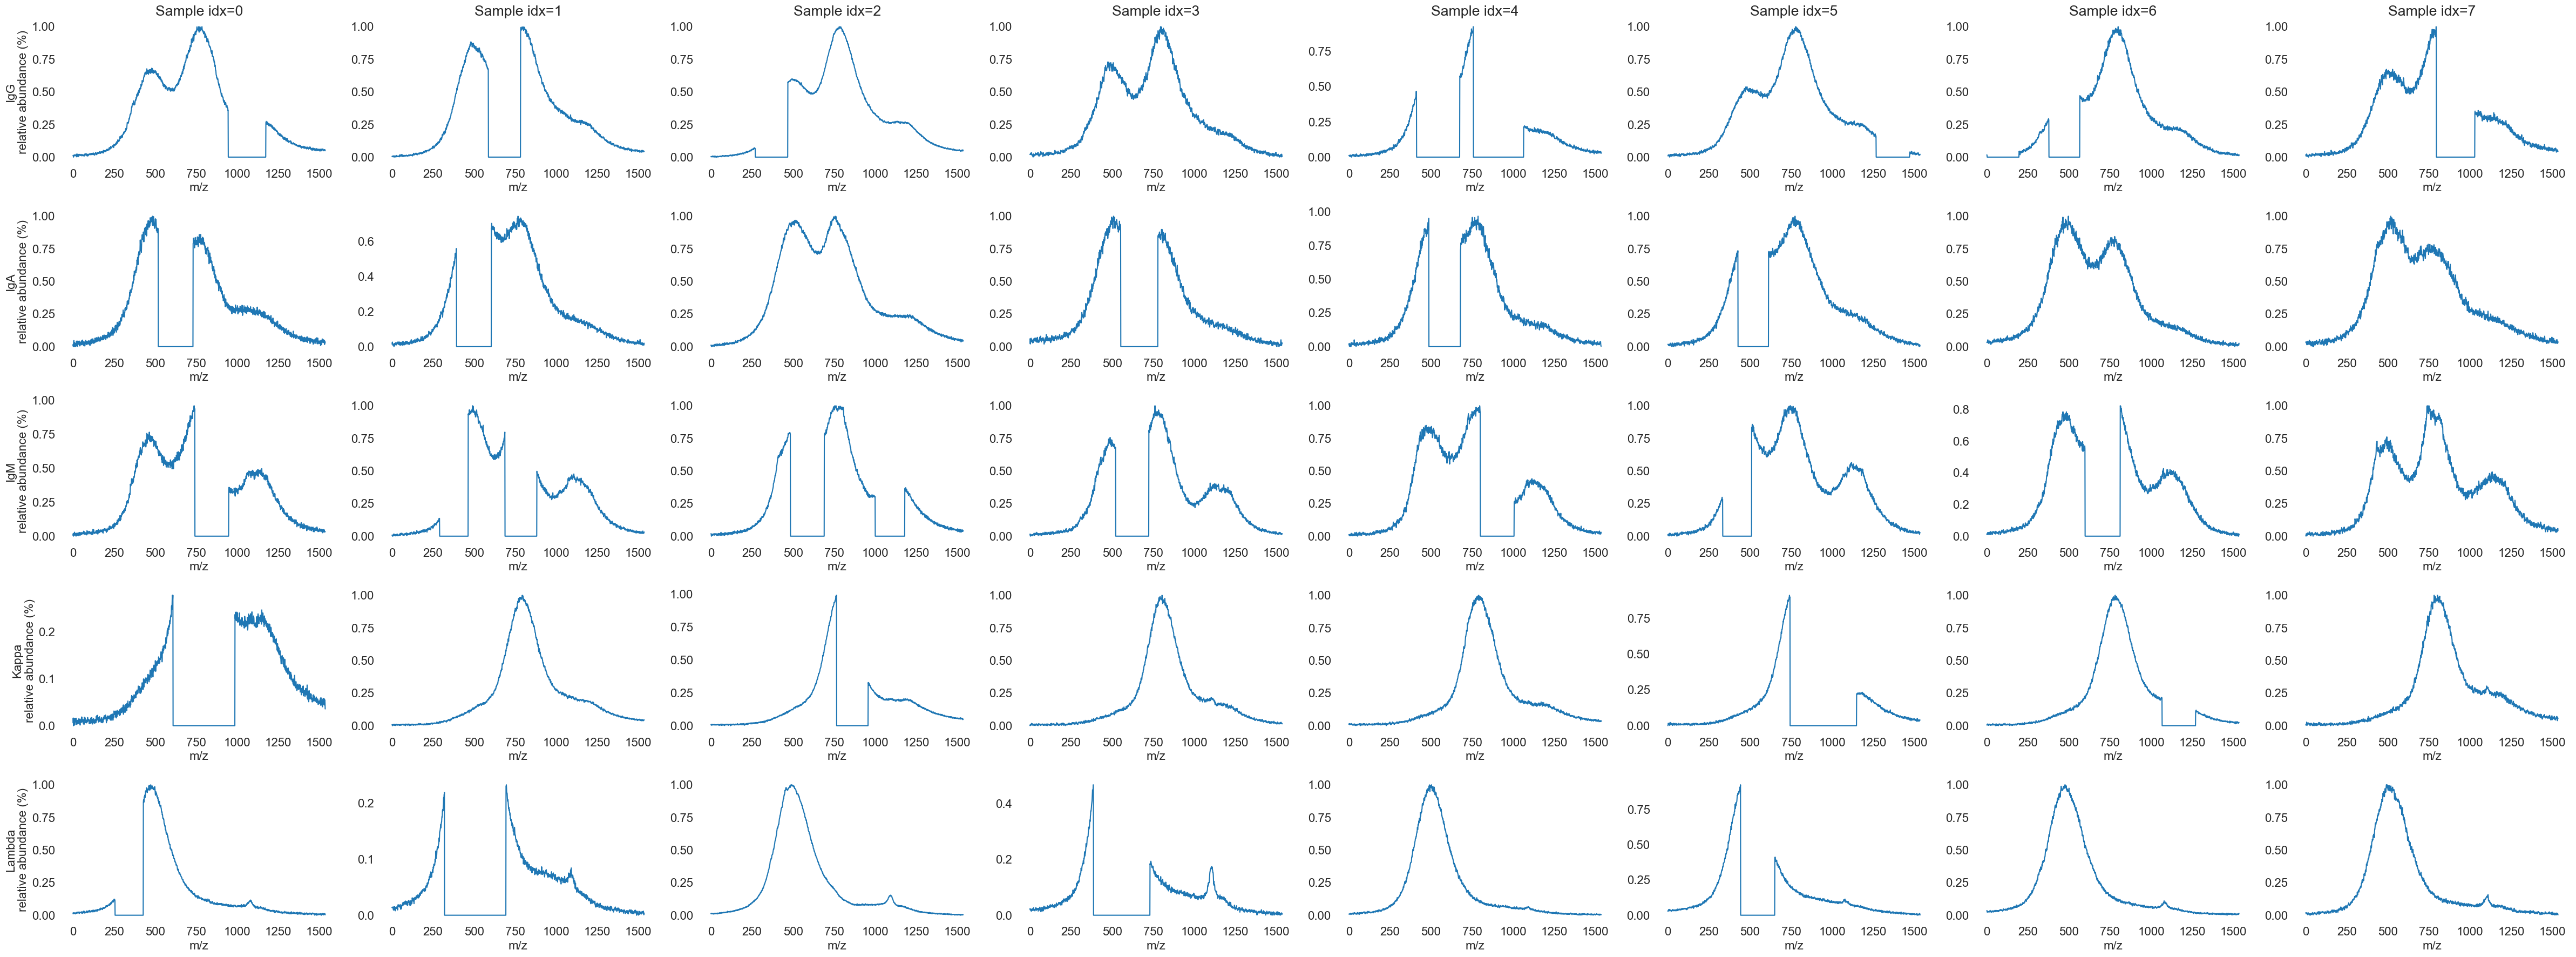

In [15]:
n_images = 8  # we want to show a limited number of samples on the plot
x, y = next(iter(train_loader))
x = x.cpu().detach().numpy()
y = y.cpu().detach().numpy()
plt.figure(figsize=(6 * n_images, 18))
gs = gridspec.GridSpec(5, n_images)
for idx in range(n_images):
    for i in range(5):
        plt.subplot(gs[i, idx])
        plt.plot(x[idx, i, 0, :])
        if idx == 0:
            plt.ylabel(f'{["IgG", "IgA", "IgM", "Kappa", "Lambda"][i]}\nrelative abundance (%)')
        if i == 0:
            plt.title(f"Sample {idx=}")
        plt.xlabel("m/z")
plt.tight_layout()
plt.show()

## Deep learning pipeline

In [15]:
class RMSELoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, yhat, y):
        loss = torch.sqrt(self.mse(yhat, y) + self.eps)
        return loss
    

def _get_homemade_encoder_v1_base_modules(input_dim, input_channels, encoder_blocks_layout, maxpool, kernel_size, stride, dropout,
                                          first_layer_groups, groups, batchnorm, hidden_activation, flatten):

    assert (maxpool == 1 and stride > 1) or (maxpool > 1 and stride == 1), f"Exactly one of {maxpool=} and {stride=} must be > 1"
    n_pools = len(encoder_blocks_layout) - 1 if maxpool > 1 else len(encoder_blocks_layout)

    _encoder_modules = []

    previous_channels = input_channels

    for block_position, block_layers in enumerate(encoder_blocks_layout):
        if block_position > 0:
            if maxpool > 1:
                _encoder_modules.append(nn.MaxPool2d(kernel_size=(1, maxpool), stride=(1, maxpool)))
        for layer_position, layer_channels in enumerate(block_layers):
            current_stride = stride if layer_position == 0 else 1
            padding = 0
            if current_stride > 1:
                hin = input_dim // (max(maxpool, stride) ** (layer_position))
                padding = (kernel_size - hin + stride * (hin / stride - 1)) / 2
                assert (padding % 1) == 0, f"Current {stride}, {hin=} and {kernel_size=} end with decimal {padding=}"
                padding = int(padding)

            _encoder_modules.append(nn.Conv2d(in_channels=previous_channels, out_channels=layer_channels, kernel_size=(1, kernel_size),
                                              stride=(1, current_stride),
                                              groups=first_layer_groups if ((layer_position == 0) and (block_position == 0)) else groups,
                                              padding=(0, padding) if current_stride > 1 else "same"))
            if (dropout is not None) and (dropout > 0):
                _encoder_modules.append(nn.Dropout(p=dropout))
            previous_channels = layer_channels
            if batchnorm:
                _encoder_modules.append(nn.BatchNorm2d(layer_channels))
            if hidden_activation == "relu":
                _encoder_modules.append(nn.ReLU())
            elif hidden_activation == "leaky_relu":
                _encoder_modules.append(nn.LeakyReLU())
            elif hidden_activation == "elu":
                _encoder_modules.append(nn.ELU())
            elif hidden_activation == "selu":
                _encoder_modules.append(nn.SELU())
            else:
                assert False, f"Unknown {hidden_activation=}"

    encoder_lastconv_dim = input_dim // (max(stride, maxpool) ** n_pools)
    encoder_lastconv_channels = encoder_blocks_layout[-1][-1]

    if flatten == "avg":
        global_pooling_kernel = encoder_lastconv_dim
        encoder_output_dim = encoder_lastconv_channels
        _encoder_modules.append(nn.AvgPool2d(kernel_size=(1, global_pooling_kernel)))
        _encoder_modules.append(nn.Flatten())
    elif flatten == "max":
        global_pooling_kernel = encoder_lastconv_dim
        encoder_output_dim = encoder_lastconv_channels
        _encoder_modules.append(nn.MaxPool2d(kernel_size=(1, global_pooling_kernel)))
        _encoder_modules.append(nn.Flatten())
    elif flatten == "flatten":
        encoder_output_dim = encoder_lastconv_channels * encoder_lastconv_dim
        _encoder_modules.append(nn.Flatten())
    else:
        assert False, f"Unknown {flatten=}"

    return _encoder_modules, encoder_output_dim  # , encoder_lastconv_channels, encoder_lastconv_dim


def _get_dense_encoder(input_dim, input_channels, encoder_blocks_layout, dropout, batchnorm, hidden_activation):

    _encoder_modules = []

    previous_size = input_dim * input_channels

    _encoder_modules.append(nn.Flatten())

    for layer_position, layer_size in enumerate(encoder_blocks_layout):

        _encoder_modules.append(nn.Linear(previous_size, layer_size))

        if (dropout is not None) and (dropout > 0):
            _encoder_modules.append(nn.Dropout(p=dropout))
        previous_size = layer_size
        if batchnorm:
            _encoder_modules.append(nn.BatchNorm1d(layer_size))
        if hidden_activation == "relu":
            _encoder_modules.append(nn.ReLU())
        elif hidden_activation == "leaky_relu":
            _encoder_modules.append(nn.LeakyReLU())
        elif hidden_activation == "elu":
            _encoder_modules.append(nn.ELU())
        elif hidden_activation == "selu":
            _encoder_modules.append(nn.SELU())
        else:
            assert False, f"Unknown {hidden_activation=}"

    return _encoder_modules, previous_size



class SupervisedModule(pl.LightningModule):
    def __init__(self, n_classes, mode,
                 input_dim, input_channels, latent_dim, kernel_size, flatten, stride, dropout, groups, first_layer_groups, maxpool,
                 encoder_blocks_layout, backbone, batchnorm, hidden_activation,
                 optimizer,
                 lr, lr_scheduler, lr_reduceonplateau_factor, lr_reduceonplateau_patience, lr_reduceonplateau_threshold, lr_reduceonplateau_minlr,
                 lr_multistep_milestones,
                 lr_multistep_gamma,
                 ):
        super().__init__()
        self.save_hyperparameters()

        self.n_classes = n_classes
        self.mode = mode
        self.backbone = backbone

        if (self.backbone == "conv") or (self.backbone == "homemade"):  # conv model was the first model designed, hence homemade
            encoder_modules, enc_out_dim = _get_homemade_encoder_v1_base_modules(input_dim=input_dim, input_channels=input_channels, maxpool=maxpool,
                                                                                 encoder_blocks_layout=encoder_blocks_layout, kernel_size=kernel_size,
                                                                                 stride=stride, dropout=dropout,
                                                                                 first_layer_groups=first_layer_groups, groups=groups,
                                                                                 batchnorm=batchnorm, hidden_activation=hidden_activation, flatten=flatten)
            self.encoder = nn.Sequential(*encoder_modules)
            self.fc = nn.Linear(enc_out_dim, latent_dim)
            self.pred = nn.Linear(latent_dim, self.n_classes)

        elif self.backbone == "dense":
            encoder_modules, enc_out_dim = _get_dense_encoder(input_dim=input_dim, input_channels=input_channels, encoder_blocks_layout=encoder_blocks_layout,
                                                              dropout=dropout, batchnorm=batchnorm, hidden_activation=hidden_activation)
            self.encoder = nn.Sequential(*encoder_modules)
            # self.fc = nn.Linear(enc_out_dim, latent_dim)
            # self.pred = nn.Linear(latent_dim, self.n_classes)
            self.pred = nn.Linear(enc_out_dim, self.n_classes)
        else:
            assert False, f"Unknown {backbone=}"

        self.softmax = nn.Softmax(dim=1)

        if self.mode == "quant":
            self.loss = RMSELoss()
        if self.mode == "qual":
            self.loss = nn.CrossEntropyLoss()

        self.y_true = []
        self.y_pred = []

    def configure_optimizers(self):
        if self.hparams.optimizer == "Adam":
            optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        elif self.hparams.optimizer == "AdamW":
            optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr)
        elif self.hparams.optimizer == "RMSProp":
            optimizer = torch.optim.RMSprop(self.parameters(), lr=self.hparams.lr)
        else:
            assert False, f"Unknown {self.hparams.optimizer=}"
        if self.hparams.lr_scheduler == "reduceonplateau":
            print(
                f"Setting optimizer to reduceonplateau with params {self.hparams.lr_reduceonplateau_factor=}, {self.hparams.lr_reduceonplateau_patience=}, {self.hparams.lr_reduceonplateau_threshold=}, {self.hparams.lr_reduceonplateau_minlr=}")
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=self.hparams.lr_reduceonplateau_factor,
                                                                   patience=self.hparams.lr_reduceonplateau_patience,
                                                                   threshold=self.hparams.lr_reduceonplateau_threshold,
                                                                   min_lr=self.hparams.lr_reduceonplateau_minlr, verbose=True)
            return {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "val_loss"}
        elif self.hparams.lr_scheduler == "multistep":
            print(f"Setting optimizer to multistep with params {self.hparams.lr_multistep_milestones=}, {self.hparams.lr_multistep_gamma=}")
            scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=self.hparams.lr_multistep_milestones, gamma=self.hparams.lr_multistep_gamma,
                                                             verbose=True)
            return {"optimizer": optimizer, "lr_scheduler": scheduler}
        elif self.hparams.lr_scheduler != "none":
            assert False, f"Unknown {self.hparams.lr_scheduler=}"
        return optimizer

    def forward(self, batch):
        if type(batch) in (tuple, list):
            x, y = batch
        else:
            x = batch
        if self.backbone in ("resnet1d", "net1d"):
            x = x.view(x.size(0), x.size(1), x.size(3))
            x = self.encoder(x)
        elif self.backbone == "homemade":
            x = self.pred(self.fc(self.encoder(x)))
        elif self.backbone == "dense":
            x = self.pred(self.encoder(x))
        elif self.backbone in ("vit_1d", "simple_vit_1d", "smalldataset_vit_1d"):
            x = torch.squeeze(x)  # drop H in H x W
            x = self.encoder(x)
        if self.mode == "qual":
            x = self.softmax(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch

        # encode x to get the mu and variance parameters
        yhat = None
        if self.backbone in ("resnet1d", "net1d"):
            x = x.view(x.size(0), x.size(1), x.size(3))
            yhat = self.encoder(x)
        elif self.backbone == "homemade":
            yhat = self.pred(self.fc(self.encoder(x)))
        elif self.backbone == "dense":
            yhat = self.pred(self.encoder(x))
        elif self.backbone in ("vit_1d", "simple_vit_1d", "smalldataset_vit_1d"):
            x = torch.squeeze(x)  # drop H in H x W
            yhat = self.encoder(x)

        loss = self.loss(yhat, y)

        self.log_dict({
            'loss': loss,
        })

        return loss

Now we can load the deep learning model and pytorch/lightning objects needed to run the DL pipeline

In [16]:
trainer_args = {'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
                'devices': 'auto',
                'num_nodes': 1,
                'strategy': 'auto'}

pl.seed_everything(44)  # To be reproducible
model = SupervisedModule.load_from_checkpoint(checkpoint_path)

print(model)

trainer = pl.Trainer(
    # default_root_dir=os.path.split(checkpoint_path)[0],
    **trainer_args,
    callbacks=None,
    logger=None,
)

Seed set to 44
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


SupervisedModule(
  (encoder): Sequential(
    (0): Conv2d(5, 65, kernel_size=(1, 5), stride=(1, 1), padding=same, groups=5)
    (1): BatchNorm2d(65, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SELU()
    (3): Conv2d(65, 65, kernel_size=(1, 5), stride=(1, 1), padding=same, groups=5)
    (4): BatchNorm2d(65, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SELU()
    (6): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(65, 130, kernel_size=(1, 5), stride=(1, 1), padding=same, groups=5)
    (8): BatchNorm2d(130, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): SELU()
    (10): Conv2d(130, 130, kernel_size=(1, 5), stride=(1, 1), padding=same, groups=5)
    (11): BatchNorm2d(130, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): SELU()
    (13): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
    (14):

C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Then we can define the parameters that we will use to define what predictions we will realized and how we will analyze them
Here, we want to predict BiAge, so we will focus on comparing with Age (chronological age)
Let's define some parameters that will guide plot production later
This will allow reusing similar functions for race and sex prediction, with minor changes only

In [17]:
# parameters specific for age_v2 validation
UNSTANDARDIZE_PREDICTIONS = True

# trues_ticks = [40, 50, 60, 70, 80]
# trues_ticks_full_length = [20, 30, 40, 50, 60, 70, 80, 90]
# peak_method_ticks = [-1., 0, 1.]

Then, we will define a `supervised_inference` function which will help with automatically obtaining predictions from the model and converting those predictions into usable data for validation
Particularly, this function will be responsible of outputing raw predictions and predictions after masking peaks (peak dropout)
Furthermore, this function will be responsible of unstandardizing the target (y) variable, since age was standardized before training the model

In [18]:
def supervised_inference(sample_match_ids: list, sample_annotations: np.array,
                         negative_dropout_preprocess_data, output_column_loc: int,
                         unstandardize: bool, return_datasets_instead: bool = False, multi_preprocessing: bool = True):
    assert type(sample_match_ids) is list, f"{type(sample_match_ids)=}, must be a list"

    all_preds = []
    all_datasets = []

    if multi_preprocessing:
        if negative_dropout_preprocess_data is not None:
            preprocessings = [None, negative_dropout_preprocess_data]
        else:
            preprocessings = [None, "dropout"]
    else:
        preprocessings = [None, ]

    for preprocessing in preprocessings:
        the_dataset = MSSpectraDataset(dataset_path=ms_data_path,
                                       sample_match_ids=sample_match_ids,
                                       sample_annotations=sample_annotations,
                                       peak_removal_method=preprocessing,
                                       input_dim=input_dim)

        if return_datasets_instead:
            all_datasets.append(the_dataset)
            continue

        the_loader = data.DataLoader(
            the_dataset,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            pin_memory=True,
            num_workers=0,
            persistent_workers=False
        )

        the_outputs = trainer.predict(model, dataloaders=the_loader)
        the_preds = torch.cat(the_outputs).detach().cpu().numpy()
        if unstandardize:
            the_preds = (the_preds * training_age_std) + training_age_mean
        if output_column_loc is not None:
            the_preds = the_preds[:, output_column_loc]

        # save
        all_preds.append(the_preds)

    if return_datasets_instead:
        return all_datasets

    return all_preds

Specifically, the `find_paired_dropout_data` function will help with selecting paired samples so we can apply peak dropout on negative samples (i.e. which do not have any peaks) by resampling the peak locations/sizes from positive samples from similar patients (e.g. similar age)

In [19]:
def find_paired_dropout_data(target_match_ids, positive_match_ids_to_pair, take_original_for_non_negatives_targets: bool, full_dataset=dataset_all):
    # 1) get the ages of the patients
    find_age_df_negatives = pd.DataFrame({"MS_ID": target_match_ids}).merge(
        full_dataset[["MS_ID", "AGE", "MG_DIAGNOSIS"]], how="left")
    assert len(find_age_df_negatives) == len(target_match_ids)
    find_age_df_positives = pd.DataFrame({"MS_ID": positive_match_ids_to_pair}).merge(
        full_dataset[["MS_ID", "AGE", "MG_DIAGNOSIS"]], how="left")
    assert len(find_age_df_positives) == len(positive_match_ids_to_pair)
    # remove LC-MGUS (no peaks)
    find_age_df_positives = find_age_df_positives[find_age_df_positives.MG_DIAGNOSIS != "LC-MGUS"]
    # now randomly pair each negative with a positive with same age
    # to do this, we can just merge both by rounded age
    find_age_df_negatives = find_age_df_negatives.rename(
        columns={"MS_ID": "Negative_MS_ID", "MG_DIAGNOSIS": "Negative_MG_DIAGNOSIS"})
    find_age_df_positives = find_age_df_positives.rename(
        columns={"MS_ID": "Positive_MS_ID", "MG_DIAGNOSIS": "Positive_MG_DIAGNOSIS"})
    find_age_df_negatives["Rounded_Age"] = find_age_df_negatives.AGE.round(0)
    find_age_df_positives["Rounded_Age"] = find_age_df_positives.AGE.round(0)
    all_possible_negpos_pairs = find_age_df_negatives.merge(find_age_df_positives, on="Rounded_Age", how="left")
    # now we can just shuffle our dataset randomly, and then remove duplicated Negative_MS_ID to keep only 1 match per patient
    random_order = np.random.RandomState(seed=1).choice(np.arange(len(all_possible_negpos_pairs)), size=len(all_possible_negpos_pairs),
                                                        replace=False)
    all_possible_negpos_pairs = all_possible_negpos_pairs.iloc[random_order]
    paired_negative_samples = all_possible_negpos_pairs[~all_possible_negpos_pairs.Negative_MS_ID.duplicated()]
    # finally re-order by merging with our initial negative samples list
    final_pair_df = find_age_df_negatives[["Negative_MS_ID", "Negative_MG_DIAGNOSIS"]].merge(
        paired_negative_samples[["Negative_MS_ID", "Positive_MS_ID", "Positive_MG_DIAGNOSIS"]],
        on="Negative_MS_ID", how="left")
    # now we just have to load the data that will be used for dropping out parts
    peaks_info_df = pd.DataFrame(pd.read_hdf(os.path.join(ms_data_path, "peaks_positions.h5")))
    paired_peaks_info = []
    # note: we are not using the type of pos diagnosis to decide which sample to pair
    # because since we are using ALL positives
    # we can say that the dropout will be make according to how frequent some peaks are seen in the whole population
    for idx in tqdm(range(len(final_pair_df))):
        if take_original_for_non_negatives_targets and (final_pair_df.iloc[idx]["Negative_MG_DIAGNOSIS"] != "Negative"):
            # we want to take the original peaks_info for non-negative samples
            # and this sample is not a negative
            # so we'll take its info instead of a matched positive
            selected_match_id = final_pair_df.iloc[idx].Negative_MS_ID
        else:
            # this sample is a negative so has no peaks info (except potentially <LLMI/C1q)
            # or we set take_original_for_non_negatives to False to force taking the paired positive sample's peak info
            # any case, we'll "overwrite" this sample's peak info by the paired positive's
            selected_match_id = final_pair_df.iloc[idx].Positive_MS_ID
        match_peaks_info = peaks_info_df[peaks_info_df["MS_ID"] == selected_match_id]
        match_peaks_info = [match_peaks_info.iloc[k].to_dict() for k in range(len(match_peaks_info))]
        paired_peaks_info.append(match_peaks_info)
    # now we can call our dataset
    (np.array([len(p) for p in paired_peaks_info]) > 0).sum()  # 876
    (np.array([len(p) for p in
               paired_peaks_info]) == 0).sum()  # 13  # sometimes there may be "0" peaks... it's rare and when the peak is 0.015 g/L, but flagged as LLMI (really in between)
    # return
    return paired_peaks_info


Then, we can create our different datasets (training set, validation set for negative samples, validation set for samples with monoclonal gammopathy) and compute model predictions

In [20]:
np_train_negative_preds, = supervised_inference(sample_match_ids=dataset_train_negative.MS_ID.tolist(),
                                                sample_annotations=dataset_train_negative.AGE.values,
                                                output_column_loc=-1,
                                                negative_dropout_preprocess_data=None,  # no need to dropout: comparing only negatives
                                                unstandardize=UNSTANDARDIZE_PREDICTIONS,
                                                multi_preprocessing=False)

You are using a CUDA device ('NVIDIA RTX A5500 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 250/250 [00:23<00:00, 10.57it/s]


In [21]:
# for negatives, we also want to use dropout to compare results consistently with positives
# but they do not have peaks (by definition...)
# so instead we will pair each negative sample with one positive sample from the positive set
# (pairing will be made by age)
# and then we will mask them how we masked the positive samples

np_test_negative_preds, np_test_negative_preds_dropout = supervised_inference(sample_match_ids=dataset_test_negative.MS_ID.tolist(),
                                                                              sample_annotations=dataset_test_negative.AGE.values,
                                                                              output_column_loc=-1,
                                                                              negative_dropout_preprocess_data=find_paired_dropout_data(
                                                                                  target_match_ids=dataset_test_negative.MS_ID.tolist(),
                                                                                  positive_match_ids_to_pair=dataset_test_mg.MS_ID.tolist(),
                                                                                  take_original_for_non_negatives_targets=False),
                                                                              unstandardize=UNSTANDARDIZE_PREDICTIONS)

100%|██████████| 889/889 [00:01<00:00, 884.84it/s]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 28/28 [00:02<00:00, 13.62it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Predicting DataLoader 0: 100%|██████████| 28/28 [00:01<00:00, 27.05it/s]


In [22]:
# same for positives => without and with dropout

np_test_mg_preds, np_test_mg_preds_dropout = supervised_inference(sample_match_ids=dataset_test_mg.MS_ID.tolist(),
                                                                  sample_annotations=dataset_test_mg.AGE.values,
                                                                  output_column_loc=-1,
                                                                  negative_dropout_preprocess_data=None,
                                                                  unstandardize=UNSTANDARDIZE_PREDICTIONS)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 245/245 [00:12<00:00, 18.99it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Predicting DataLoader 0: 100%|██████████| 245/245 [00:17<00:00, 13.91it/s]


In [23]:
# concat to original datasets

# train negative
dataset_train_negative["BIAGE"] = np_train_negative_preds

# test negative
dataset_test_negative["BIAGE"] = np_test_negative_preds
dataset_test_negative["BIAGE_DROPOUT"] = np_test_negative_preds_dropout

# test mg
dataset_test_mg["BIAGE"] = np_test_mg_preds
dataset_test_mg["BIAGE_DROPOUT"] = np_test_mg_preds_dropout

In [21]:
# PLOT DROPOUT EXAMPLES => FIGURE S11, FIGURE S1

# do small figures of how we dropout negative samples (once is enough for all models)
demo_paired_peaks_info = find_paired_dropout_data(target_match_ids=dataset_test_negative.MS_ID.tolist(),
                                                  positive_match_ids_to_pair=dataset_test_mg.MS_ID.tolist(),
                                                  take_original_for_non_negatives_targets=False)

100%|██████████| 889/889 [00:01<00:00, 784.82it/s]


In [22]:
DEMODF_nodropout_test_negative_dataset, DEMODF_dropout_test_negative_dataset = supervised_inference(
    sample_match_ids=dataset_test_negative.MS_ID.tolist(),
    sample_annotations=dataset_test_negative.AGE.values,
    output_column_loc=-1,
    negative_dropout_preprocess_data=demo_paired_peaks_info,
    unstandardize=UNSTANDARDIZE_PREDICTIONS,
    return_datasets_instead=True)

DEMODF_nodropout_test_mg_dataset, DEMODF_dropout_test_mg_dataset = supervised_inference(
    sample_match_ids=dataset_test_mg.MS_ID.tolist(),
    sample_annotations=dataset_test_mg.AGE.values,
    output_column_loc=-1,
    negative_dropout_preprocess_data=None,
    unstandardize=UNSTANDARDIZE_PREDICTIONS,
    return_datasets_instead=True)

To illustrate what an original set of spectra (for 1 sample of 1 patient) looks like, without or with peaks masking, we can plot the figure below

This is **Figure 2B** and **Figure 2C** in the manuscript

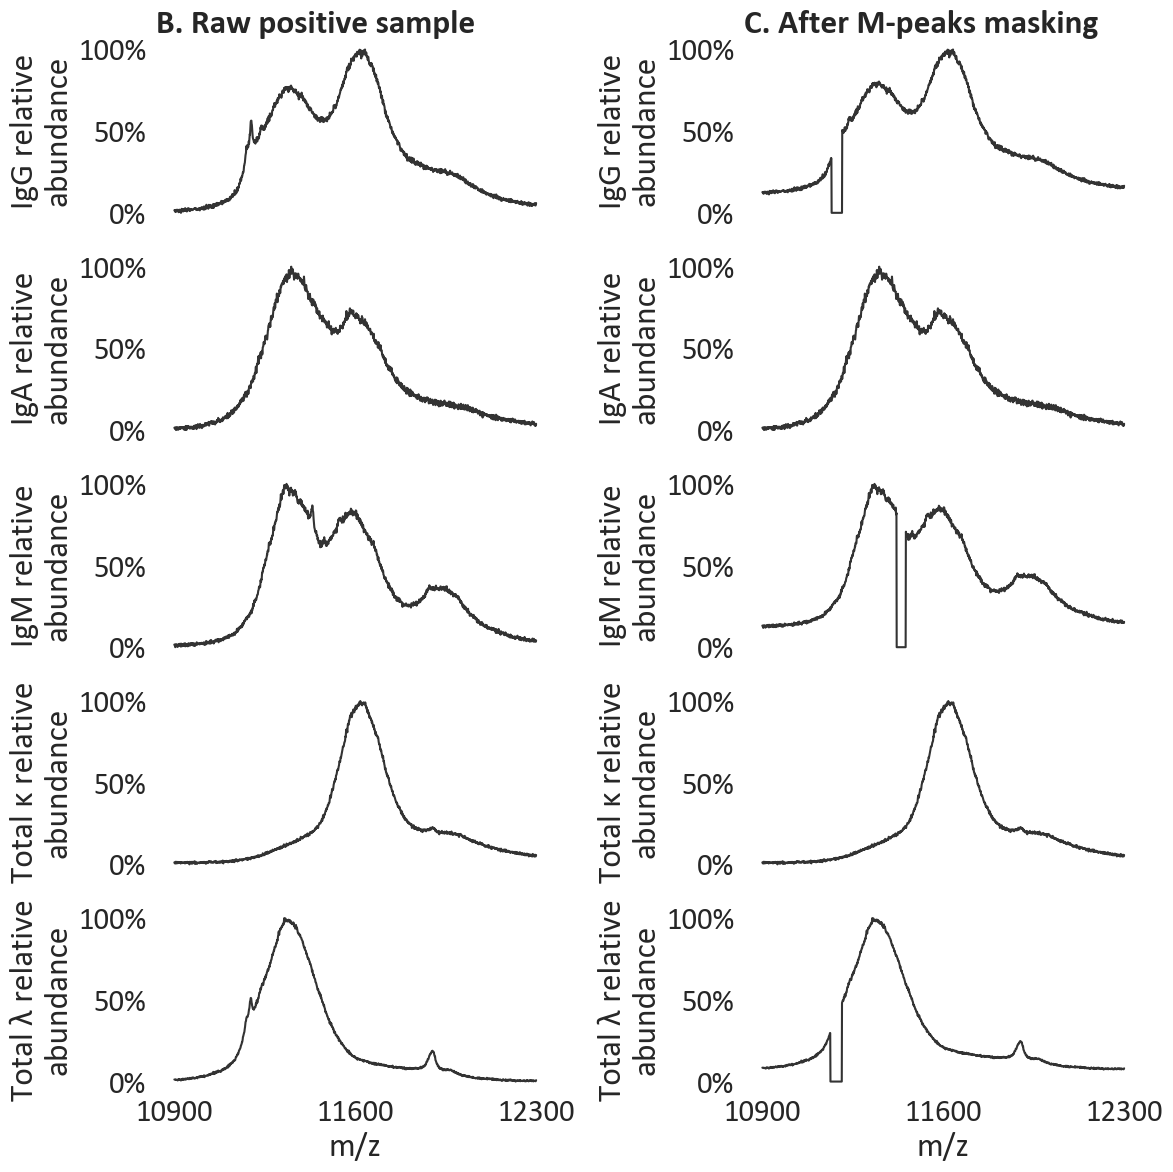

In [24]:
# FIGURE 2 B, C

dropout_examples = [0, ]
for idx in dropout_examples:
    original_x, _ = DEMODF_nodropout_test_negative_dataset.__getitem__(idx)
    dropout_x, _ = DEMODF_dropout_test_negative_dataset.__getitem__(idx)
    paired_pos_matchid = demo_paired_peaks_info[idx][0]["MS_ID"]
    pos_idx = [k for k, v in enumerate(dataset_test_mg.MS_ID.tolist()) if v == paired_pos_matchid][0]
    original_posx, _ = DEMODF_nodropout_test_mg_dataset.__getitem__(pos_idx)
    dropout_posx, _ = DEMODF_dropout_test_mg_dataset.__getitem__(pos_idx)

    gamkl_label = [*["Ig" + ist for ist in "GAM"], *["Total " + ist for ist in "κλ"]]

    # visualize how it looks like
    plt.figure(figsize=(pp_size * 2, pp_size * 2))
    gs: np.array = gridspec.GridSpec(5, 2)
    for i in range(5):
        plot_title_lst = ["B. Raw positive sample",
                          "C. After M-peaks masking",
                          ]
        y_values_lst = [original_posx, dropout_posx]
        for j, (y_values, plot_title) in enumerate(zip(y_values_lst, plot_title_lst)):
            plt.subplot(gs[i, j])
            ax = sns.lineplot(x=np.arange(y_values.shape[-1]), y=y_values[i, 0, :], hue=[gamkl_label[i], ] * original_x.shape[-1],
                              palette={c: "#333333" for c in gamkl_label}, legend=False)
            if j < 2:
                # ax.legend(prop=legend_font_params, loc="upper right")
                plt.yticks([0, .5, 1.])
                ax.set_yticklabels([f"{v * 100:.0f}%" for v in ax.get_yticks()], fontdict=ticks_font_params)
                plt.ylabel(gamkl_label[i] + " relative\nabundance", **labels_font_params)
            else:
                plt.yticks([0, .5, 1.])
                ax.set_yticklabels(["" for v in ax.get_yticks()], fontdict=ticks_font_params)
                plt.ylabel(None)
                # ax.legend().remove()
            if i == 0:
                plt.title(plot_title, loc='left', font=paneltitle_font_params)
            if i == 4:
                plt.xticks([0, 768, 1536])
                ax.set_xticklabels([{0: "10900", 768: "11600", 1536: "12300"}[v] for v in ax.get_xticks()], fontdict=ticks_font_params)
                plt.xlabel("m/z", **labels_font_params)
            else:
                plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    plt.tight_layout()
    plt.show()

We can also do a similar figure with more details, and especially showcase how we can, from a negative sample (A), sample a similar positive sample (B), and use the peaks position/size on this positive sample to mask the peaks from this positive sample's spectra (C), and also mask the same areas in the negative sample (D)

This is **Supplementary Figure S11** in the manuscript

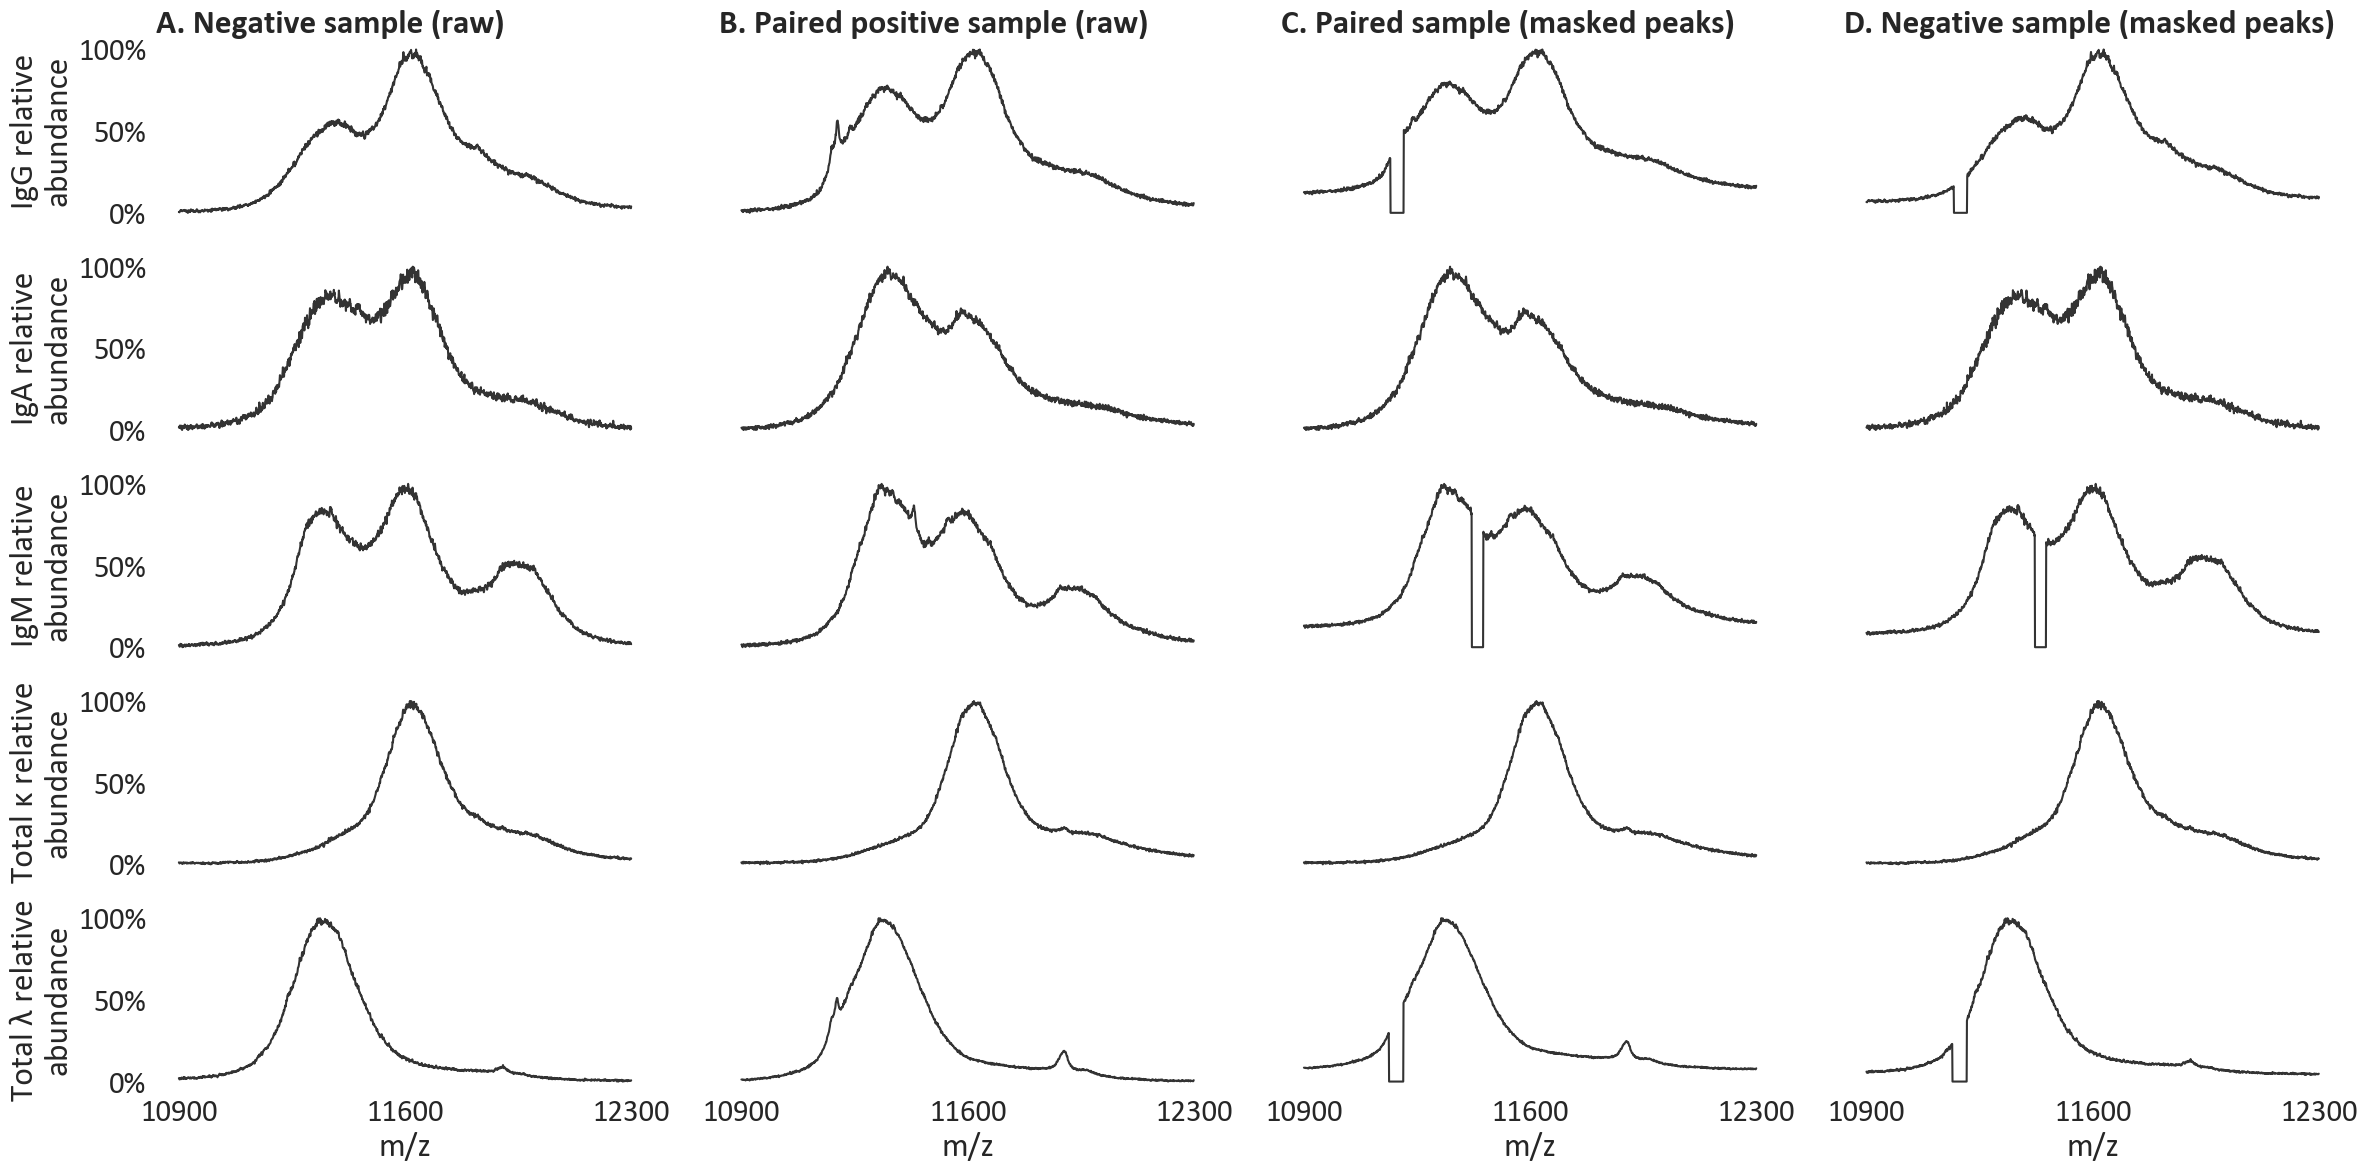

In [26]:
# WITH MORE DETAILS, SUPPLEMENTARY FIGURE S11

dropout_examples = [0, ]
for idx in dropout_examples:
    original_x, _ = DEMODF_nodropout_test_negative_dataset.__getitem__(idx)
    dropout_x, _ = DEMODF_dropout_test_negative_dataset.__getitem__(idx)
    paired_pos_matchid = demo_paired_peaks_info[idx][0]["MS_ID"]
    pos_idx = [k for k, v in enumerate(dataset_test_mg.MS_ID.tolist()) if v == paired_pos_matchid][0]
    original_posx, _ = DEMODF_nodropout_test_mg_dataset.__getitem__(pos_idx)
    dropout_posx, _ = DEMODF_dropout_test_mg_dataset.__getitem__(pos_idx)

    gamkl_label = [*["Ig" + ist for ist in "GAM"], *["Total " + ist for ist in "κλ"]]

    # visualize how it looks like
    plt.figure(figsize=(pp_size * 4, pp_size * 2))
    gs: np.array = gridspec.GridSpec(5, 4)
    for i in range(5):
        plot_title_lst = ["A. Negative sample (raw)",
                          "B. Paired positive sample (raw)",
                          "C. Paired sample (masked peaks)",
                          "D. Negative sample (masked peaks)"]
        y_values_lst = [original_x, original_posx, dropout_posx, dropout_x]
        for j, (y_values, plot_title) in enumerate(zip(y_values_lst, plot_title_lst)):
            plt.subplot(gs[i, j])
            ax = sns.lineplot(x=np.arange(y_values.shape[-1]), y=y_values[i, 0, :], hue=[gamkl_label[i], ] * original_x.shape[-1],
                              palette={c: "#333333" for c in gamkl_label}, legend=False)
            if j == 0:
                # ax.legend(prop=legend_font_params, loc="upper right")
                plt.yticks([0, .5, 1.])
                ax.set_yticklabels([f"{v * 100:.0f}%" for v in ax.get_yticks()], fontdict=ticks_font_params)
                plt.ylabel(gamkl_label[i] + " relative\nabundance", **labels_font_params)
            else:
                plt.yticks([0, .5, 1.])
                ax.set_yticklabels(["" for v in ax.get_yticks()], fontdict=ticks_font_params)
                plt.ylabel(None)
                # ax.legend().remove()
            if i == 0:
                plt.title(plot_title, loc='left', font=paneltitle_font_params)
            if i == 4:
                plt.xticks([0, 768, 1536])
                ax.set_xticklabels([{0: "10900", 768: "11600", 1536: "12300"}[v] for v in ax.get_xticks()], fontdict=ticks_font_params)
                plt.xlabel("m/z", **labels_font_params)
            else:
                plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    plt.tight_layout()
    plt.show()

## Basic validation

Here we will focus on comparing the predicted BiAge to the chronological age of patients, in the various datasets (training, validations)

First, we can start with a basic plot of the training set and the validation set (negative samples only)

C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\_lib\_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


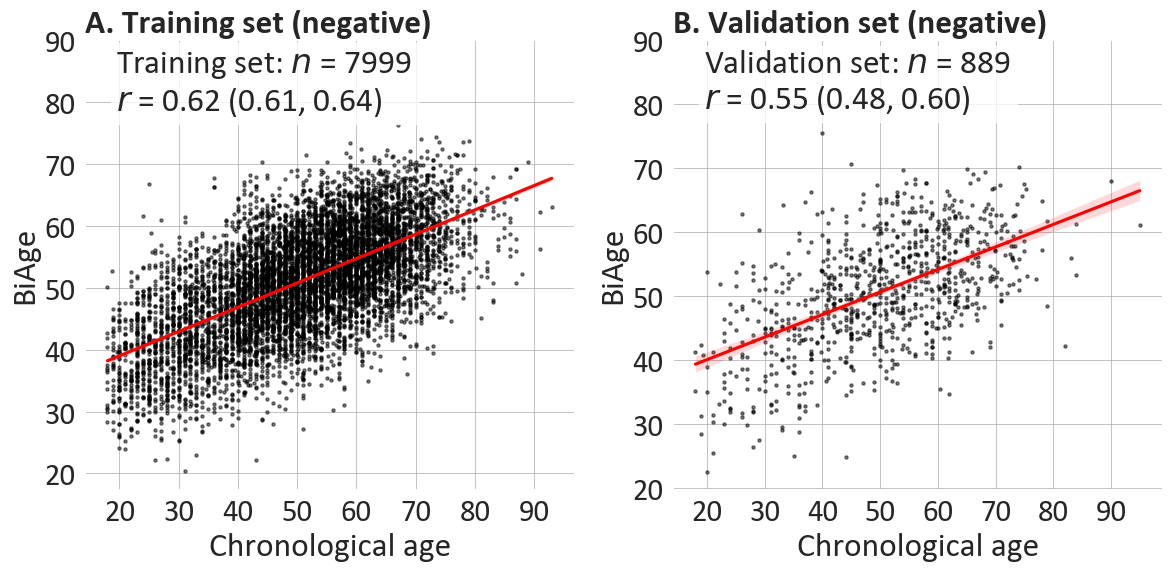

In [33]:
# plot correlation between gt and preds, on training and val sets
# compare predictions of BiAge for training set and validation set
plot_data = [[dataset_train_negative.AGE.values, dataset_train_negative.BIAGE.values, "A. Training set (negative)", "Training set"],
             [dataset_test_negative.AGE.values, dataset_test_negative.BIAGE.values, "B. Validation set (negative)", "Validation set"]]

plt.figure(figsize=(2 * pp_size, pp_size))
for i, (trues, preds, suptitle, group_name) in enumerate(plot_data):
    plt.subplot(1, 2, i + 1)
    plot_lm(x=trues, y=preds, group_name=group_name,
            xlabel="Chronological age", ylabel="BiAge",
            xticks=[20, 30, 40, 50, 60, 70, 80, 90],
            yticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
            suptitle=suptitle,
            text_bbox_alpha=.8,
            scatter_kws_custom_alpha=.5,
            scatter_plot_custom_size=5,
            common_scale=False,
            confidence_level=.99)
plt.tight_layout()
plt.show()

Same, if we include a third figure with the patients from the validation set with monoclonal gammopathy

C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\_lib\_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\_lib\_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


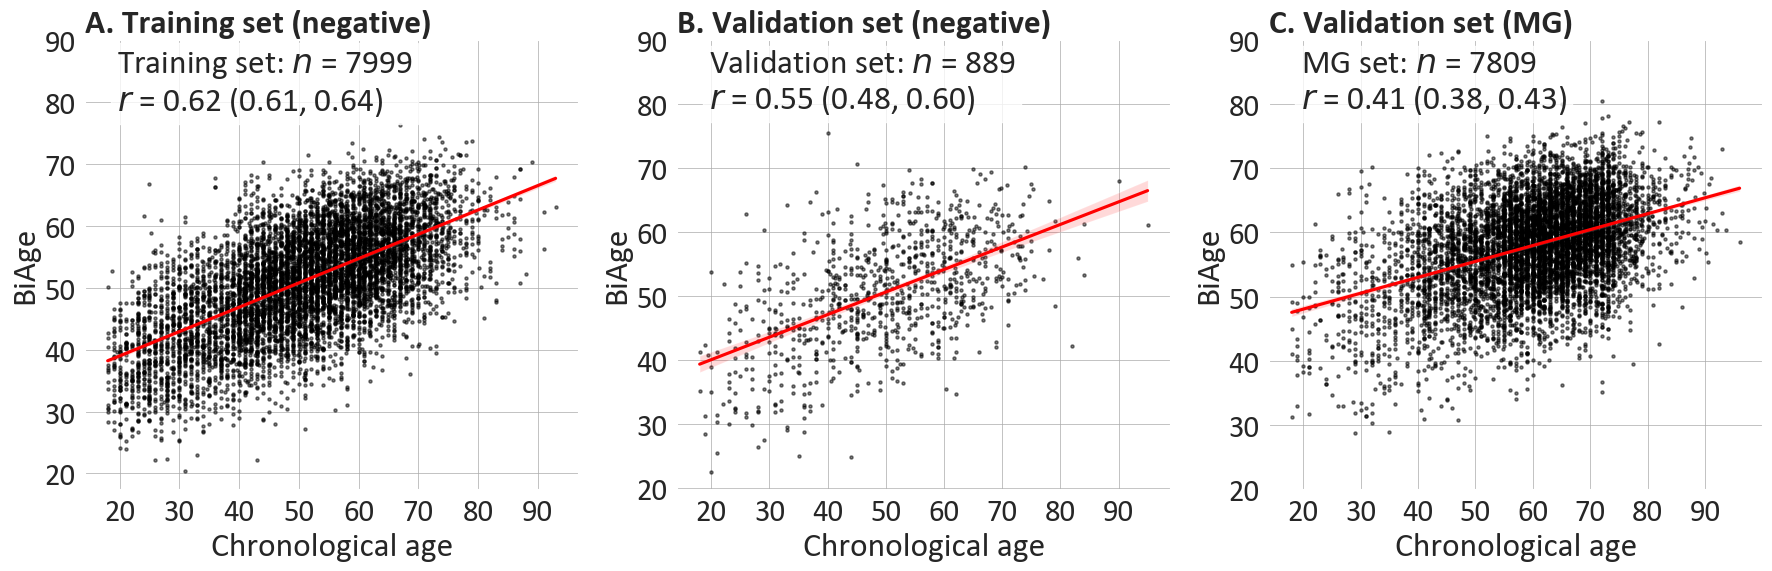

In [35]:
# compare predictions of BiAge for training set, validation set and non-negative samples (with MG)

plot_data = [[dataset_train_negative.AGE.values, dataset_train_negative.BIAGE.values, "A. Training set (negative)", "Training set"],
             [dataset_test_negative.AGE.values, dataset_test_negative.BIAGE.values, "B. Validation set (negative)", "Validation set"],
             [dataset_test_mg.AGE.values, dataset_test_mg.BIAGE.values, "C. Validation set (MG)", "MG set"]]

plt.figure(figsize=(3 * pp_size, pp_size))
for i, (trues, preds, suptitle, group_name) in enumerate(plot_data):
    plt.subplot(1, 3, i + 1)
    plot_lm(x=trues, y=preds, group_name=group_name,
            xlabel="Chronological age", ylabel="BiAge",
            xticks=[20, 30, 40, 50, 60, 70, 80, 90],
            yticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
            suptitle=suptitle,
            text_bbox_alpha=.8,
            scatter_kws_custom_alpha=.5,
            scatter_plot_custom_size=5,
            common_scale=False,
            confidence_level=.99)
plt.tight_layout()
plt.show()

For those patients (MG positive), we can look more thoroughly after separating by exact MG status: MGIP-Low, MGIP-High, MGUS
The plot below depicting this is **Supplementary Figure S2** in the manuscript

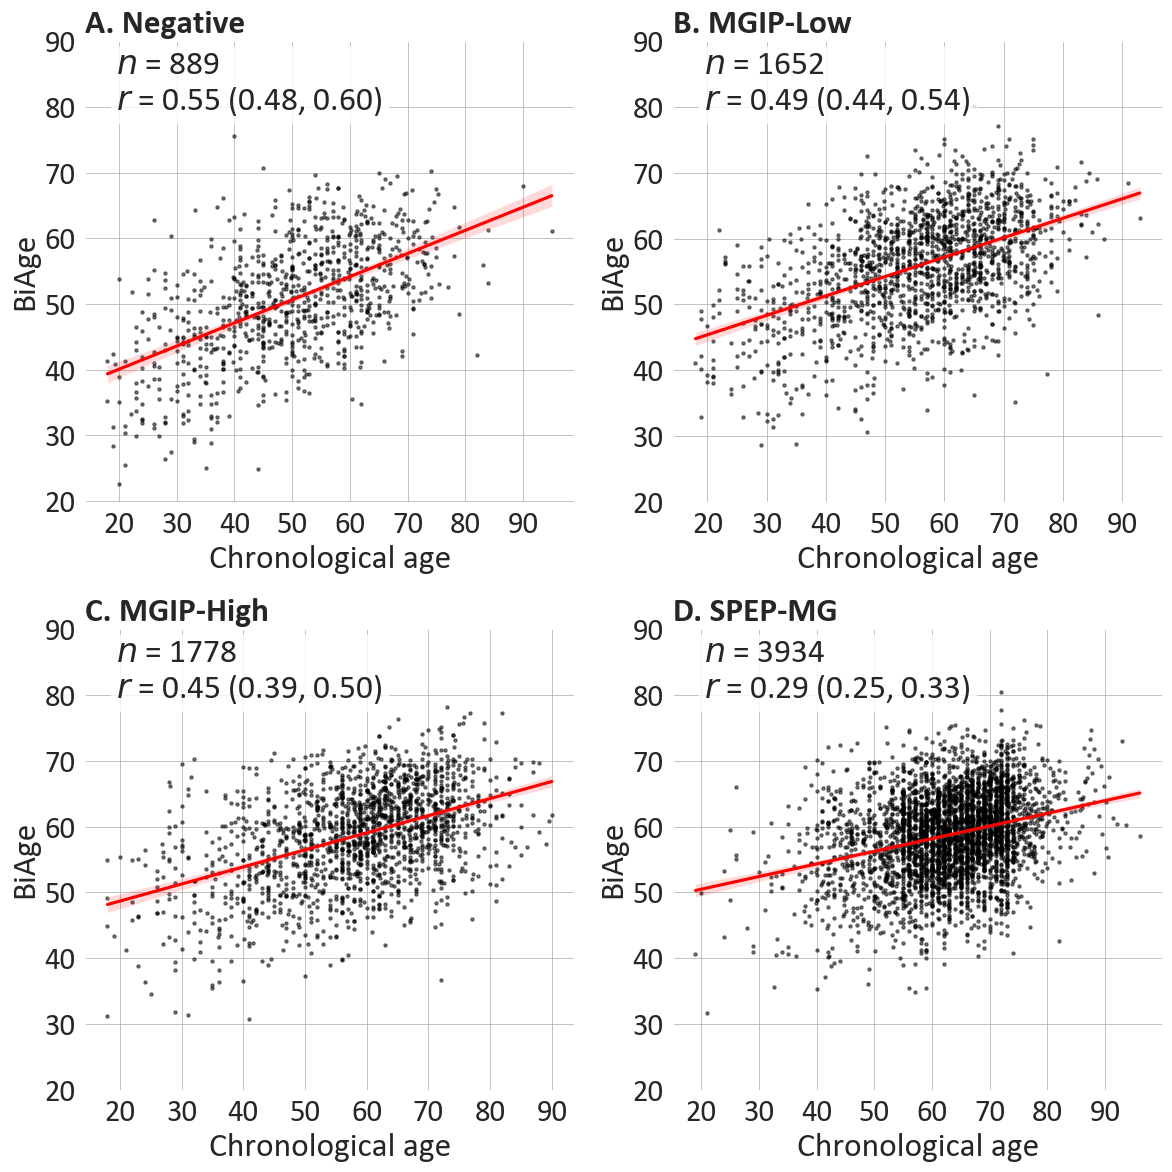

In [36]:
# compare predictions according to MG status for samles left out during training
# => Supplementary Figure S2
plot_data = [[dataset_test_negative.AGE.values, dataset_test_negative.BIAGE.values, "A. Negative", ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].BIAGE.values,
              "B. MGIP-Low", ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].BIAGE.values,
              "C. MGIP-High", ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].BIAGE.values,
              "D. SPEP-MG", ""]]

plt.figure(figsize=(2 * pp_size, 2 * pp_size))
for i, (trues, preds, suptitle, group_name) in enumerate(plot_data):
    plt.subplot(2, 2, i + 1)
    plot_lm(x=trues, y=preds, group_name=group_name,
            xlabel="Chronological age", ylabel="BiAge",
            xticks=[20, 30, 40, 50, 60, 70, 80, 90],
            yticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
            suptitle=suptitle,
            text_bbox_alpha=.8,
            scatter_kws_custom_alpha=.5,
            scatter_plot_custom_size=5,
            common_scale=False,
            confidence_level=.99)
plt.tight_layout()
plt.show()

We can use the data we used for those plots to also compute partial correlations, which means compute the correlation coefficient after accounting for the correlation with batch, to check if there is a batch effect in our BiAge prediction

Compute Pearson's r with p-value using 9999-iteration label shuffling (permutation method)

In [249]:
plot_data = [[dataset_test_negative.AGE.values,
              dataset_test_negative.BIAGE.values,
              "Negative",
              ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].BIAGE.values,
              "MGIP-Low",
              ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].BIAGE.values,
              "MGIP-High",
              ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].BIAGE.values,
              "SPEP-MG",
              ""]]

for i, (origin_x, origin_y, suptitle, group_name) in enumerate(plot_data):
    cor_inf = stats.pearsonr(origin_x, origin_y, method=stats.PermutationMethod(n_resamples=9999, random_state=1))
    res_p, res_r = cor_inf.pvalue, cor_inf.statistic

    print(f"BiAge correlation to chronological age in {suptitle}")
    print(f"Initial correlation coefficient:     r={res_r:.3f} (p={res_p:.4f})")
    print("-------------------------------------------------------")
    print("")

BiAge correlation to chronological age in Negative
Initial correlation coefficient:     r=0.546 (p=0.0002)
-------------------------------------------------------

BiAge correlation to chronological age in MGIP-Low
Initial correlation coefficient:     r=0.488 (p=0.0002)
-------------------------------------------------------

BiAge correlation to chronological age in MGIP-High
Initial correlation coefficient:     r=0.448 (p=0.0002)
-------------------------------------------------------

BiAge correlation to chronological age in SPEP-MG
Initial correlation coefficient:     r=0.291 (p=0.0002)
-------------------------------------------------------



In [58]:
plot_data = [[dataset_test_negative, "A. Negative"],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"], "B. MGIP-Low"],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"], "C. MGIP-High"],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"], "D. SPEP-MG"]]

for i, (df, suptitle) in enumerate(plot_data):
    print(f"For {suptitle} group, partial correlation between age and predicted BiAge, with 1 covariate (maldi plate):")
    print(pg.partial_corr(data=df, x="AGE", y="BIAGE", covar="INCREMENT_BATCH"))

For A. Negative group, partial correlation between age and predicted BiAge, with 1 covariate (maldi plate):
           n         r         CI95%         p-val
pearson  889  0.533729  [0.48, 0.58]  1.559640e-66
For B. MGIP-Low group, partial correlation between age and predicted BiAge, with 1 covariate (maldi plate):
            n         r         CI95%         p-val
pearson  1652  0.487522  [0.45, 0.52]  2.678166e-99
For C. MGIP-High group, partial correlation between age and predicted BiAge, with 1 covariate (maldi plate):
            n         r         CI95%         p-val
pearson  1778  0.449391  [0.41, 0.49]  4.724330e-89
For D. SPEP-MG group, partial correlation between age and predicted BiAge, with 1 covariate (maldi plate):
            n         r         CI95%         p-val
pearson  3934  0.295986  [0.27, 0.32]  2.338973e-80


In [60]:
print("For A. Negative group, comparing Age and predicted BiAge without covariate:")
print(pg.partial_corr(data=dataset_test_negative, x="AGE", y="BIAGE"))
print("For A. Negative group, comparing Age and batch:")
print(pg.partial_corr(data=dataset_test_negative, x="AGE", y="INCREMENT_BATCH"))
print("For A. Negative group, comparing Age and predicted BiAge with 1 covariate (maldi plate):")
print(pg.partial_corr(data=dataset_test_negative, x="AGE", y="BIAGE", covar=["INCREMENT_BATCH"]))
print("For A. Negative group, comparing Age and predicted BiAge with 2 covariates (race and sex)")
print(pg.partial_corr(data=dataset_test_negative, x="AGE", y="BIAGE", covar=["RACE_BINARY", "SEX_BINARY"]))
print("For A. Negative group, comparing Age and predicted BiAge with 3 covariates (maldi plate, race and sex)")
print(pg.partial_corr(data=dataset_test_negative, x="AGE", y="BIAGE", covar=["INCREMENT_BATCH", "RACE_BINARY", "SEX_BINARY"]))

For A. Negative group, comparing Age and predicted BiAge without covariate:
           n         r        CI95%         p-val
pearson  889  0.545865  [0.5, 0.59]  3.539082e-70
For A. Negative group, comparing Age and batch:
           n         r           CI95%     p-val
pearson  889 -0.143317  [-0.21, -0.08]  0.000018
For A. Negative group, comparing Age and predicted BiAge with 1 covariate (maldi plate):
           n         r         CI95%         p-val
pearson  889  0.533729  [0.48, 0.58]  1.559640e-66
For A. Negative group, comparing Age and predicted BiAge with 2 covariates (race and sex)
           n         r         CI95%         p-val
pearson  731  0.503411  [0.45, 0.56]  4.266009e-48
For A. Negative group, comparing Age and predicted BiAge with 3 covariates (maldi plate, race and sex)
           n         r         CI95%         p-val
pearson  731  0.504133  [0.45, 0.56]  3.463571e-48


In [61]:
for i, (df, suptitle) in enumerate(plot_data):
    print(f"For {suptitle} group, partial correlation between age and predicted BiAge, with 1 covariate (batch):")
    print(pg.partial_corr(data=df, x="AGE", y="BIAGE", covar="BATCH"))

For A. Negative group, partial correlation between age and predicted BiAge, with 1 covariate (batch):
           n         r         CI95%         p-val
pearson  889  0.540097  [0.49, 0.59]  2.185227e-68
For B. MGIP-Low group, partial correlation between age and predicted BiAge, with 1 covariate (batch):
            n         r         CI95%         p-val
pearson  1652  0.487234  [0.45, 0.52]  3.631122e-99
For C. MGIP-High group, partial correlation between age and predicted BiAge, with 1 covariate (batch):
            n         r         CI95%         p-val
pearson  1778  0.449286  [0.41, 0.49]  5.246065e-89
For D. SPEP-MG group, partial correlation between age and predicted BiAge, with 1 covariate (batch):
            n         r         CI95%         p-val
pearson  3934  0.297663  [0.27, 0.33]  2.723388e-81


Furthermore, we can also compute the correlation between chronological age and batch in our sample, to check if we have a batch effect

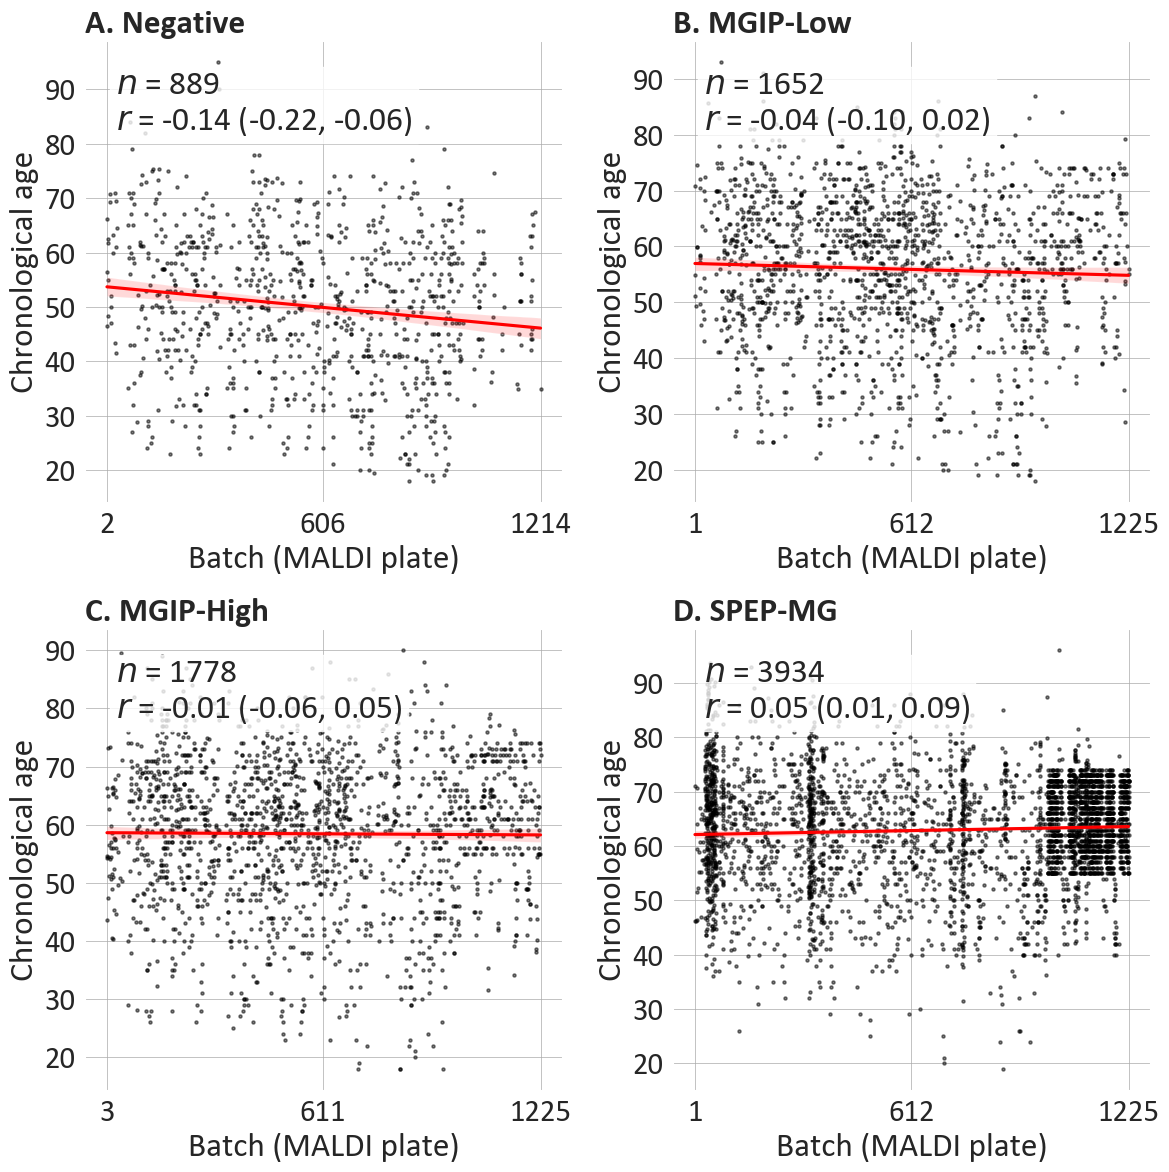

In [67]:
# is there any correlation between chrological age and batch number? => Supplementary Figure S3

plot_data = [[dataset_test_negative.AGE.values,
              dataset_test_negative.BIAGE.values,
              "A. Negative",
              "",
              dataset_test_negative.INCREMENT_BATCH.values],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].BIAGE.values,
              "B. MGIP-Low",
              "",
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].INCREMENT_BATCH.values],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].BIAGE.values,
              "C. MGIP-High",
              "",
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].INCREMENT_BATCH.values],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].BIAGE.values,
              "D. SPEP-MG",
              "",
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].INCREMENT_BATCH.values]]

plt.figure(figsize=(2 * pp_size, 2 * pp_size))
for i, (trues, _, suptitle, group_name, batches) in enumerate(plot_data):
    plt.subplot(2, 2, i + 1)
    plot_lm(x=batches, y=trues, group_name=group_name,
            xlabel="Batch (MALDI plate)", ylabel="Chronological age",
            xticks=[min(batches), (max(batches) - min(batches)) // 2, max(batches)],
            yticks=[20, 30, 40, 50, 60, 70, 80, 90],
            suptitle=suptitle,
            text_bbox_alpha=.8,
            scatter_kws_custom_alpha=.5,
            scatter_plot_custom_size=5,
            common_scale=False,
            confidence_level=.99)
plt.tight_layout()
plt.show()

Also, we can redo the same figure as **Supplementary Figure S2**, but this time using the BiAge predicting after masking the peaks from spectra, instead of using the original spectra

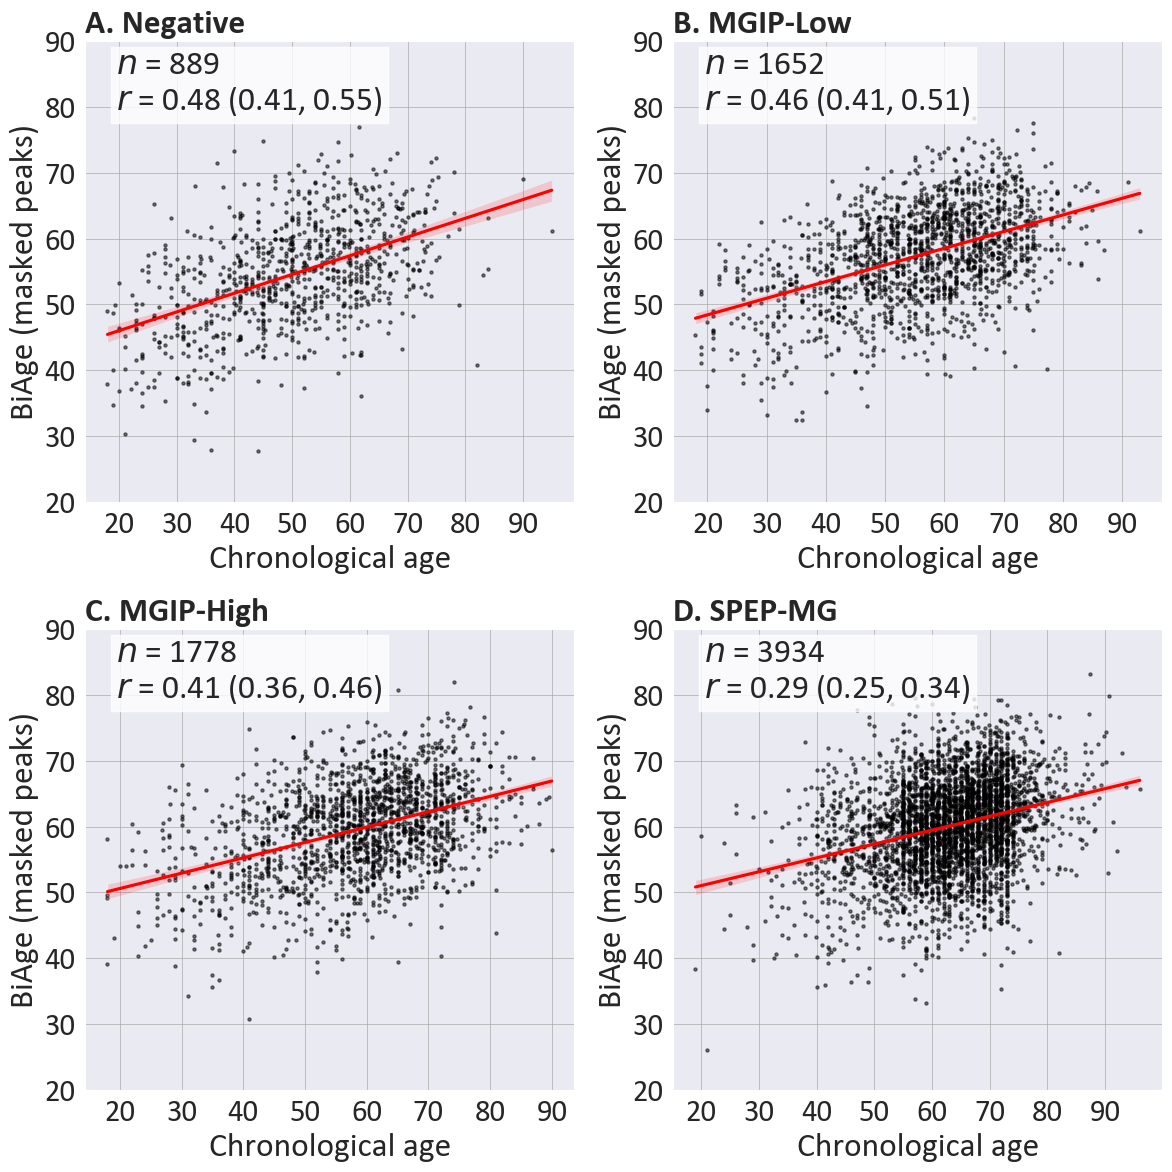

In [214]:
# same figure, but after masking peaks from the input data

plot_data = [[dataset_test_negative.AGE.values,
              dataset_test_negative.BIAGE_DROPOUT.values,
              "A. Negative",
              ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-Low"].BIAGE_DROPOUT.values,
              "B. MGIP-Low",
              ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGIP-High"].BIAGE_DROPOUT.values,
              "C. MGIP-High",
              ""],
             [dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].AGE.values,
              dataset_test_mg[dataset_test_mg.MG_DIAGNOSIS == "MGUS"].BIAGE_DROPOUT.values,
              "D. SPEP-MG",
              ""]]

plt.figure(figsize=(2 * pp_size, 2 * pp_size))
for i, (trues, preds, suptitle, group_name) in enumerate(plot_data):
    plt.subplot(2, 2, i + 1)
    plot_lm(x=trues, y=preds, group_name=group_name,
            xlabel="Chronological age", ylabel="BiAge (masked peaks)",
            xticks=[20, 30, 40, 50, 60, 70, 80, 90],
            yticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
            suptitle=suptitle,
            text_bbox_alpha=.8,
            scatter_kws_custom_alpha=.5,
            scatter_plot_custom_size=5,
            common_scale=False,
            confidence_level=.99)
plt.tight_layout()
plt.show()

To evaluate the impact of the number of monoclonal peaks in spectra in BiAge prediction, we can also visualize the BiAge predicted for patients according to the nubmer of peaks using a box plot

Since the representation of p-values in boxplots is simple (using stars), we below define a small function to use the data used for creating the box plots to also compute actual p values using mann whitney test and display those p-values

In [45]:
def boxplot_mannwhitney_test(ax, box_pairs, **kwargs):
    if kwargs["hue"] is None:
        for pair in box_pairs:
            left_values = kwargs["data"].loc[kwargs["data"][kwargs["x"]] == pair[0], kwargs["y"]].values
            right_values = kwargs["data"].loc[kwargs["data"][kwargs["x"]] == pair[1], kwargs["y"]].values
            p = stats.mannwhitneyu(left_values, right_values).pvalue
            print(
                f"Comparing x={pair[0]} (n={len(left_values)}, mean y: {np.mean(left_values):.2g}) vs. x={pair[1]} (n={len(right_values)}, mean y: {np.mean(right_values):.2g}): {p=:.2g}")
    else:
        for pair in box_pairs:
            left_values = kwargs["data"].loc[(kwargs["data"][kwargs["x"]] == pair[0][0]) & (kwargs["data"][kwargs["hue"]] == pair[0][1]), kwargs["y"]].values
            right_values = kwargs["data"].loc[(kwargs["data"][kwargs["x"]] == pair[1][0]) & (kwargs["data"][kwargs["hue"]] == pair[1][1]), kwargs["y"]].values
            p = stats.mannwhitneyu(left_values, right_values).pvalue
            print(
                f"Comparing x={pair[0]} and hue={pair[1]} (n={len(left_values)}, mean y: {np.mean(left_values):.2g}) vs. x={pair[1]} (n={len(right_values)}, mean y: {np.mean(right_values):.2g}): {p=:.2g}")


Then we can assess the impact of the number of peaks in spectra in BiAge prediction. This is **Supplementary Figure S7** in the manuscript

In [46]:
# Supplementary Figure S7
# check the impact of the number of monoclonal peaks on BiAge

biage_number_peaks_df = pd.concat([pd.Series(np.concatenate([np.array([0, ] * len(dataset_test_negative)),
                                                             dataset_test_mg.N_PEAKS_ABOVE_LOD.values]), name="n_peaks"),
                                   pd.Series(np.concatenate([dataset_test_negative.BIAGE.values,
                                                             dataset_test_mg.BIAGE.values]), name="BiAge"),
                                   pd.Series(np.concatenate([dataset_test_negative.AGE.values,
                                                             dataset_test_mg.AGE.values]), name="Age"),
                                   pd.Series(np.concatenate([dataset_test_negative.BIAGE_DROPOUT.values,
                                                             dataset_test_mg.BIAGE_DROPOUT.values]), name="BiAge (masked peaks)")], axis=1)
biage_number_peaks_df.n_peaks = biage_number_peaks_df.n_peaks.apply(lambda x: f"{x}" if x < 5 else "5+").astype("category").cat.set_categories(
    ["0", "1", "2", "3", "4", "5+"])
box_pairs = [
    ("0", "1"),
    ("0", "2"),
    ("0", "3"),
    ("0", "4"),
    ("0", "5+"),
]

plt.figure(figsize=(pp_size * 2, pp_size))
for i, peak_method in enumerate(["BiAge", "BiAge (masked peaks)"]):
    plt.subplot(1, 2, i + 1)
    boxplot_kwargs = {"data": biage_number_peaks_df, "x": "n_peaks", "y": peak_method, "hue": None}

    ax = plot_box(**boxplot_kwargs, xlabel="Number of\nmonoclonal peaks",
                  ylabel=peak_method,
                  yticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
                  legend_off=True,
                  palette="binary",
                  # subtype="precise_violinplot",
                  subtype="precise_violinplot+swarmplot",
                  swarmsize=1,
                  display_n_obs=True,
                  )

    if statannotations_available:
        annotator2 = Annotator(ax, box_pairs, **boxplot_kwargs)
        annotator2.configure(test='Mann-Whitney', text_format='star', loc='inside',
                             line_width=2.0, line_height=.01, text_offset=0)
        annotator2.apply_and_annotate()
    print(f"For {peak_method=}")
    boxplot_mannwhitney_test(ax, box_pairs, **boxplot_kwargs)
plt.tight_layout()
plt.show()

C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, hue=hue,
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.327e-74 U_stat=1.430e+06


C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


0 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:4.314e-120 U_stat=5.730e+05


C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


...

0 vs. 5+: Mann-Whitney-Wilcoxon test two-sided, P_val:4.058e-52 U_stat=5.677e+04


C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


For peak_method='BiAge (masked peaks)'
Comparing x=0 (n=1099, mean y: 55) vs. x=1 (n=4058, mean y: 58): p=1.1e-39
Comparing x=0 (n=1099, mean y: 55) vs. x=2 (n=2091, mean y: 60): p=5.8e-73
Comparing x=0 (n=1099, mean y: 55) vs. x=3 (n=843, mean y: 62): p=5.4e-81
Comparing x=0 (n=1099, mean y: 55) vs. x=4 (n=346, mean y: 63): p=1e-56
Comparing x=0 (n=1099, mean y: 55) vs. x=5+ (n=261, mean y: 63): p=4.1e-52


C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


KeyboardInterrupt: 

## BiAge predictions on subsets of patients

So far, we computed and observed how BiAge is predicted in all patients, regardless of chronological age, race, ethnicity and sex. We did not assess the impact of those demographic covariates which may impact BiAge. Below, we will try to create balanced subsets of patients, by matching 1:1 patients by chronological age and/or sex and/or race and/or ethnicity and/or monoclonal gammopathy status, and compare the BiAge predicted for those patients.

To perform this, we will first declare a `create_balanced_df` function that will allow us to create a balanced dataset after matching 1:1 patients according to the selected criteria

In [24]:
def create_balanced_df(full_df: pd.DataFrame,
                       group_column,
                       pair_columns):
    """
    creates a balanced df out of a full df

    :param full_df: the original DF
    :param group_column: which column will be used to make groups, i.e. groups we want to compare
    :param pair_columns: which columns will be used for pairing, i.e. we want to have the same distribution for all those pair columns for each group that exists in our final cohort
    :return:
    """
    # group_column = {"name": "Group", "values": ["Negative", "MGIP-Low", "MGIP-High", "MGUS"]}
    # pair_columns = [{"name": "Simplified_Batch", "values": []},
    #                 {"name": "RACE", "values": ["Black", "White"]},
    #                 {"name": "SEX", "values": ["F", "M"]},
    #                 {"name": "ETHNIC_GROUP", "values": ["Not Hispanic or Latino", "Hispanic or Latino"]},
    #                 {"name": "Age_rounded", "values": []}]

    full_df = full_df.copy()

    for coldata in [group_column, *pair_columns]:
        if len(coldata["values"]) > 0:
            full_df = full_df[full_df[coldata["name"]].isin(coldata["values"])]

    # to make the code lighter
    group_colname = group_column["name"]
    groups = full_df[group_colname].unique().tolist()
    n_groups = len(groups)

    # create a "pair label", i.e. a patient can be "black_female_61yo"
    full_df["Pair_Label"] = full_df[[m["name"] for m in pair_columns]].apply(concat_cols, axis=1)

    # group by both group and pair label, i.e. how many "black_female_61yo" in the "negative" vs "mgip" vs "mgus" groups
    group_results = full_df.groupby([group_colname, "Pair_Label"])["MS_ID"].count().reset_index()

    # now we can determine which labels may be productive, we want to keep only labels for which all groups are represented
    group_results = group_results[group_results.groupby("Pair_Label")["MS_ID"].transform("count") == n_groups]
    # now we can know how many samples we'll keep for each label: the minimum per group
    # e.g. if we have for the same pair label: 1 MGUS, 3 negs, 18 MGIP, we want to keep 1 of each so the groups are balanced
    group_results = group_results.groupby("Pair_Label")["MS_ID"].min().reset_index()

    # finally we can create our balanced df

    pre_balanced_df = []
    for group in groups:
        for label, n in zip(group_results.Pair_Label, group_results.MS_ID):
            subset = full_df[(full_df.Pair_Label == label) & (full_df[group_colname] == group)]
            pre_balanced_df.append(subset.sample(n, replace=False, random_state=1))

    balanced_df = pd.concat(pre_balanced_df, axis=0)
    print(f"{len(balanced_df)=}")

    return balanced_df

To use this function defined above, we will first use to create a `full_df`, i.e. a dataset containing all samples that might be of interest, meaning they have non-NA data filled in for the variables we want to use as criteria to match 1:1 patients (e.g. age, race, sex, etc.)
We will also add some metadata, for instance rounded Age (to match patients by approximate age, i.e. 50.3 and 50.1 years are +/- the same age)

Below we decare the different functions that will be useful for creating those datasets and required metadata/annotations

In [27]:
# create a dataset with all test negative and mg positive samples (which may be then used to match positive and negative samples)
def get_negative_and_mg_df():
    negative_df = dataset_test_negative
    mg_df = dataset_test_mg
    negative_and_mg_df = pd.concat([negative_df, mg_df], axis=0)
    # remove LC-MGUS -> we have too few and there are not "true" positives
    negative_and_mg_df = negative_and_mg_df[negative_and_mg_df.MG_DIAGNOSIS != "LC-MGUS"].copy()
    return negative_and_mg_df


def quick_create_pair_columns(race, sex, ethnic_group, age, diag, sbatch, ebatch, only_neg):
    pair_columns = []
    if race:
        pair_columns.append({"name": "RACE", "values": ["Black/African American", "White/European"]})
    if sbatch:
        pair_columns.append({"name": "BATCH", "values": []})
    if ebatch:
        pair_columns.append({"name": "INCREMENT_BATCH", "values": []})
    if sex:
        pair_columns.append({"name": "SEX", "values": ["F", "M"]})
    if ethnic_group:
        pair_columns.append({"name": "ETHNIC_GROUP", "values": ["Not Hispanic or Latino", "Hispanic or Latino"]})
    if diag:
        if only_neg:
            pair_columns.append({"name": "MG_DIAGNOSIS", "values": ["Negative", ]})
        else:
            pair_columns.append({"name": "MG_DIAGNOSIS", "values": ["Negative", "MGIP-Low", "MGIP-High", "MGUS", ]})
    if age:
        pair_columns.append({"name": "AGE_ROUNDED", "values": []})
    return pair_columns


def concat_cols(vals):
    concat_text = "_".join([v if type(v) is str else f"{v:.0f}" for v in vals])
    return concat_text

Now, we can create a balanced dataset by matching patients by race, sex, ehtnicity, chronological age, and simplified batch (i.e. the year the sample was processed). Meaning, in each group (negative vs. positive), patients will be matched 1:1 according to the criteria previously listed.

In [47]:
# PAIR_APPROACH = "AGE_RACE_ETHNICITY_SEX_SIMPBATCH"
ANALYSIS_BY = "MG_DIAGNOSIS"
PAIR_PARAMETERS = dict(race=True, sex=True, ethnic_group=True, age=True, diag=False, sbatch=True, ebatch=False, only_neg=False)
groups_ordered_values = ["Negative", "MGIP-Low", "MGIP-High", "MGUS"]

balanced_df = create_balanced_df(full_df=get_negative_and_mg_df(),
                                 group_column={"name": ANALYSIS_BY, "values": groups_ordered_values},
                                 pair_columns=quick_create_pair_columns(**PAIR_PARAMETERS))

len(balanced_df)=1504


In [29]:
balanced_df

,MS_ID,COHORT,INCREMENT_BATCH,BATCH,RACE,ETHNIC_GROUP,AGE,SEX,FLCRATIO,MG_DIAGNOSIS,...,TOTAL_MSPIKES_CONC_PCT,RACE_BINARY,SEX_BINARY,AGE_ROUNDED,AGE_RANGE,AGE_CLASS,AGE_STANDARDIZED,BIAGE,BIAGE_DROPOUT,Pair_Label
145,MS0dVwSfjq,MGB,357,1,Black/African American,Not Hispanic or Latino,28.000000,F,1.011471,Negative,...,0.000000,1.0,1.0,28.0,<50,<50,-1.674991,54.661964,56.337708,Black/African American_1_F_Not Hispanic or Lat...
629,MSouR6bFai,MGB,184,1,Black/African American,Not Hispanic or Latino,29.000000,F,1.486401,Negative,...,0.000405,1.0,1.0,29.0,<50,<50,-1.601199,60.313401,63.188530,Black/African American_1_F_Not Hispanic or Lat...
56,MSWG5LXPFn,MGB,568,1,Black/African American,Not Hispanic or Latino,34.000000,F,1.043540,Negative,...,0.000000,1.0,1.0,34.0,<50,<50,-1.232240,53.518439,54.817056,Black/African American_1_F_Not Hispanic or Lat...
671,MS2ivEPGGU,MGB,606,1,Black/African American,Not Hispanic or Latino,35.000000,F,1.911194,Negative,...,0.000000,1.0,1.0,35.0,<50,<50,-1.158448,46.561127,50.837655,Black/African American_1_F_Not Hispanic or Lat...
872,MScfzmGueB,MGB,471,1,Black/African American,Not Hispanic or Latino,35.000000,F,1.924884,Negative,...,0.000000,1.0,1.0,35.0,<50,<50,-1.158448,37.940029,42.378155,Black/African American_1_F_Not Hispanic or Lat...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6296,MSI8HyZz5c,PLCO,1135,3,White/European,Not Hispanic or Latino,70.000000,F,1.465991,MGIP-High,...,0.030796,0.0,1.0,70.0,>65,>65,1.424265,58.145656,55.571180,White/European_3_F_Not Hispanic or Latino_70
2401,MScQLjrGYI,MGB,900,3,White/European,Not Hispanic or Latino,75.000000,F,1.144986,MGIP-High,...,0.004492,0.0,1.0,75.0,>65,>65,1.793224,64.319488,64.497018,White/European_3_F_Not Hispanic or Latino_75
6383,MSXLnliR81,PLCO,1087,3,White/European,Not Hispanic or Latino,60.000000,M,1.960022,MGIP-High,...,0.010918,0.0,0.0,60.0,50-65,Out,0.686347,58.267090,50.465552,White/European_3_M_Not Hispanic or Latino_60
4180,MSCg20wRRx,PROMISE_USA,1105,3,White/European,Not Hispanic or Latino,61.956164,M,1.341056,MGIP-High,...,0.014614,0.0,0.0,62.0,50-65,Out,0.830696,62.331126,54.110989,White/European_3_M_Not Hispanic or Latino_62


In [30]:
if balanced_df["TOTAL_MSPIKES_CONC_PCT"].max() < 1:
    balanced_df["TOTAL_MSPIKES_CONC_PCT"] = balanced_df["TOTAL_MSPIKES_CONC_PCT"] * 100  # convert 0-1 to 0-100% scale

For those patients, we can look at the correlation between BiAge predicted without or after masking peaks

C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\_lib\_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
C:\Users\flori\anaconda3\envs\py311_torch21gpu_feb25\Lib\site-packages\scipy\_lib\_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
C:\Users\flo

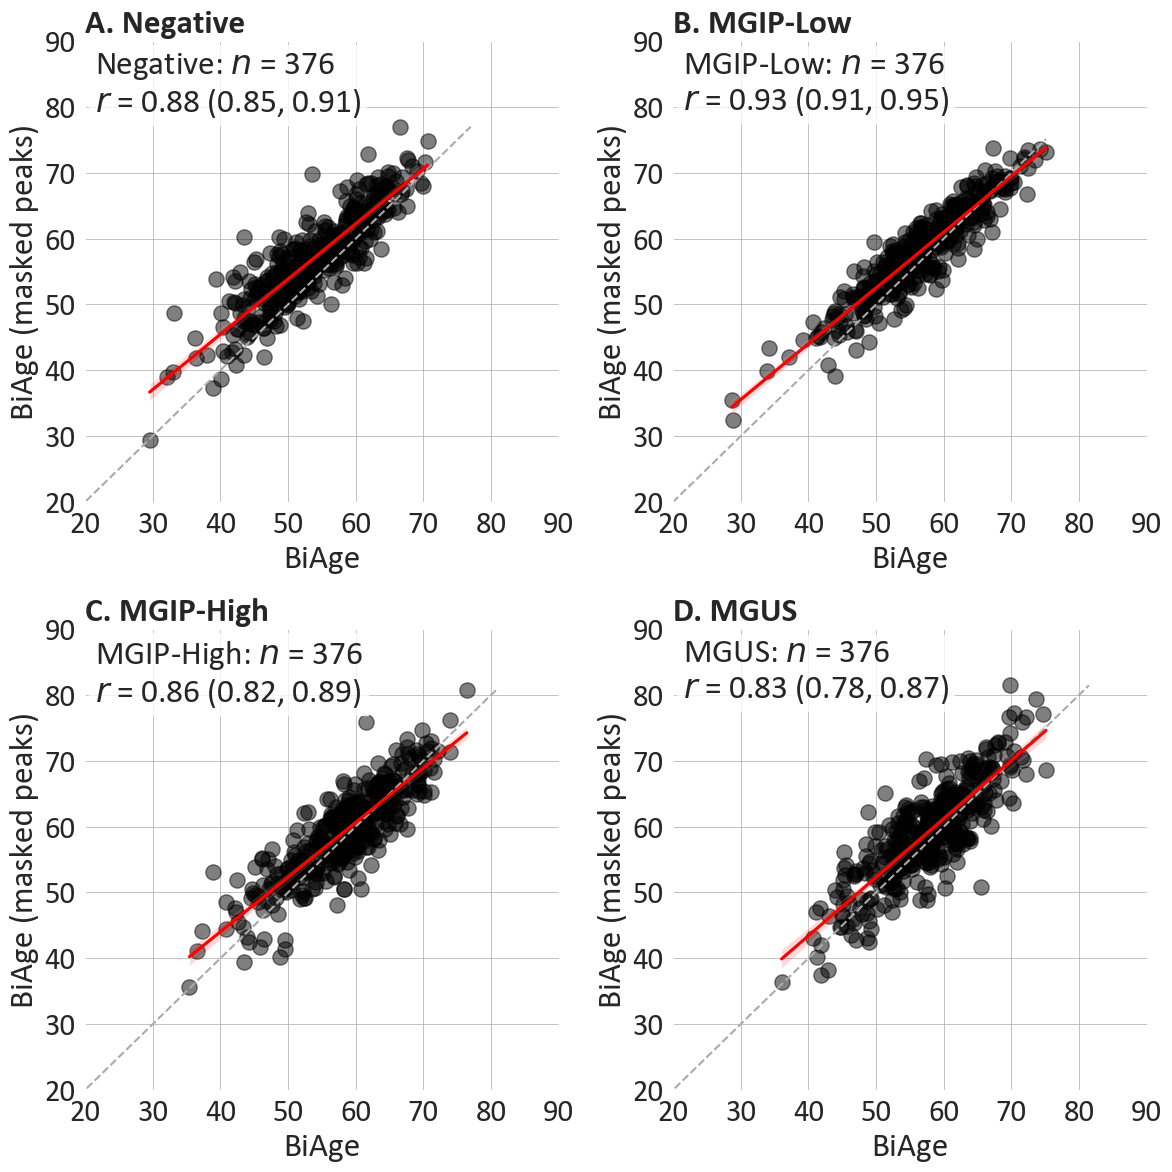

In [48]:
# correlation: biage vs biage when peaks are removed (not in the current manuscript figures but useful)

plt.figure(figsize=(pp_size * 2, pp_size * 2))
# gs = gridspec.GridSpec(1, 2)
for j, group in enumerate(["Negative", "MGIP-Low", "MGIP-High", "MGUS"]):
    # plt.subplot(gs[0,j])
    plt.subplot(2, 2, j + 1)
    x = balanced_df[balanced_df.MG_DIAGNOSIS == group].BIAGE.values
    y = balanced_df[balanced_df.MG_DIAGNOSIS == group].BIAGE_DROPOUT.values
    plot_lm(x=x, y=y, group_name=group, xlabel="BiAge", ylabel="BiAge (masked peaks)",
            xticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-2., -1., 0, 1., 2.]),
            yticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-2., -1., 0, 1., 2.]),
            suptitle="ABCD"[j] + ". " + group,
            common_scale=True,
            text_bbox_alpha=.8,
            confidence_level=.99)
plt.tight_layout()
plt.show()

Now that we have a balanced dataset, with negative and positive samples matched 1:1, we can compute the BiAge of patients according to their MG group
If MG has no impact on predicted BiAge, the BiAge distributions predicted for all groups should be similar, since patients in each group have the same characteristics (same age, race, sex, ethnicity distribution)

This is **Figure 2** in the manuscript

C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:226: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#999999'` for the same effect.

  sns.swarmplot(data=data, x=x, y=y, hue=hue,
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

<50 years_Negative vs. <50 years_MGIP-Low: Mann-Whitney-Wilcoxon test two-sided, P_val:1.247e-03 U_stat=4.349e+03
>65 years_Negative vs. >65 years_MGIP-Low: Mann-Whitney-Wilcoxon test two-sided, P_val:2.689e-03 U_stat=2.649e+03
<50 years_Negative vs. <50 years_MGIP-High: Mann-Whitney-Wilcoxon test two-sided, P_val:1.486e-06 U_stat=3.621e+03
>65 years_Negative vs. >65 years_MGIP-High: Mann-Whitney-Wilcoxon test two-sided, P_val:1.726e-05 U_stat=2.233e+03
<50 years_Negative vs. <50 years_MGUS: Mann-Whitney-Wilcoxon test two-sided, P_val:1.745e-07 U_stat=3.432e+03
>65 years_Negative vs. >65 years_MGUS: Mann-Whitney-Wilcoxon test two-sided, P_val:3.383e-04 U_stat=2.462e+03
Comparing x=('<50 years', 'Negative') and hue=('<50 years', 'MGIP-Low') (n=108, mean y: 50) vs. x=('<50 years', 'MGIP-Low') (n=108

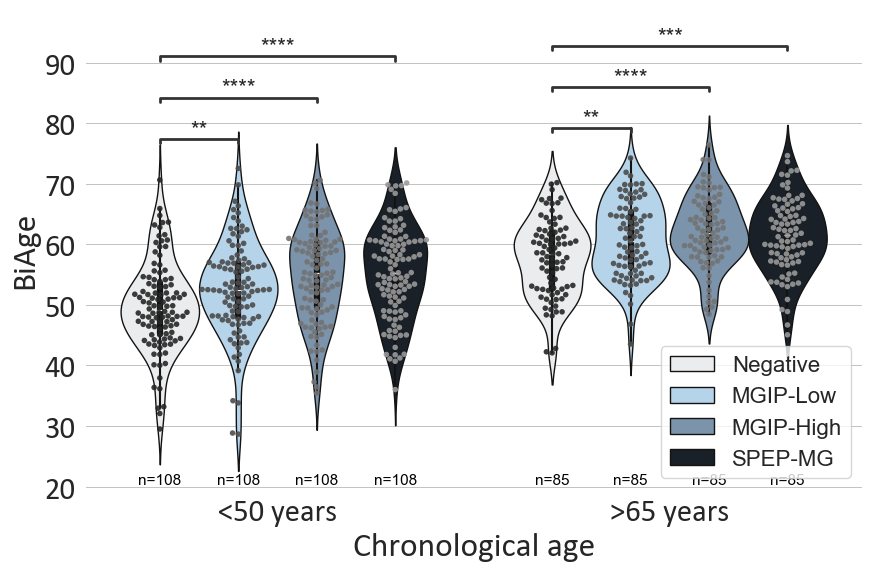

C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:226: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#999999'` for the same effect.

  sns.swarmplot(data=data, x=x, y=y, hue=hue,
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

<50 years_Negative vs. <50 years_MGIP-Low: Mann-Whitney-Wilcoxon test two-sided, P_val:2.445e-01 U_stat=5.297e+03
>65 years_Negative vs. >65 years_MGIP-Low: Mann-Whitney-Wilcoxon test two-sided, P_val:2.740e-01 U_stat=3.261e+03
<50 years_Negative vs. <50 years_MGIP-High: Mann-Whitney-Wilcoxon test two-sided, P_val:6.304e-03 U_stat=4.577e+03
>65 years_Negative vs. >65 years_MGIP-High: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=2.910e+03
<50 years_Negative vs. <50 years_MGUS: Mann-Whitney-Wilcoxon test two-sided, P_val:1.855e-03 U_stat=4.402e+03
>65 years_Negative vs. >65 years_MGUS: Mann-Whitney-Wilcoxon test two-sided, P_val:1.926e-02 U_stat=2.861e+03
Comparing x=('<50 years', 'Negative') and hue=('<50 years', 'MGIP-Low') (n=108, mean y: 54) vs. x=('<50 years', 'MGIP-Low') (n=108

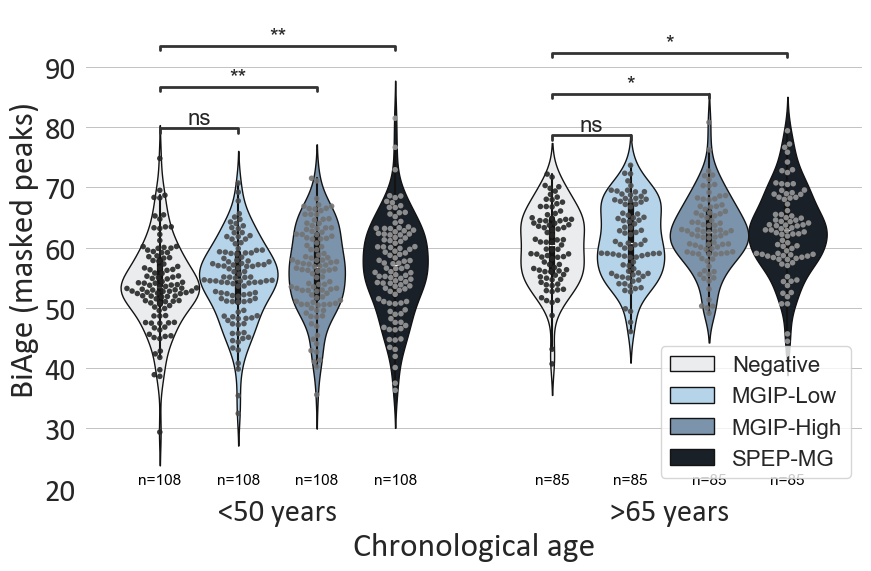

In [49]:
# FIGURE 2A AND 2D

for peak_method in ("BIAGE", "BIAGE_DROPOUT"):
    # check which patients are below 50 or above 65
    boxplot_data = balanced_df[(balanced_df.AGE_ROUNDED <= 50) | (balanced_df.AGE_ROUNDED >= 65)].copy()
    # reorder
    format_age = lambda x: "<50 years" if x <= 50 else ">65 years" if x >= 65 else "err"

    boxplot_data["Age range"] = boxplot_data.AGE_ROUNDED.map(format_age)
    boxplot_data["Age range"] = boxplot_data["Age range"].astype("category").cat.set_categories(["<50 years", ">65 years"])
    boxplot_data["Group"] = boxplot_data.MG_DIAGNOSIS.astype("category").cat.set_categories(["Negative", "MGIP-Low", "MGIP-High", "MGUS"])

    box_pairs = [
        (("<50 years", "Negative"), ("<50 years", "MGIP-Low")),
        (("<50 years", "Negative"), ("<50 years", "MGIP-High")),
        (("<50 years", "Negative"), ("<50 years", "MGUS")),
        ((">65 years", "Negative"), (">65 years", "MGIP-Low")),
        ((">65 years", "Negative"), (">65 years", "MGIP-High")),
        ((">65 years", "Negative"), (">65 years", "MGUS")),
    ]
    boxplot_kwargs = {"data": boxplot_data, "x": "Age range", "y": peak_method, "hue": "Group"}
    plt.figure(figsize=(pp_size * 1.5, pp_size))
    ax = plot_box(**boxplot_kwargs,
                  yticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
                  xlabel="Chronological age",
                  palette="mg_custom_cmap",  # 12.27 => replaced binary
                  ylabel="BiAge" if peak_method == "BIAGE" else "BiAge (masked peaks)" if peak_method == "BIAGE_DROPOUT" else "?",
                  legend_loc="outside",
                  # subtype="precise_violinplot",
                  subtype="precise_violinplot+swarmplot",
                  swarmsize=4,
                  )
    # manually change the "MGUS" legend
    handles, labels = ax.get_legend_handles_labels()
    labels = ["SPEP-MG" if l == "MGUS" else l for l in labels]
    ax.legend(handles, labels)

    if statannotations_available:
        annotator2 = Annotator(ax, box_pairs, **boxplot_kwargs)
        annotator2.configure(test='Mann-Whitney', loc='inside', text_format='star',
                             line_width=2.0, line_height=.01, text_offset=0)
        annotator2.apply_and_annotate()
    boxplot_mannwhitney_test(ax, box_pairs, **boxplot_kwargs)

    plt.tight_layout()
    plt.show()

Next, we can recreate a new balanced dataset, this time matching patients with different race (i.e. a black and a white group, each group with the same distribution of the other characteristics)

In [56]:
ANALYSIS_BY = "RACE"
groups_ordered_values = ["Black/African American", "White/European"]
ANALYSIS_BY_PLACEHOLDER = "Self-declared race"
groups_ordered_values_placeholder = ["Black/African American", "White/European"]
placeholder_dict = {"Black/African American": "Black/African American", "White/European": "White/European"}
PAIR_PARAMETERS = dict(race=False, sex=True, ethnic_group=True, age=True, diag=True, sbatch=True, ebatch=False, only_neg=False)

balanced_df = create_balanced_df(full_df=get_negative_and_mg_df(),
                                 group_column={"name": ANALYSIS_BY, "values": groups_ordered_values},
                                 pair_columns=quick_create_pair_columns(**PAIR_PARAMETERS))

len(balanced_df)=3350


So we can now plot the BiAge in participants according to race, without other characteristic/pathology interfering. This is **Supplementary Figure S5 A** in the manuscript

For convenience, we will design a function to perform the box plot, and re-use this function multiple time for different figures

In [69]:
def boxplot_predicted_quantative_versus_gt_class_subroutine(balanced_df, peak_method, peak_method_ticks,
                                                            ANALYSIS_BY, groups_ordered_values,
                                                            placeholder_dict,
                                                            ANALYSIS_BY_PLACEHOLDER, groups_ordered_values_placeholder,
                                                            peak_method_2_label,
                                                            separate_mgs_into_hue,
                                                            add_carreturn: bool = True,
                                                            swarmsize=None,
                                                            ax=None):
    boxplot_data = balanced_df[balanced_df[ANALYSIS_BY].isin(groups_ordered_values)].copy()
    # convert if needed
    if placeholder_dict is not None:
        boxplot_data[ANALYSIS_BY_PLACEHOLDER] = boxplot_data[ANALYSIS_BY].map(placeholder_dict)
    # reorder and convert our analysis by group to category
    boxplot_data[ANALYSIS_BY_PLACEHOLDER] = boxplot_data[ANALYSIS_BY_PLACEHOLDER].astype("category").cat.set_categories(
        groups_ordered_values_placeholder)
    if separate_mgs_into_hue:
        # which groups we will compare => also convert to category
        if "Negative" in boxplot_data.MG_DIAGNOSIS.unique():
            if add_carreturn:
                boxplot_data["Group"] = boxplot_data.MG_DIAGNOSIS.map(
                    {"Negative": "Negative", "MGIP-Low": "MGIP\nLow", "MGIP-High": "MGIP\nHigh", "MGUS": "MGUS"}
                ).astype("category").cat.set_categories(["Negative", "MGIP\nLow", "MGIP\nHigh", "MGUS"])
                # create the dict for parameters used for plotting
                boxplot_kwargs = {"data": boxplot_data, "hue": ANALYSIS_BY_PLACEHOLDER, "y": peak_method, "x": "Group"}
                # how we will annotate (p values)
                box_pairs = [[(mg, grp,) for grp in groups_ordered_values_placeholder] for mg in
                             ["Negative", "MGIP\nLow", "MGIP\nHigh", "MGUS"]]
            else:
                boxplot_data["Group"] = boxplot_data.MG_DIAGNOSIS.astype("category").cat.set_categories(["Negative", "MGIP-Low", "MGIP-High", "MGUS"])
                # create the dict for parameters used for plotting
                boxplot_kwargs = {"data": boxplot_data, "hue": ANALYSIS_BY_PLACEHOLDER, "y": peak_method, "x": "Group"}
                # how we will annotate (p values)
                box_pairs = [[(mg, grp,) for grp in groups_ordered_values_placeholder] for mg in
                             ["Negative", "MGIP-Low", "MGIP-High", "MGUS"]]
        else:
            if add_carreturn:
                boxplot_data["Group"] = boxplot_data.MG_DIAGNOSIS.map(
                    {"MGIP-Low": "MGIP\nLow", "MGIP-High": "MGIP\nHigh", "MGUS": "MGUS"}
                ).astype("category").cat.set_categories(["MGIP\nLow", "MGIP\nHigh", "MGUS"])
                # create the dict for parameters used for plotting
                boxplot_kwargs = {"data": boxplot_data, "hue": ANALYSIS_BY_PLACEHOLDER, "y": peak_method, "x": "Group"}
                # how we will annotate (p values)
                box_pairs = [[(mg, grp,) for grp in groups_ordered_values_placeholder] for mg in
                             ["MGIP\nLow", "MGIP\nHigh", "MGUS"]]
            else:
                boxplot_data["Group"] = boxplot_data.MG_DIAGNOSIS.astype("category").cat.set_categories(["MGIP-Low", "MGIP-High", "MGUS"])
                # create the dict for parameters used for plotting
                boxplot_kwargs = {"data": boxplot_data, "hue": ANALYSIS_BY_PLACEHOLDER, "y": peak_method, "x": "Group"}
                # how we will annotate (p values)
                box_pairs = [[(mg, grp,) for grp in groups_ordered_values_placeholder] for mg in
                             ["MGIP-Low", "MGIP-High", "MGUS"]]
        legend_off = False
        figname = f"boxplot_bymg_{peak_method}.png"
    else:
        # create the dict for parameters used for plotting
        boxplot_kwargs = {"data": boxplot_data, "x": ANALYSIS_BY_PLACEHOLDER, "y": peak_method, "hue": None}
        # how we will annotate (p values)
        box_pairs = [(*groups_ordered_values_placeholder,), ]
        legend_off = True  # no hue
        width = pp_size
        figname = f"boxplot_allmg_{peak_method}.png".replace("/", "_")

    # ax = sns.boxplot(**boxplot_kwargs)
    ax = plot_box(**boxplot_kwargs,
                  yticks=peak_method_ticks,
                  xlabel=boxplot_kwargs["x"],
                  ylabel=peak_method_2_label[peak_method],
                  palette="binary",
                  legend_off=legend_off,
                  legend_loc="outside",
                  # subtype="precise_violinplot",
                  subtype="precise_violinplot+swarmplot",
                  swarmsize=swarmsize,
                  ax=ax,
                  )
    # stars
    if statannotations_available:
        annotator2 = Annotator(ax, box_pairs, **boxplot_kwargs)
        annotator2.configure(test='Mann-Whitney', text_format='star', loc='inside',
                             line_width=2.0, line_height=.01, text_offset=0)
        annotator2.apply_and_annotate()

    return ax, figname

Supplementary Figures S5 A (BiAge according to race)

C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, hue=hue,
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Black/African American vs. White/European: Mann-Whitney-Wilcoxon test two-sided, P_val:7.520e-01 U_stat=9.179e+03


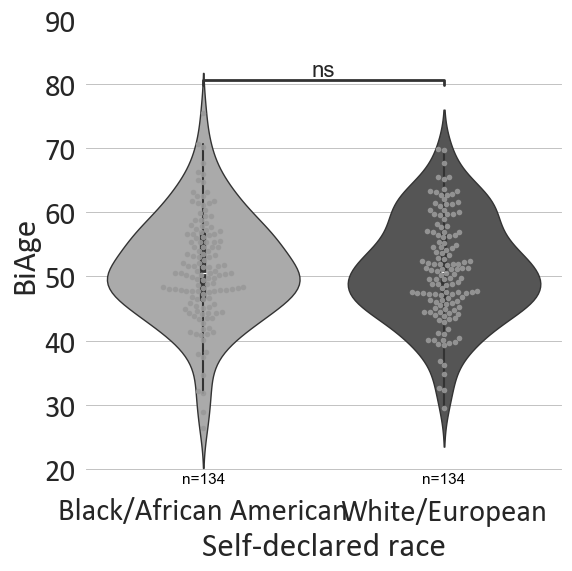

In [58]:
# SUPPLEMENTARY FIGURE S5 A

plt.figure(figsize=(pp_size, pp_size))
boxplot_predicted_quantative_versus_gt_class_subroutine(
    balanced_df=balanced_df[balanced_df.MG_DIAGNOSIS == "Negative"],
    peak_method="BIAGE",
    peak_method_ticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
    ANALYSIS_BY=ANALYSIS_BY, groups_ordered_values=groups_ordered_values,
    placeholder_dict=placeholder_dict,
    ANALYSIS_BY_PLACEHOLDER=ANALYSIS_BY_PLACEHOLDER,
    groups_ordered_values_placeholder=groups_ordered_values_placeholder,
    peak_method_2_label={"BIAGE": "BiAge", "BIAGE_DROPOUT": "BiAge (masked peaks)"},
    separate_mgs_into_hue=False,
    add_carreturn=False,
    swarmsize=4,
    ax=None)
plt.tight_layout()
plt.show()

If we do the same after grouping by sex, we obtain **Supplementary Figure S5 B** in the manuscript

In [60]:
# PAIR_APPROACH = "AGE_RACE_ETHNICITY_SIMPBATCH_MG_BY_SEX"
ANALYSIS_BY = "SEX"
groups_ordered_values = ["F", "M"]
PAIR_PARAMETERS = dict(race=True, sex=False, ethnic_group=True, age=True, diag=True, sbatch=True, ebatch=False, only_neg=False)
ANALYSIS_BY_PLACEHOLDER = "Sex"
groups_ordered_values_placeholder = ["Female", "Male"]
placeholder_dict = {"F": "Female", "M": "Male"}

balanced_df = create_balanced_df(full_df=get_negative_and_mg_df(),
                                 group_column={"name": ANALYSIS_BY, "values": groups_ordered_values},
                                 pair_columns=quick_create_pair_columns(**PAIR_PARAMETERS))

len(balanced_df)=4352


C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, hue=hue,
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Female vs. Male: Mann-Whitney-Wilcoxon test two-sided, P_val:7.789e-01 U_stat=1.161e+04


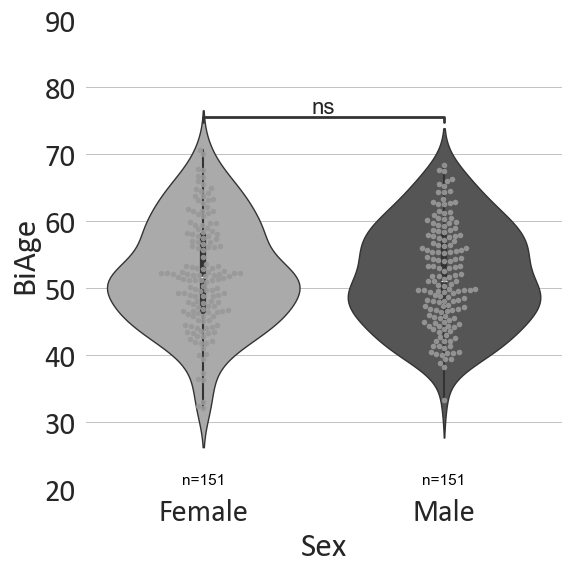

In [64]:
# SUPPLEMENTARY FIGURE S5 B

plt.figure(figsize=(pp_size, pp_size))
boxplot_predicted_quantative_versus_gt_class_subroutine(
    balanced_df=balanced_df[balanced_df.MG_DIAGNOSIS == "Negative"],
    peak_method="BIAGE",
    peak_method_ticks=(([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.])),
    ANALYSIS_BY=ANALYSIS_BY, groups_ordered_values=groups_ordered_values,
    placeholder_dict=placeholder_dict,
    ANALYSIS_BY_PLACEHOLDER=ANALYSIS_BY_PLACEHOLDER,
    groups_ordered_values_placeholder=groups_ordered_values_placeholder,
    peak_method_2_label={"BIAGE": "BiAge", "BIAGE_DROPOUT": "BiAge (masked peaks)"},
    separate_mgs_into_hue=False,
    add_carreturn=False,
    swarmsize=4,
    ax=None)
plt.tight_layout()
plt.show()

Finally, we can match the patients into two groups by age class, to see if older patients are predicted a higher BiAge, without interference from other demographic characteristics/MG status

In [65]:
# PAIR_APPROACH = "RACE_SEX_ETHNICITY_SIMPBATCH_MG_BY_AGECLASS"
ANALYSIS_BY = "AGE_CLASS"
groups_ordered_values = ["<50", ">65"]
PAIR_PARAMETERS = dict(race=True, sex=True, ethnic_group=True, age=False, diag=True, sbatch=True, ebatch=False, only_neg=False)
ANALYSIS_BY_PLACEHOLDER = "Chronological age"
# groups_ordered_values_placeholder = groups_ordered_values
groups_ordered_values_placeholder = [l + " years" for l in groups_ordered_values]
placeholder_dict = {a: b for a, b in zip(groups_ordered_values, groups_ordered_values_placeholder)}

balanced_df = create_balanced_df(full_df=get_negative_and_mg_df(),
                                 group_column={"name": ANALYSIS_BY, "values": groups_ordered_values},
                                 pair_columns=quick_create_pair_columns(**PAIR_PARAMETERS))

len(balanced_df)=1854


C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, hue=hue,
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

<50 years vs. >65 years: Mann-Whitney-Wilcoxon test two-sided, P_val:7.869e-13 U_stat=1.797e+03


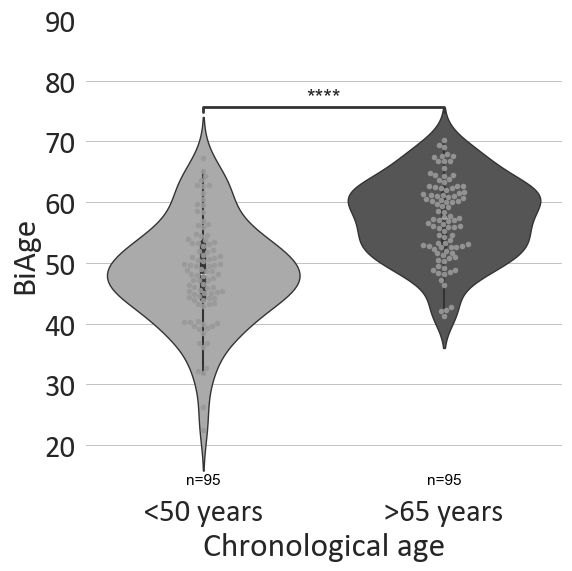

In [67]:
# SUPPLEMENTARY FIGURE S4 A

plt.figure(figsize=(pp_size, pp_size))
boxplot_predicted_quantative_versus_gt_class_subroutine(
    balanced_df=balanced_df[balanced_df.MG_DIAGNOSIS == "Negative"],
    peak_method="BIAGE",
    peak_method_ticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
    ANALYSIS_BY=ANALYSIS_BY, groups_ordered_values=groups_ordered_values,
    placeholder_dict=placeholder_dict,
    ANALYSIS_BY_PLACEHOLDER=ANALYSIS_BY_PLACEHOLDER,
    groups_ordered_values_placeholder=groups_ordered_values_placeholder,
    peak_method_2_label={"BIAGE": "BiAge", "BIAGE_DROPOUT": "BiAge (masked peaks)"},
    separate_mgs_into_hue=False,
    add_carreturn=False,
    swarmsize=4,
    ax=None)
plt.tight_layout()
plt.show()

And similarly for patients with different MG status (MGIP, MGUS):

C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:226: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#999999'` for the same effect.

  sns.swarmplot(data=data, x=x, y=y, hue=hue,
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MGIP-High_<50 years vs. MGIP-High_>65 years: Mann-Whitney-Wilcoxon test two-sided, P_val:1.937e-26 U_stat=1.334e+04
MGIP-Low_<50 years vs. MGIP-Low_>65 years: Mann-Whitney-Wilcoxon test two-sided, P_val:2.365e-33 U_stat=1.760e+04
MGUS_<50 years vs. MGUS_>65 years: Mann-Whitney-Wilcoxon test two-sided, P_val:1.620e-17 U_stat=2.650e+04


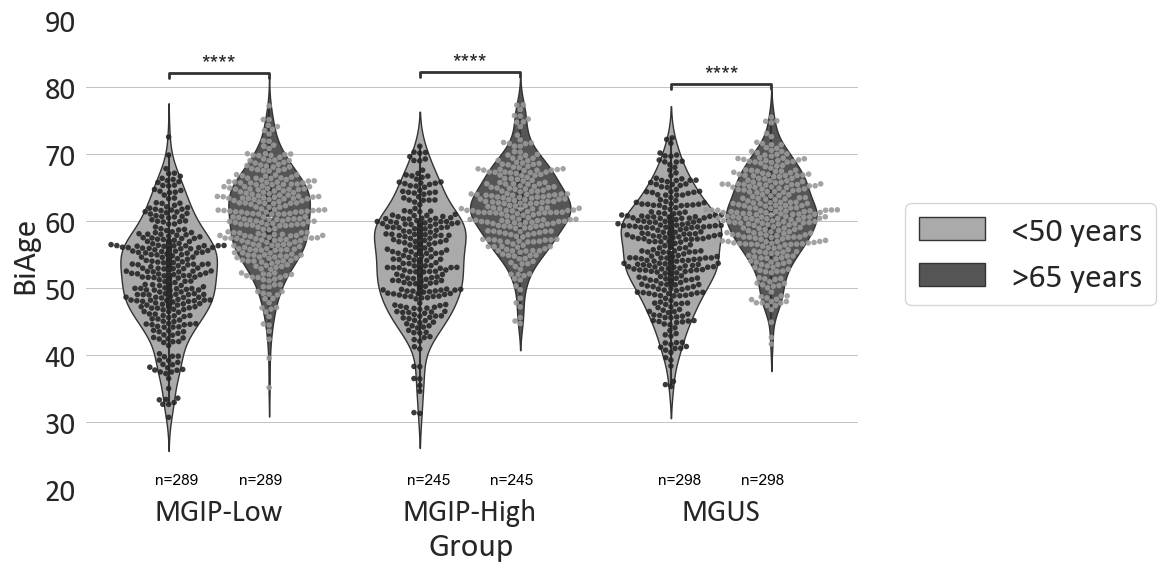

In [70]:
# SUPPLEMENTARY FIGURE S4 B

plt.figure(figsize=(pp_size * 2, pp_size))
boxplot_predicted_quantative_versus_gt_class_subroutine(
    balanced_df=balanced_df[balanced_df.MG_DIAGNOSIS != "Negative"],
    peak_method="BIAGE",
    peak_method_ticks=([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.]),
    ANALYSIS_BY=ANALYSIS_BY, groups_ordered_values=groups_ordered_values,
    placeholder_dict=placeholder_dict,
    ANALYSIS_BY_PLACEHOLDER=ANALYSIS_BY_PLACEHOLDER,
    groups_ordered_values_placeholder=groups_ordered_values_placeholder,
    peak_method_2_label={"BIAGE": "BiAge", "BIAGE_DROPOUT": "BiAge (masked peaks)"},
    separate_mgs_into_hue=True,
    add_carreturn=False,
    swarmsize=4,
    ax=None)
plt.tight_layout()
plt.show()

# Feature exploration

First, we will declare all functions that will be used to extract the features from raw spectra

The code below will be responsible of converting a raw spectrum trace into gaussians representing the different sub populations (lambda 1, kappa 1, lambda 2, kappa 2, etc.)

In [71]:
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks, peak_prominences
from pybaselines import Baseline

# default parameters
DEFAULT_GAUSSIANS = ["ll", "lk", "hl", "hk", "c1q"]
DEFAULT_GAUSSIAN_NAMES = [["λ1", "κ1", "λ2", "κ2", "C1q"],
                          ["λ1", "κ1", "λ2", "κ2", "C1q"],
                          ["λ1", "κ1", "λ2", "κ2", "C1q"],
                          ["λ1", "κ1", "λ2", "κ2", "C1q"],
                          ["λ1", "κ1", "λ2", "κ2", "C1q"], ]
DEFAULT_ISOTYPES = "GAMKL"
DEFAULT_HARDCODED_PARAMS = {'ll_mz': 11414, 'll_width': 150.,
                            'lk_mz': 11701, 'lk_width': 150.,
                            'hl_mz': 11752, 'hl_width': 200.,
                            'hk_mz': 12060, 'hk_width': 200.,
                            'c1q_mz': 12018, 'c1q_width': 15.,
                            }
DEFAULT_INIT_GLOBAL_PARAMS = {
    "ll_mz_mod": 0, "lk_mz_mod": 0, "hl_mz_mod": 0, "hk_mz_mod": 0, "c1q_mz_mod": 0,
    "iso0_mz_mod": 0, "iso1_mz_mod": 0, "iso2_mz_mod": 0, "iso3_mz_mod": 0, "iso4_mz_mod": 0,
    "ll_width_mod": 0, "lk_width_mod": 0, "hl_width_mod": 0, "hk_width_mod": 0, "c1q_width_mod": 0,
    "iso0_width_mod": 0, "iso1_width_mod": 0, "iso2_width_mod": 0, "iso3_width_mod": 0, "iso4_width_mod": 0,
    "ll_iso0_weight": 0.6, "lk_iso0_weight": 0.9, "hl_iso0_weight": 0.05, "hk_iso0_weight": 0.15, "c1q_iso0_weight": 0.005,
    "ll_iso1_weight": 0.85, "lk_iso1_weight": 0.85, "hl_iso1_weight": 0.05, "hk_iso1_weight": 0.15, "c1q_iso1_weight": 0.005,
    "ll_iso2_weight": 0.77, "lk_iso2_weight": 0.9, "hl_iso2_weight": 0.02, "hk_iso2_weight": 0.4, "c1q_iso2_weight": 0.005,
    "ll_iso3_weight": 0.01, "lk_iso3_weight": 0.9, "hl_iso3_weight": 0.001, "hk_iso3_weight": 0.15, "c1q_iso3_weight": 0.005,
    "ll_iso4_weight": 0.95, "lk_iso4_weight": 0.01, "hl_iso4_weight": 0.06, "hk_iso4_weight": 0.001, "c1q_iso4_weight": 0.1,
}
INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX = 5  # we won't tolerate much offset for any specific gaussian (either all gaussians are shifted or none, basically)
INDIVIDUAL_ISOTYPE_MZ_MOD_MAX = 50  # we tolerate a specific track to be offset to some extent
INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX = 5  # we won't tolerate much offset for any specific gaussian (either all gaussians are narrower or none, basically)
INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX = 50  # we tolerate a specific track to be offset to some extent: in particular we noticed that IgMs tend to be narrower
DEFAULT_GLOBAL_PARAMS_LBOUNDS = {
    "ll_mz_mod": -INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX, "lk_mz_mod": -INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX, "hl_mz_mod": -INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX,
    "hk_mz_mod": -INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX, "c1q_mz_mod": -INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX,
    "iso0_mz_mod": -INDIVIDUAL_ISOTYPE_MZ_MOD_MAX, "iso1_mz_mod": -INDIVIDUAL_ISOTYPE_MZ_MOD_MAX, "iso2_mz_mod": -INDIVIDUAL_ISOTYPE_MZ_MOD_MAX,
    "iso3_mz_mod": -INDIVIDUAL_ISOTYPE_MZ_MOD_MAX, "iso4_mz_mod": -INDIVIDUAL_ISOTYPE_MZ_MOD_MAX,
    "ll_width_mod": -INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX, "lk_width_mod": -INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX,
    "hl_width_mod": -INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX, "hk_width_mod": -INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX, "c1q_width_mod": -5,
    "iso0_width_mod": -INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX, "iso1_width_mod": -INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX,
    "iso2_width_mod": -INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX, "iso3_width_mod": -INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX,
    "iso4_width_mod": -INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX,
    "ll_iso0_weight": 0., "lk_iso0_weight": 0., "hl_iso0_weight": 0., "hk_iso0_weight": 0., "c1q_iso0_weight": 0.,
    "ll_iso1_weight": 0., "lk_iso1_weight": 0., "hl_iso1_weight": 0., "hk_iso1_weight": 0., "c1q_iso1_weight": 0.,
    "ll_iso2_weight": 0., "lk_iso2_weight": 0., "hl_iso2_weight": 0., "hk_iso2_weight": 0., "c1q_iso2_weight": 0.,
    "ll_iso3_weight": 0., "lk_iso3_weight": 0., "hl_iso3_weight": 0., "hk_iso3_weight": 0., "c1q_iso3_weight": 0.,
    "ll_iso4_weight": 0., "lk_iso4_weight": 0., "hl_iso4_weight": 0., "hk_iso4_weight": 0., "c1q_iso4_weight": 0.,
}
DEFAULT_GLOBAL_PARAMS_UBOUNDS = {
    "ll_mz_mod": INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX, "lk_mz_mod": INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX, "hl_mz_mod": INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX,
    "hk_mz_mod": INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX, "c1q_mz_mod": INDIVIDUAL_GAUSSIAN_MZ_MOD_MAX,
    "iso0_mz_mod": INDIVIDUAL_ISOTYPE_MZ_MOD_MAX, "iso1_mz_mod": INDIVIDUAL_ISOTYPE_MZ_MOD_MAX, "iso2_mz_mod": INDIVIDUAL_ISOTYPE_MZ_MOD_MAX,
    "iso3_mz_mod": INDIVIDUAL_ISOTYPE_MZ_MOD_MAX, "iso4_mz_mod": INDIVIDUAL_ISOTYPE_MZ_MOD_MAX,
    "ll_width_mod": INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX, "lk_width_mod": INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX, "hl_width_mod": INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX,
    "hk_width_mod": INDIVIDUAL_GAUSSIAN_WIDTH_MOD_MAX, "c1q_width_mod": 5,
    "iso0_width_mod": INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX, "iso1_width_mod": INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX,
    "iso2_width_mod": INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX, "iso3_width_mod": INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX,
    "iso4_width_mod": INDIVIDUAL_ISOTYPE_WIDTH_MOD_MAX,
    "ll_iso0_weight": 1., "lk_iso0_weight": 1., "hl_iso0_weight": .1, "hk_iso0_weight": .5, "c1q_iso0_weight": 0.01,
    "ll_iso1_weight": 1., "lk_iso1_weight": 1., "hl_iso1_weight": .1, "hk_iso1_weight": .5, "c1q_iso1_weight": 0.01,
    "ll_iso2_weight": 1., "lk_iso2_weight": 1., "hl_iso2_weight": .1, "hk_iso2_weight": .5, "c1q_iso2_weight": 0.01,
    "ll_iso3_weight": .1, "lk_iso3_weight": 1., "hl_iso3_weight": .01, "hk_iso3_weight": .5, "c1q_iso3_weight": 0.01,
    "ll_iso4_weight": 1., "lk_iso4_weight": .1, "hl_iso4_weight": 2., "hk_iso4_weight": .01, "c1q_iso4_weight": 0.15,
}
DEFAULT_GLOBAL_PARAMS_BOUNDS = (DEFAULT_GLOBAL_PARAMS_LBOUNDS, DEFAULT_GLOBAL_PARAMS_UBOUNDS)
P_KEYS = ['ll_mz_mod', 'lk_mz_mod', 'hl_mz_mod', 'hk_mz_mod', 'c1q_mz_mod', 'iso0_mz_mod', 'iso1_mz_mod', 'iso2_mz_mod', 'iso3_mz_mod', 'iso4_mz_mod',
          'll_width_mod', 'lk_width_mod', 'hl_width_mod', 'hk_width_mod', 'c1q_width_mod', 'iso0_width_mod', 'iso1_width_mod', 'iso2_width_mod',
          'iso3_width_mod', 'iso4_width_mod', 'll_iso0_weight', 'lk_iso0_weight', 'hl_iso0_weight', 'hk_iso0_weight', 'c1q_iso0_weight', 'll_iso1_weight',
          'lk_iso1_weight', 'hl_iso1_weight', 'hk_iso1_weight', 'c1q_iso1_weight', 'll_iso2_weight', 'lk_iso2_weight', 'hl_iso2_weight', 'hk_iso2_weight',
          'c1q_iso2_weight', 'll_iso3_weight', 'lk_iso3_weight', 'hl_iso3_weight', 'hk_iso3_weight', 'c1q_iso3_weight', 'll_iso4_weight', 'lk_iso4_weight',
          'hl_iso4_weight', 'hk_iso4_weight', 'c1q_iso4_weight']
# default colors
# DEFAULT_LKCOLOR = "#D1E9F6"  # light blue
# DEFAULT_HKCOLOR = "#55679C"  # dark blue
# DEFAULT_LLCOLOR = "#D5ED9F"  # light green
# DEFAULT_HLCOLOR = "#0D7C66"  # dark green
DEFAULT_LLCOLOR = "#D1E9F6"  # light blue
DEFAULT_HLCOLOR = "#55679C"  # dark blue
DEFAULT_LKCOLOR = "#FFCD90"  # light orange
DEFAULT_HKCOLOR = "#FF8D21"  # dark orange
DEFAULT_C1QCOLOR = "#0D7C66"  # dark green

DEFAULT_PARAM_COLORS = [[DEFAULT_LLCOLOR, DEFAULT_LKCOLOR, DEFAULT_HLCOLOR, DEFAULT_HKCOLOR, DEFAULT_C1QCOLOR],
                        [DEFAULT_LLCOLOR, DEFAULT_LKCOLOR, DEFAULT_HLCOLOR, DEFAULT_HKCOLOR, DEFAULT_C1QCOLOR],
                        [DEFAULT_LLCOLOR, DEFAULT_LKCOLOR, DEFAULT_HLCOLOR, DEFAULT_HKCOLOR, DEFAULT_C1QCOLOR],
                        [DEFAULT_LLCOLOR, DEFAULT_LKCOLOR, DEFAULT_HLCOLOR, DEFAULT_HKCOLOR, DEFAULT_C1QCOLOR],
                        [DEFAULT_LLCOLOR, DEFAULT_LKCOLOR, DEFAULT_HLCOLOR, DEFAULT_HKCOLOR, DEFAULT_C1QCOLOR]]

def load_sample_ms_data_for_deconvolution(dataset_path: str, match_id: str, remove_background_noise: bool = True, normalization: str = ["auc", "01"][1]):
    """
    Same as python.pyms_assets.dl_ms_data_manager.load_sample_ms_data, but with an extra step of cleaning/normalizing the sample

    :param dataset_path: str, the path to the MS dataset
    :param match_id: str, the Match ID of the sample
    :return: np.array, the MS raw data for this sample
    """

    x = load_sample_ms_data(dataset_path, match_id)
    if remove_background_noise:
        x[1, ...] = x[1, ...] - x[1, ...].min(axis=1, keepdims=True)
    if normalization == "auc":
        x[1, ...] = x[1, ...] / (np.trapz(x[1, ...], x[0, ...])[:, None])
    elif normalization == "01":
        x[1, ...] = x[1, ...] / x[1, ...].max(axis=1, keepdims=True)
    else:
        assert False, f"Unknown {normalization=}"
    return x


def digitize_msdata(x: np.array, isotype: int):
    """
    Prepare MS data for modelling
    # basically for one isotype (G, A, M, K, L) we take the list of m/z and corresponding counts
    # and turn that into a pd.DataFrame with two columns: m/z and count

    :param x: np.array of shape (2,5,n) with n a variable length for the MS trace
    :param isotype: int, the index of the isotype we want to select
    :return: pd.DataFrame
    """
    ms_digitized_data = pd.DataFrame(np.stack([x[0, isotype, :], x[1, isotype, :]], axis=1))
    return ms_digitized_data


def global_gaussian_func_maker_v2(harcoded_params: dict, p_keys: list, n_isotypes: int, gaussians: list):
    """
    reconstructs (models) the count based on m/z and parameters of the underlying gaussians

    :param harcoded_params: harcoded params, i.e. parameters that cannot be changed (such as m/z center of gaussians)
    :param p_keys: keys used for converting the list of parameters to a dict of parameters
    :param n_isotypes: number of isotypes, usually 5
    :param gaussians: number and names of gaussians, usually ["ll", "lk", "hl", "hk", "c1q"]
    :return:
    """

    # create a new function modifying the hardcoded params by the p0 parameters
    def temp_global_gaussian_func(x_raw: np.array, *p):
        named_p = dict(zip(p_keys, p))

        xy_size = len(x_raw) // n_isotypes
        y_pred = np.zeros_like(x_raw)
        for iso in range(n_isotypes):
            for gaussn in gaussians:
                ctr = harcoded_params[f"{gaussn}_mz"] + named_p[f"{gaussn}_mz_mod"] + named_p[f"iso{iso}_mz_mod"]
                width = harcoded_params[gaussn + "_width"] + named_p[f"{gaussn}_width_mod"] + named_p[f"iso{iso}_width_mod"]
                amp = named_p[f"{gaussn}_iso{iso}_weight"]

                y_pred[(iso * xy_size):((iso + 1) * xy_size)] += amp * np.exp(
                    -((x_raw[(iso * xy_size):((iso + 1) * xy_size)] - ctr) / width) ** 2)
        return y_pred

    return temp_global_gaussian_func


def optimize_global_params(x: np.array, p_keys: list, gaussians: list, n_isotypes: int, harcoded_params: dict, init_global_params: dict,
                           global_params_bounds: tuple):
    """
    optimize initial gaussian parameters to make them fit a y=f(x) count=f(m/z) full ms spectra; does optimization for all tracks (isotypes) at the same time

    :param x: array of ms data
    :param p_keys: names of the gaussian parameters used in init_global_params
    :param gaussians: number and names of gaussians
    :param n_isotypes: number of isotypes, usually 5
    :param harcoded_params: harcoded parameters for the gaussians, such as m/z center of the gaussians
    :param init_global_params: initial (unoptimized) gaussian parameters
    :param global_params_bounds: boundaries for the gaussian parameters (min anx max)
    :return:
    """

    from scipy.optimize import curve_fit

    # convert ms digitized data (pd.DataFrame) to np.arrays
    x_raw = np.concatenate([x[0, iso, :] for iso in range(n_isotypes)])
    y_raw = np.concatenate([x[1, iso, :] for iso in range(n_isotypes)])

    p0 = [init_global_params[k] for k in p_keys]
    p_bounds = ([global_params_bounds[0][k] for k in p_keys],
                [global_params_bounds[1][k] for k in p_keys])

    # returns the fitting parameters, accepts the function,data and init_para
    # noinspection PyTupleAssignmentBalance
    popt_gauss, pcov_gauss = curve_fit(
        f=global_gaussian_func_maker_v2(harcoded_params=harcoded_params, p_keys=p_keys, n_isotypes=n_isotypes, gaussians=gaussians),
        xdata=x_raw, ydata=y_raw, p0=p0, bounds=p_bounds, maxfev=50000)

    # convert back to the params format
    optim_global_params = dict(zip(p_keys, popt_gauss))

    return optim_global_params


def global_params_to_params(harcoded_params: dict, optim_global_params: dict, n_isotypes: int, gaussians: list):
    """
    convert dict in the format "global_params" to "params" (useful for plotting modelling results)

    :param harcoded_params: see previous functions
    :param optim_global_params: init_params after optimization by a previous function
    :param n_isotypes: 5
    :param gaussians: number and names of the gaussians
    :return:
    """
    # convert new global format to old format by isotype
    convert_params = []
    for iso in range(n_isotypes):
        convert_iso_params = []
        for gaussi, gaussn in enumerate(gaussians):
            convert_iso_params.append({"weight": optim_global_params[f"{gaussn}_iso{iso}_weight"],
                                       "mean": harcoded_params[f"{gaussn}_mz"] + optim_global_params[f"{gaussn}_mz_mod"] + optim_global_params[
                                           f"iso{iso}_mz_mod"],
                                       "std": harcoded_params[f"{gaussn}_width"] + optim_global_params[f"{gaussn}_width_mod"] + optim_global_params[
                                           f"iso{iso}_width_mod"]})
        convert_params.append(convert_iso_params)
    return convert_params


def deconvolute_gaussians_v2(dataset_path: str, match_id: str, p_keys: list, gaussians: list, n_isotypes: int,
                             harcoded_params: dict, init_global_params: dict, global_params_bounds: tuple,
                             return_rmse: bool = False):
    """
    Deconvolute the gaussians of a MS sample

    :param dataset_path: str, the path to the MS dataset
    :param match_id: str, the Match ID of the sample
    :param gaussians: number and names of gaussians, usually ["ll", "lk", "hl", "hk", "c1q"]
    :param n_isotypes: number of isotypes, usually 5
    :param harcoded_params: harcoded params, i.e. parameters that cannot be changed (such as m/z center of gaussians)
    :param init_global_params: initial (unoptimized) gaussian parameters
    :param global_params_bounds: boundaries for the gaussian parameters (min anx max)
    :param return_rmse: bool, whether to also return rmse between original and reconstructed data
    :return:
    """

    x = load_sample_ms_data_for_deconvolution(dataset_path, match_id)

    ms_digitized_data_buffer = [digitize_msdata(x=x, isotype=isotype) for isotype in range(n_isotypes)]

    optim_global_params = optimize_global_params(x=x,
                                                 p_keys=p_keys,
                                                 gaussians=gaussians,
                                                 n_isotypes=n_isotypes,
                                                 harcoded_params=harcoded_params,
                                                 init_global_params=init_global_params,
                                                 global_params_bounds=global_params_bounds)

    optim_params_buffer = global_params_to_params(harcoded_params=harcoded_params, optim_global_params=optim_global_params,
                                                  n_isotypes=n_isotypes, gaussians=gaussians)

    if return_rmse:
        # QC (rmse)
        ggmxs = [model_trace_from_gaussians(ms_digitized_data.iloc[:, 0], optim_params).values for ms_digitized_data, optim_params in
                 zip(ms_digitized_data_buffer, optim_params_buffer)]
        ggmxs = np.stack(ggmxs, axis=0)
        groundtruths = np.stack([ms_digitized_data.iloc[:, 1].values for ms_digitized_data in ms_digitized_data_buffer], axis=0)
        rmse = np.sum(np.power(groundtruths - ggmxs, 2))
        return ms_digitized_data_buffer, optim_params_buffer, rmse

    return ms_digitized_data_buffer, optim_params_buffer


def gaussian_func(x: np.array, *p):
    """
    Generate a trace from the list of m/z and the mean, std and weight of one/multiple gaussian distributions

    :param x: np.array, the list of m/z of the MS trace
    :param p: the list of parameters of the gaussians; length must be a multiple of 3
    :return: np.array, the y matching the x, i.e. the modelled count list (MS trace) according to the gaussian distributions parameters passed to the function
    """
    y = np.zeros_like(x)
    for i in range(0, len(p), 3):
        amp = p[i]  # amplitude
        ctr = p[i + 1]  # peak location
        width = p[i + 2]  # standard deviation
        y += amp * np.exp(-((x - ctr) / width) ** 2)
    return y


def model_trace_from_gaussians(x: np.array, params: list):
    """
    Generate a trace from the list of m/z and the mean, std and weight of one/multiple gaussian distributions

    :param x: np.array, the list of m/z of the MS trace
    :param params: a list of gaussian parameters, shape [{"weight": weight1, "mena": mean1, "std": std1}, ..., {"weight": weightN, "mena": meanN, "std": stdN}] with N gaussians
    :return: np.array, the y matching the x, i.e. the modelled count list (MS trace) according to the gaussian distributions parameters passed to the function
    """
    p = [v for param in params for v in [param["weight"], param["mean"], param["std"]]]
    return gaussian_func(x, *p)

Then, the code below will be responsible of detecting peaks with a very high sensitivity

In [72]:
def ipsa_baseline(x_track: np.array, half_window: int = 40, tol: float = 1e-3) -> np.array:
    """
    Smoothes an MS spectra using the IPSA method (see pybaselines package)
    Used primarily to compute a "baseline", i.e. a smooth model of the trace without peaks, used to both detect and quantify peaks
    See Mass Fix article for details about this detection/quantification method
    May be chosen over ria, Mass Fix article states it uses a method close to the ipsa/ria algorithms from the pybaselines package

    :param x_track: the MS spectra np array of the isotype, i.e. of shape 2xN
    :param half_window: the half_window parameter used by the pybaselines' package "ipsa" function. Optimal value found empirically was 40.
    :param tol: the tol parameter used by the pybaselines' package "ipsa" function. Optimal value found empirically was 1e-3.
    :return: the smoothed spectra, a numpy.array of shape 2xN
    """
    new_x_track = x_track.copy()
    baseline_fitter = Baseline(x_track[0, :], check_finite=False)
    synthetic_distrib = baseline_fitter.ipsa(x_track[1, :], half_window=half_window, tol=tol)[0]
    new_x_track[1, :] = synthetic_distrib
    return new_x_track


def peak_detection_v3(dataset_path: str, match_id: str, pre_smooth_sigma: int = 3, residuals_gaussian_sigma: int = 10, peak_height_threshold: float = .01):

    # get a random sample (negative, so we have some peaks to detect)
    # load the sample data
    x = load_sample_ms_data_for_deconvolution(dataset_path=dataset_path,
                                              match_id=match_id,
                                              remove_background_noise=True,
                                              normalization="01")

    if pre_smooth_sigma > 0:
        x[1, ...] = gaussian_filter(x[1, ...], sigma=pre_smooth_sigma, axes=1)

    # model the raw ms trace using ipsa
    x_ipsa = np.stack([ipsa_baseline(x[:, iso, :])[1] for iso in range(5)], axis=0)

    residuals = x[1] - x_ipsa
    smoothed_residuals = gaussian_filter(residuals, sigma=residuals_gaussian_sigma, axes=1)

    peaks_data = [find_peaks(smoothed_residuals[iso], height=peak_height_threshold) for iso in range(5)]

    # remove any peaks in the lambda region that would be C1q
    retain_lambda_peaks = []
    found_lambda_peaks_to_remove = False
    for lambda_peak_i, lambda_peak_pos in enumerate(peaks_data[4][0]):
        if x[0, 4, lambda_peak_pos] < 12000:
            retain_lambda_peaks.append(lambda_peak_i)
        else:
            found_lambda_peaks_to_remove = True
    if found_lambda_peaks_to_remove:
        peaks_data[4] = (peaks_data[4][0][retain_lambda_peaks],
                         {"peak_heights": peaks_data[4][1]["peak_heights"][retain_lambda_peaks]})

    # we could optionally get the peaks prominence
    for iso in range(5):
        peaks_data[iso][1]["prominences"] = peak_prominences(smoothed_residuals[iso], peaks=peaks_data[iso][0])[0]

    trace_peaks_analysis = {"x": x, "x_ipsa": x_ipsa, "residuals": residuals, "smoothed_residuals": smoothed_residuals, "peaks_data": peaks_data}
    return trace_peaks_analysis

Finally, we create a `decompose_trace_features` function that will call the routines declared earlier and combine everything to extract all features from a sample's spectra into a list

In [95]:
def decompose_trace_features(match_id: str, rmse_threshold: float = 10., peak_detection_height_thresholds: list = (.01, .03)):

    trace_features = {"MS_ID": match_id}

    ms_digitized_data_buffer, optim_params_buffer, rmse = deconvolute_gaussians_v2(dataset_path=ms_data_path,
                                                                                   match_id=match_id,
                                                                                   p_keys=P_KEYS,
                                                                                   gaussians=DEFAULT_GAUSSIANS,
                                                                                   n_isotypes=len(DEFAULT_ISOTYPES),
                                                                                   harcoded_params=DEFAULT_HARDCODED_PARAMS,
                                                                                   init_global_params=DEFAULT_INIT_GLOBAL_PARAMS,
                                                                                   global_params_bounds=DEFAULT_GLOBAL_PARAMS_BOUNDS,
                                                                                   return_rmse=True)

    # reconstruct the x
    x = np.stack([np.stack([ms.iloc[:, 0].values, ms.iloc[:, 1].values]) for ms in ms_digitized_data_buffer], axis=1)

    if rmse > rmse_threshold:
        print(f"Reconstruction error too high! {rmse=} > {rmse_threshold=}")

    trace_features["rmse"] = rmse

    # extract weight and AUC
    for isotype, isotype_n in enumerate(DEFAULT_ISOTYPES):
        isotype_name = f"Ig{isotype_n}" if isotype < 3 else "Kappa" if isotype == 3 else "Lambda" if isotype == 4 else "?"
        ms_digitized_data = ms_digitized_data_buffer[isotype]
        optim_params = optim_params_buffer[isotype]
        ggmx = np.zeros_like(ms_digitized_data.iloc[:, 0])
        weights = []
        trapzs = []
        for i, param in enumerate(optim_params):
            gmx = model_trace_from_gaussians(ms_digitized_data.iloc[:, 0], [param])
            ggmx += gmx
            weights.append(param["weight"])
            trapzs.append(np.trapz(gmx))
        # to %
        weights = np.array(weights)
        trapzs = np.array(trapzs)
        weighted_weights = weights / np.sum(weights)
        weighted_trapzs = trapzs / np.trapz(ggmx)
        # weighted_trapzs = weighted_trapzs / np.sum(weighted_trapzs)
        # save
        trace_features = {**trace_features,
                          **dict(zip([f"{isotype_name} {g} weight" for g in DEFAULT_GAUSSIAN_NAMES[isotype]], weights))}
        trace_features = {**trace_features,
                          **dict(zip([f"{isotype_name} {g} weight (%)" for g in DEFAULT_GAUSSIAN_NAMES[isotype]],
                                     weighted_weights))}
        trace_features = {**trace_features,
                          **dict(zip([f"{isotype_name} {g} AUC" for g in DEFAULT_GAUSSIAN_NAMES[isotype]], trapzs))}
        trace_features = {**trace_features,
                          **dict(zip([f"{isotype_name} {g} AUC (%)" for g in DEFAULT_GAUSSIAN_NAMES[isotype]],
                                     weighted_trapzs))}

    # IPSA or GAUSSIAN FILTER 10 residuals/noise

    for method in ["IPSA", "GF"]:
        for residual_error_method in ["rmse", "maxnoise", "mednoise", ]:

            x_smooth = None
            if method == "IPSA":
                x_smooth = np.stack([ipsa_baseline(x_track=x[:, i, :]) for i in range(5)], axis=1)
            if method == "GF":
                x_smooth = np.stack([x[0, ...], gaussian_filter(x[1, ...], sigma=10, axes=-1)], axis=0)

            residuals = x[1, ...] - x_smooth[1, ...]

            res_name = "?"
            residual_error = np.array([-1, -1, -1, -1, -1])
            if residual_error_method == "pct_auc":
                # old method => trapz / total trapz
                res_name = "residuals"
                residual_error = np.trapz(residuals, x[0, ...], axis=1) / np.trapz(x[1, ...], x[0, ...], axis=1)
            if residual_error_method == "rmse":
                # new method: rmse
                res_name = "residuals"
                residual_error = np.power(residuals, 2).sum(axis=1)
            if residual_error_method == "maxnoise":
                res_name = "max noise"
                residual_error = np.max(residuals, axis=1)
            if residual_error_method == "mednoise":
                res_name = "noise"
                residual_error = np.median(np.abs(residuals), axis=1)

            residual_error = residual_error.tolist()

            trace_features = {**trace_features,
                              **dict(zip((f"IgG {res_name} ({method})", f"IgA {res_name} ({method})", f"IgM {res_name} ({method})",
                                          f"Kappa {res_name} ({method})", f"Lambda {res_name} ({method})"),
                                         residual_error))}

    # AUTOMATED PEAK DETECTION

    trace_peaks_analysis = peak_detection_v3(dataset_path=ms_data_path, match_id=match_id,
                                             peak_height_threshold=peak_detection_height_thresholds[0])
    peaks_data = trace_peaks_analysis["peaks_data"]

    for isotype, isotype_n in enumerate(DEFAULT_ISOTYPES):
        peak_heights = peaks_data[isotype][1]["peak_heights"]
        for peak_height_threshold in peak_detection_height_thresholds:
            isotype_name = f"Ig{isotype_n}" if isotype < 3 else "Kappa" if isotype == 3 else "Lambda" if isotype == 4 else "?"
            n_peaks_found = np.sum(peak_heights >= peak_height_threshold)
            h_peaks_found = np.sum(peak_heights[peak_heights >= peak_height_threshold])
            trace_features[f"{isotype_name} peaks > {100 * peak_height_threshold:.0f}% count"] = n_peaks_found
            trace_features[f"{isotype_name} peaks > {100 * peak_height_threshold:.0f}% height"] = h_peaks_found

    return trace_features

Now that we have declared all functions required to extract the features from samples, we will list the parameters of our feature exploration analysis: which samples we want to select (e.g. 10 patients with very low predicted BiAge, 10 with very high, etc.)

In [123]:
# make a subset of full_df, but with some patients per humoral age range
n_per_cat = 10
feature_exploration_ranges = [{"min_target_score": -2.0, "max_target_score": -1., "n": n_per_cat},
                              {"min_target_score": -1., "max_target_score": -.75, "n": n_per_cat},
                              {"min_target_score": -.75, "max_target_score": -.5, "n": n_per_cat},
                              {"min_target_score": -.5, "max_target_score": -.25, "n": n_per_cat},
                              {"min_target_score": -.25, "max_target_score": 0.0, "n": n_per_cat},
                              {"min_target_score": .00, "max_target_score": 0.25, "n": n_per_cat},
                              {"min_target_score": .25, "max_target_score": 0.50, "n": n_per_cat},
                              {"min_target_score": .50, "max_target_score": 0.75, "n": n_per_cat},
                              {"min_target_score": .75, "max_target_score": 1.00, "n": n_per_cat},
                              {"min_target_score": 1.0, "max_target_score": 2.00, "n": n_per_cat},
                              ]
target_score_colname = "BIAGE_STD"
feature_exploration_mode = "quantitative"
refined_features = True
add_ratio_features = True

Then we can create the dataset from which we will sample those samples

In [78]:
all_ms_data_df = get_negative_and_mg_df()

We can standardize biage to more easily find participants predicted an extremely low/high BiAge compared to mean

In [86]:
all_ms_data_df["BIAGE_STD"] = (all_ms_data_df.BIAGE - training_age_mean) / training_age_std

And then we can perform the sampling to have a list of samples with various predicted BiAges

In [88]:
# list the samples included in our features exploration analysis
# basically, we want a homogeneous repartition of young, middle-aged and old
# see above for a complete breakdown of desired ranges
feature_exploration_df = []
for score_range in feature_exploration_ranges:
    candidates = np.where(
        (all_ms_data_df["MG_DIAGNOSIS"] == "Negative") & (all_ms_data_df[target_score_colname] > score_range["min_target_score"]) & (
                all_ms_data_df[target_score_colname] <= score_range["max_target_score"]))[0]
    assert len(candidates) >= score_range["n"], f"Only {len(candidates)=}"
    winners = np.random.RandomState(seed=1).choice(candidates, size=score_range["n"], replace=False)
    feature_exploration_df.append(all_ms_data_df.iloc[winners])
feature_exploration_df = pd.concat(feature_exploration_df, axis=0)
assert not feature_exploration_df.MS_ID.duplicated().any()
print(len(feature_exploration_df))  # 100 samples selected

100


Then, we will parse those 100 samples and use our `decompose_trace_features` function to extract their features

In [96]:
# decompose the raw ms data of each selected sample to extract gaussians, noise, etc.

trace_features_analysis_results = []
for match_id in tqdm(feature_exploration_df.MS_ID):
    trace_features = decompose_trace_features(match_id=match_id, rmse_threshold=10.)
    trace_features_analysis_results.append(trace_features)
trace_features_analysis_df = pd.DataFrame(trace_features_analysis_results)
trace_features_analysis_df.index = feature_exploration_df.index

  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\flori\AppData\Local\Temp\ipykernel_16716\1005159050.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  trapzs.append(np.trapz(gmx))
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\1005159050.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  weighted_trapzs = trapzs / np.trapz(ggmx)
 43%|████▎     | 43/100 [00:26<00:42,  1.35it/s]

Reconstruction error too high! rmse=np.float64(14.604677201704604) > rmse_threshold=10.0


 98%|█████████▊| 98/100 [00:57<00:01,  1.88it/s]

Reconstruction error too high! rmse=np.float64(22.24064890111088) > rmse_threshold=10.0


100%|██████████| 100/100 [00:58<00:00,  1.72it/s]


We can compute additional features from those base extracted features, e.g. merging kappa1+kappa2 or lambda1+lambda2 into new "total kappa" or "total lambda" features

In [97]:
# we'll sum lambda1 + lambda2 and same for kappa, for all features
for iso in "GAM":
    for param in ["weight", "weight (%)", "AUC", "AUC (%)"]:
        trace_features_analysis_df[f"Ig{iso} κ1+κ2 {param}"] = (trace_features_analysis_df[f"Ig{iso} κ1 {param}"] +
                                                                trace_features_analysis_df[f"Ig{iso} κ2 {param}"])
        trace_features_analysis_df[f"Ig{iso} λ1+λ2 {param}"] = (trace_features_analysis_df[f"Ig{iso} λ1 {param}"] +
                                                                trace_features_analysis_df[f"Ig{iso} λ2 {param}"])

Same for peaks, we can also aggregate IgG + A + M peaks into new features

In [98]:
# also aggregate peaks
for h_thresh in (1, 3):
    for v_type in ("count", "height"):
        trace_features_analysis_df[f"Total peaks > {h_thresh}% {v_type}"] = trace_features_analysis_df[
            [f"Ig{iso} peaks > {h_thresh}% {v_type}" for iso in "GAM"]].sum(axis=1)

Finally for residuals we can also merge noise from all spectra tracks

In [99]:
# we'll also sum total residuals
for res_method in ["IPSA", "GF"]:
    trace_features_analysis_df[f"Total residuals ({res_method})"] = trace_features_analysis_df[
        [f"{k} residuals ({res_method})" for k in ["IgG", "IgA", "IgM", "Kappa", "Lambda"]]].max(axis=1)
    trace_features_analysis_df[f"Total max noise ({res_method})"] = trace_features_analysis_df[
        [f"{k} max noise ({res_method})" for k in ["IgG", "IgA", "IgM", "Kappa", "Lambda"]]].max(axis=1)
    trace_features_analysis_df[f"Total noise ({res_method})"] = trace_features_analysis_df[
        [f"{k} noise ({res_method})" for k in ["IgG", "IgA", "IgM", "Kappa", "Lambda"]]].max(axis=1)

We can also create ratios, e.g. lambda2/lambda1 or kappa2/kappa1 for some features

In [100]:
# we can also add data about ratios, if "enriched_features"
if add_ratio_features:
    for iso in "GAM":
        for param in ["weight", "weight (%)", "AUC", "AUC (%)"]:
            # kappa/lambda 2/1 ratio
            trace_features_analysis_df[f"Ig{iso} κ2/κ1 {param}"] = (trace_features_analysis_df[f"Ig{iso} κ2 {param}"] /
                                                                    trace_features_analysis_df[f"Ig{iso} κ1 {param}"])
            trace_features_analysis_df[f"Ig{iso} λ2/λ1 {param}"] = (trace_features_analysis_df[f"Ig{iso} λ2 {param}"] /
                                                                    trace_features_analysis_df[f"Ig{iso} λ1 {param}"])
            # total kappa/lambda ratio
            trace_features_analysis_df[f"Ig{iso} κ/λ {param}"] = (trace_features_analysis_df[f"Ig{iso} κ1+κ2 {param}"] /
                                                                  trace_features_analysis_df[f"Ig{iso} λ1+λ2 {param}"])
            # trace_features_analysis_df[f"Ig{iso} log(κ/λ) {param}"] = np.log10(trace_features_analysis_df[f"Ig{iso} κ/λ {param}"])
    for param in ["weight", "weight (%)", "AUC", "AUC (%)"]:
        # kappa/lambda 2/1 ratio
        trace_features_analysis_df[f"Kappa κ2/κ1 {param}"] = (trace_features_analysis_df[f"Kappa κ2 {param}"] /
                                                              trace_features_analysis_df[f"Kappa κ1 {param}"])
        trace_features_analysis_df[f"Lambda λ2/λ1 {param}"] = (trace_features_analysis_df[f"Lambda λ2 {param}"] /
                                                               trace_features_analysis_df[f"Lambda λ1 {param}"])

We will also add other non-MS features, e.g. IgG/A/M concentration, free light chain concentration, etc.

In [108]:
# finally we'll also add some metadata, e.g. total IgG, A, kappa, etc. from Optilite, etc.
enrich_meta_columns = [*[f"TOTAL_IG{iso}" for iso in "GAMKL"],
                       "TOTAL_IGG_IGA_IGM", "FLCRATIO", "N_PEAKS_BELOW_LOD"]
trace_features_analysis_df_enriched = trace_features_analysis_df.merge(
    dataset_all[["MS_ID", *enrich_meta_columns]],
    on="MS_ID",
    how="left")
# also add involved/uninvolved flc ratio, relevant for MG
trace_features_analysis_df_enriched["IUFLCRatio"] = np.maximum(trace_features_analysis_df_enriched["FLCRATIO"], 1 / trace_features_analysis_df_enriched["FLCRATIO"])

Finally we will remove some useless features that were created as intermediary features but redundant in the final analysis

In [116]:
# extract columns of interest (that should be used as features)
candidate_features = trace_features_analysis_df_enriched.columns.tolist()[2:]  # we do not take the first: match id!
if refined_features:
    # we will also discard WEIGHT, WEIGHT (%) and AUC and keep only AUC (%) to lighten a little bit our dataset
    candidate_features = [c for c in candidate_features if (c[-6:] != "weight") and (c[-10:] != "weight (%)") and (c[-3:] != "AUC")]
    # also, we want to detect C1q only on lambda, else it seems very inconsistent
    candidate_features = [c for c in candidate_features if ("C1q" not in c) or (c[:6] == "Lambda")]
    # we'll also do not keep noise, it's just... noisy
    candidate_features = [c for c in candidate_features if ("noise" not in c) and ("residuals" not in c)]
    # finally, we will also keep only sum of peaks height for peaks >1%
    # we're discarding peaks >3% because so many have juste "0" it's not very useful
    # and we're discarding the peaks count because it is a discrete variable
    candidate_features = [c for c in candidate_features if not (("peaks" in c) and ("count" in c))]
    candidate_features = [c for c in candidate_features if ("peaks" not in c) or ("> 1%" in c)]


We can finally observe the dataset we will use for the analysis

In [117]:
# before saving, check the order was preserved
assert (feature_exploration_df.MS_ID.values == trace_features_analysis_df_enriched.MS_ID.values).all()

# remove indexes
feature_exploration_df = feature_exploration_df.reset_index(drop=True)
trace_features_analysis_df_enriched = trace_features_analysis_df_enriched.reset_index(drop=True)

Before performing the analysis, we noticed we had some samples for which the feature extraction was problematic
This might happen when the functions we use to extract gaussian features failed to accurately reproduce the initial signal, e.g. the sum of the final gaussians extracted by the model does not allow an accurate representation of the MS spectra
We will discard those samples to prevent analyzing wrong gaussians/inconsistent gaussian parameters

In [118]:
# remove if rmse too high!
keep_ok = np.where(trace_features_analysis_df_enriched.rmse < 10)[0]
feature_exploration_df = feature_exploration_df.iloc[keep_ok, :]
trace_features_analysis_df_enriched = trace_features_analysis_df_enriched.iloc[keep_ok, :]
len(trace_features_analysis_df_enriched)  # 98, we lost 2 in between

97

We will also remove the samples for which some information is missing, which could be e.g. IgG/A/M concentration, etc.

In [119]:
# remove if any value missing
remove_na_filter = ~trace_features_analysis_df_enriched.isna().any(axis=1)
print(remove_na_filter.sum())  # 97 still ok out of 98
feature_exploration_df = feature_exploration_df[remove_na_filter]
trace_features_analysis_df_enriched = trace_features_analysis_df_enriched[remove_na_filter]

97


Then we can parse all features and compute the coefficient of correlation between BiAge and each feature

We will also plot the features for which the correlation is above a certain threshold. This is **Figure 1E**

In [121]:
target_score_colname

'BIAGE_STD'

  0%|          | 0/53 [00:00<?, ?it/s]

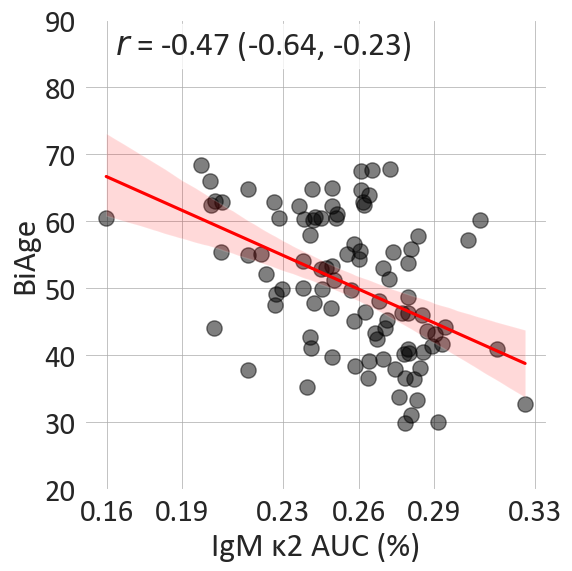

 23%|██▎       | 12/53 [00:00<00:00, 71.20it/s]

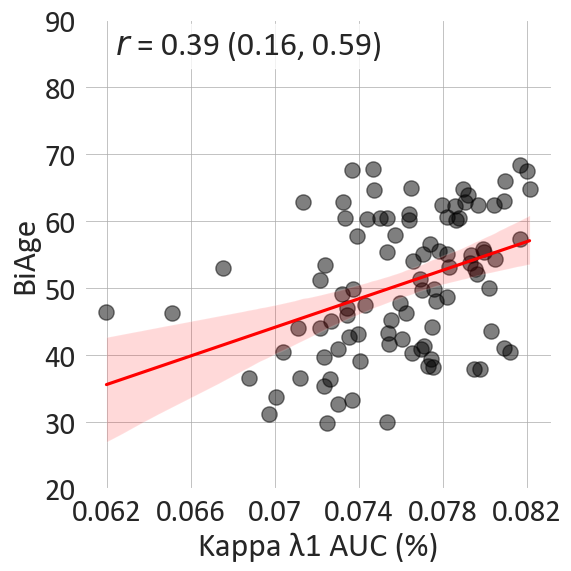

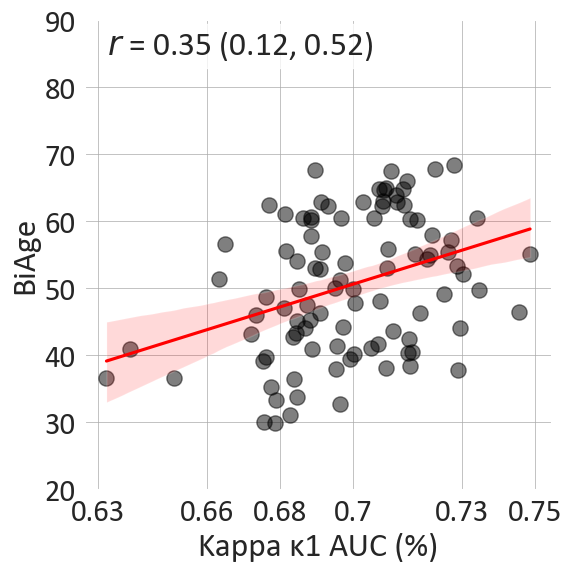

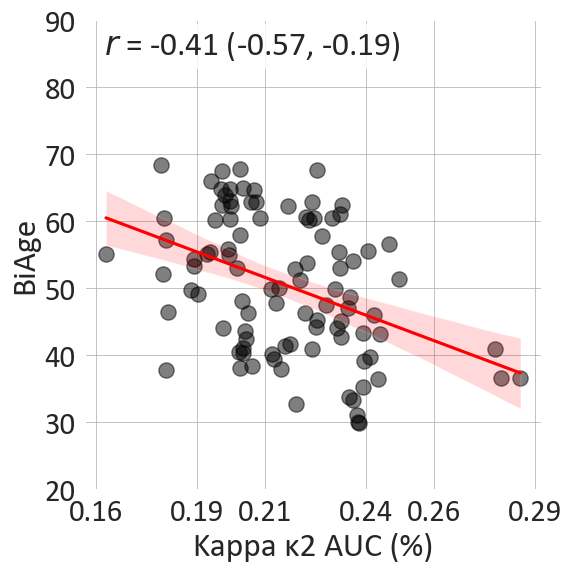

 38%|███▊      | 20/53 [00:00<00:01, 26.90it/s]

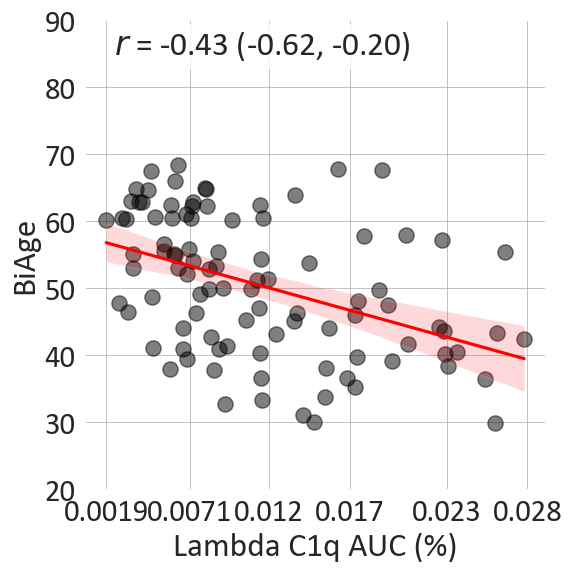

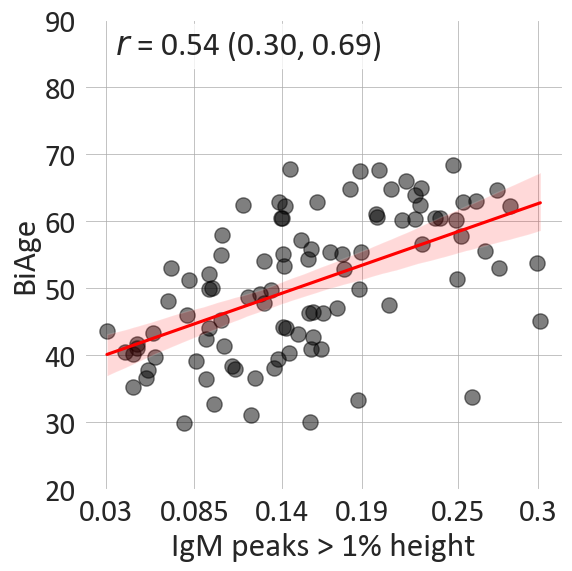

 45%|████▌     | 24/53 [00:00<00:01, 20.47it/s]

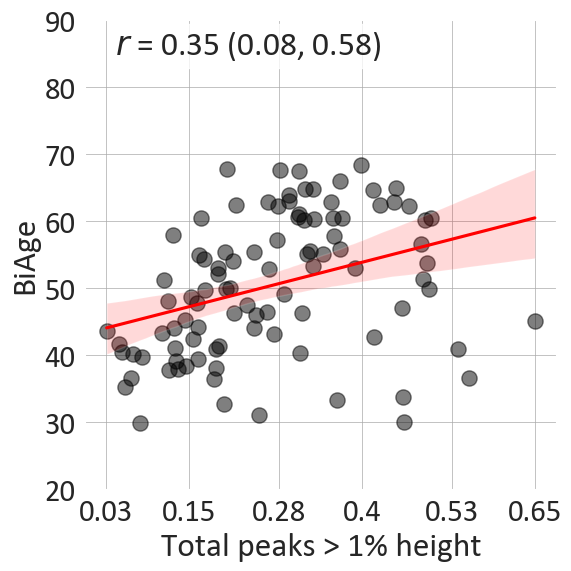

 62%|██████▏   | 33/53 [00:01<00:00, 27.97it/s]

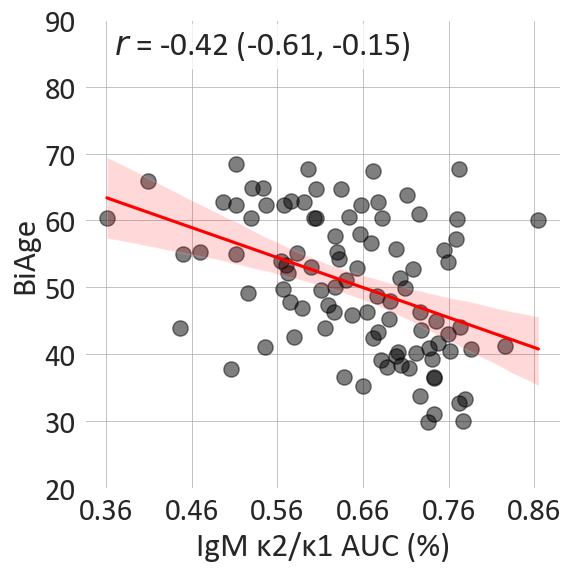

 75%|███████▌  | 40/53 [00:01<00:00, 31.19it/s]

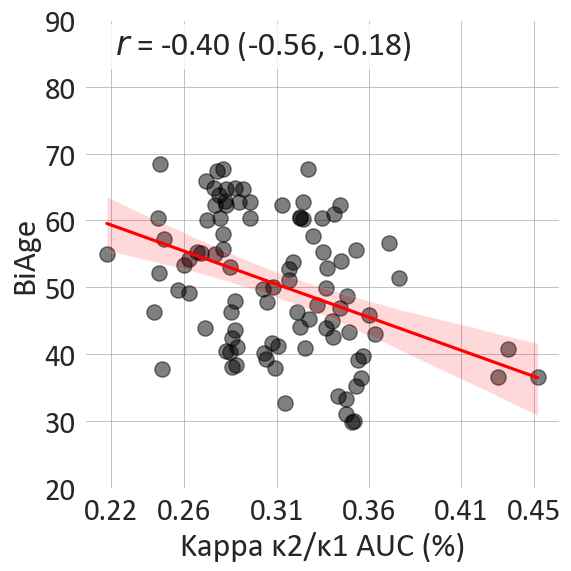

100%|██████████| 53/53 [00:01<00:00, 34.87it/s]


In [126]:
# compute the determination coef (r2) for all variables vs our target variable (age or humoral age)

# FIGURE 1 E

covariates_metric_list = []
for feature in tqdm(candidate_features):
    feature_filename = feature.replace(" >", "").replace("/", "_")
    # get the values of interest
    y = feature_exploration_df[target_score_colname]
    x = trace_features_analysis_df_enriched[feature]
    # check if some variance
    # compute pearson's r
    val_r = scipy.stats.pearsonr(x, y).statistic
    feature_metric = val_r ** 2
    if np.std(x) == 0:
        print(f"Skipping {feature=}: zero-variance")
        covariates_metric_list.append(0)  # put a dummy "zero" value to avoid "nan"'s
        continue
    # save the r2 in a list
    covariates_metric_list.append(feature_metric)
    if (feature_exploration_mode == "qualitative") or (feature_metric < 0.1):  # plot only if r² >= 0.1
        continue
    # prepare the plot
    # create a correlation plot between this feature and the target variable
    plt.figure(figsize=(pp_size, pp_size))
    if target_score_colname == "BIAGE_STD":
        yticks = ([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.])
        if UNSTANDARDIZE_PREDICTIONS:
            y = y * training_age_std + training_age_mean
    elif target_score_colname == "AGE":
        yticks = [40, 50, 65, 75]
    else:
        assert False, f"Unknown {target_score_colname=}"
    xmin, xmax = x.min(), x.max()
    xrange = xmax - xmin
    xticks = np.arange(xmin, xmax + (xrange / 5) / 2, xrange / 5)
    xticks = [float(f"{v:.2g}") for v in xticks]
    plot_lm(x=x, y=y, group_name="Negatives", xticks=xticks, yticks=yticks,
            ylabel="BiAge" if target_score_colname == "BIAGE_STD" else target_score_colname,
            xlabel=feature,
            text_bbox_alpha=.8,
            text_show_sample_size=False,
            confidence_level=.99)
    plt.tight_layout()
    plt.show()
    
covariates_metric_list = np.array(covariates_metric_list)

In [ ]:
for feature in tqdm(candidate_features):
    feature_filename = feature.replace(" >", "").replace("/", "_")
    # get the values of interest
    y = feature_exploration_df[target_score_colname]
    x = trace_features_analysis_df_enriched[feature]
    # check if some variance
    # compute pearson's r
    val_r = scipy.stats.pearsonr(x, y).statistic
    feature_metric = val_r ** 2
    if np.std(x) == 0:
        print(f"Skipping {feature=}: zero-variance")
        covariates_metric_list.append(0)  # put a dummy "zero" value to avoid "nan"'s
        continue
    # save the r2 in a list
    covariates_metric_list.append(feature_metric)
    if (feature_exploration_mode == "qualitative") or (feature_metric < 0.1):  # plot only if r² >= 0.1
        continue
    # prepare the plot
    # create a correlation plot between this feature and the target variable
    plt.figure(figsize=(pp_size, pp_size))
    if target_score_colname == "BIAGE_STD":
        yticks = ([20, 30, 40, 50, 60, 70, 80, 90] if UNSTANDARDIZE_PREDICTIONS else [-1., 0, 1.])
        if UNSTANDARDIZE_PREDICTIONS:
            y = y * training_age_std + training_age_mean
    elif target_score_colname == "AGE":
        yticks = [40, 50, 65, 75]
    else:
        assert False, f"Unknown {target_score_colname=}"
    xmin, xmax = x.min(), x.max()
    xrange = xmax - xmin
    xticks = np.arange(xmin, xmax + (xrange / 5) / 2, xrange / 5)
    xticks = [float(f"{v:.2g}") for v in xticks]
    plot_lm(x=x, y=y, group_name="Negatives", xticks=xticks, yticks=yticks,
            ylabel="BiAge" if target_score_colname == "BIAGE_STD" else target_score_colname,
            xlabel=feature,
            text_bbox_alpha=.8,
            text_show_sample_size=False,
            confidence_level=.99)
    plt.tight_layout()
    plt.show()

From there, we will select all features with a r2 at least > 0.1 and perform recursive feature elimination using a linear model to highlight the independent contribution of each feature

In [127]:
# select our subset of variables of interest
cov_keep_filter = covariates_metric_list > .01
# we'll take all covariates with r² > 0.1
features_kept_for_rfe = [cov for cov, keep in zip(candidate_features, cov_keep_filter) if keep]

print("Number of features selected:")
print(len(features_kept_for_rfe))

# RFE

MODEL_TYPE = "lm"
lm = linear_model.LinearRegression()

y = feature_exploration_df[target_score_colname].to_numpy()
X = trace_features_analysis_df_enriched[features_kept_for_rfe].to_numpy()

# run RFE => manually
features_ranking = np.array([-1, ] * X.shape[1])
with tqdm(total=X.shape[1]) as pbar:
    while True:
        # update progress
        pbar.update()
        # list variables still in competition
        not_already_excluded = np.where(features_ranking == -1)[0]
        if len(not_already_excluded) == 1:
            iter_rank = np.sum(features_ranking == -1)
            features_ranking[not_already_excluded[0]] = iter_rank
            break
        # parse them and compute r2 when removing each of them
        step_results = []
        for k in not_already_excluded:
            iter_X = X[:, [v for v in not_already_excluded if v != k]]
            # iter_metric = np.nan
            if MODEL_TYPE in ["lm", "ridge1e-6"]:
                # just train and test on the same data
                lm.fit(iter_X, y)
                iter_metric = scipy.stats.pearsonr(lm.predict(iter_X), y).statistic ** 2
            elif MODEL_TYPE in ["xgboost"]:
                # train and test on different data (or else we will always have r==1...)
                iter_X_train, iter_X_test, y_train, y_test = train_test_split(iter_X, y, train_size=.8, random_state=1)
                lm.fit(iter_X_train, y_train)
                iter_metric = scipy.stats.pearsonr(lm.predict(iter_X_test), y_test).statistic ** 2
            else:
                assert False, f"Unknown expected behaviour for {MODEL_TYPE=}"
            step_results.append(iter_metric)
        # the variable we want to keep MOST is the variable that when we remove it, we have the worst results (lowest r2)
        # we will remove the variable that when removed gives the best r2 (useless)
        remove_pos = np.argmax(step_results)
        iter_rank = np.sum(features_ranking == -1)
        features_ranking[not_already_excluded[remove_pos]] = iter_rank

Number of features selected:
39


100%|██████████| 39/39 [00:01<00:00, 38.74it/s]


We will then compute the r2 at each stage, i.e. using an increasing number of features with features ordered by their importance in predicting BiAge

In [128]:
# compute r2 at each stage
rfe_results = []
for keep_how_many_variables in range(1, len(features_ranking) + 1)[::-1]:
    iteration_X = X[:, features_ranking <= keep_how_many_variables]
    if MODEL_TYPE in ["lm", "ridge1e-6"]:
        # just train and test on the same data
        lm.fit(iteration_X, y)
        metric = scipy.stats.pearsonr(lm.predict(iteration_X), y).statistic  # ** 2
    elif MODEL_TYPE in ["xgboost"]:
        # train and test on different data (or else we will always have r==1...)
        iter_X_train, iter_X_test, y_train, y_test = train_test_split(iteration_X, y, train_size=.8, random_state=1)
        lm.fit(iter_X_train, y_train)
        metric = scipy.stats.pearsonr(lm.predict(iter_X_test), y_test).statistic  # ** 2
    else:
        assert False, f"Unknown expected behaviour for {MODEL_TYPE=}"
    rfe_results.append(
        {"feature_excluded_after": features_kept_for_rfe[np.where(features_ranking == keep_how_many_variables)[0][0]],
         "n_features": keep_how_many_variables, "r": metric})

rfe_results = pd.DataFrame(rfe_results)
print(rfe_results)

      feature_excluded_after  n_features         r
0             IgM κ1 AUC (%)          39  0.888765
1          IgM λ1+λ2 AUC (%)          38  0.888765
2             IgA κ2 AUC (%)          37  0.888765
3             IgM κ2 AUC (%)          36  0.888765
4                   FLCRATIO          35  0.888763
5            IgA κ/λ AUC (%)          34  0.888758
6             IgA λ1 AUC (%)          33  0.888718
7          N_PEAKS_BELOW_LOD          32  0.888607
8        Kappa κ2/κ1 AUC (%)          31  0.888470
9                  TOTAL_IGK          30  0.888225
10         IgG λ2/λ1 AUC (%)          29  0.887722
11         IgA λ1+λ2 AUC (%)          28  0.887165
12         IgA κ2/κ1 AUC (%)          27  0.886571
13         IgG κ2/κ1 AUC (%)          26  0.885594
14         Lambda λ1 AUC (%)          25  0.884135
15                IUFLCRatio          24  0.882519
16          Kappa κ2 AUC (%)          23  0.880366
17          Kappa κ1 AUC (%)          22  0.876855
18            IgM λ2 AUC (%)   

Then we can plot the r2 of predicting BiAge from our features, according to the number of features

This is **Figure 1D**

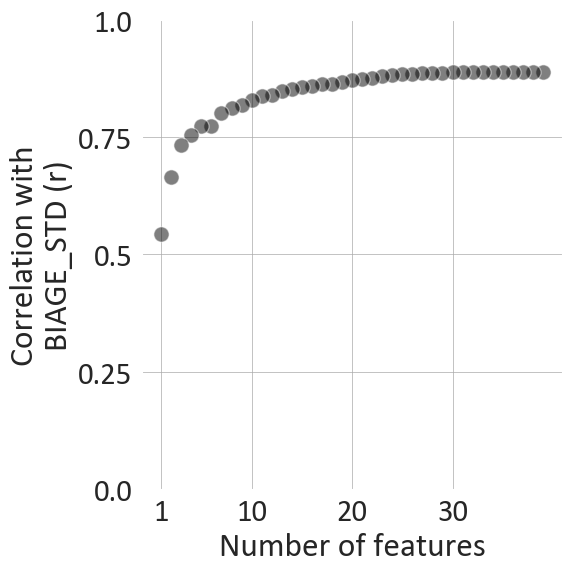

In [129]:
# FIGURE 1 D

plt.figure(figsize=(pp_size, pp_size))
plot_lm(x=rfe_results.n_features, y=rfe_results.r,
        group_name="Features", xlabel="Number of features",
        ylabel=f"Correlation with\n{'BiAge' if target_score_colname == 'Age score' else target_score_colname} (r)",
        text_pos="bottom right",
        yticks=[0., .25, .5, .75, 1.],
        xticks=[1, *np.arange(10, len(rfe_results), 10)],
        text_show=False,
        no_lm=True,
        confidence_level=.99)
plt.tight_layout()
plt.show()

In [130]:
# save results
print(rfe_results)

      feature_excluded_after  n_features         r
0             IgM κ1 AUC (%)          39  0.888765
1          IgM λ1+λ2 AUC (%)          38  0.888765
2             IgA κ2 AUC (%)          37  0.888765
3             IgM κ2 AUC (%)          36  0.888765
4                   FLCRATIO          35  0.888763
5            IgA κ/λ AUC (%)          34  0.888758
6             IgA λ1 AUC (%)          33  0.888718
7          N_PEAKS_BELOW_LOD          32  0.888607
8        Kappa κ2/κ1 AUC (%)          31  0.888470
9                  TOTAL_IGK          30  0.888225
10         IgG λ2/λ1 AUC (%)          29  0.887722
11         IgA λ1+λ2 AUC (%)          28  0.887165
12         IgA κ2/κ1 AUC (%)          27  0.886571
13         IgG κ2/κ1 AUC (%)          26  0.885594
14         Lambda λ1 AUC (%)          25  0.884135
15                IUFLCRatio          24  0.882519
16          Kappa κ2 AUC (%)          23  0.880366
17          Kappa κ1 AUC (%)          22  0.876855
18            IgM λ2 AUC (%)   

We can plot all top features with r2 > 0.1 in a single plot, which is **Supplementary Figure S6**

C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:169: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:169: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:169: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=ticks_font_params)
C:\Users\flori\AppData\Local\Temp\ipykernel_16716\3410833817.py:169: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks, fontdict=tic

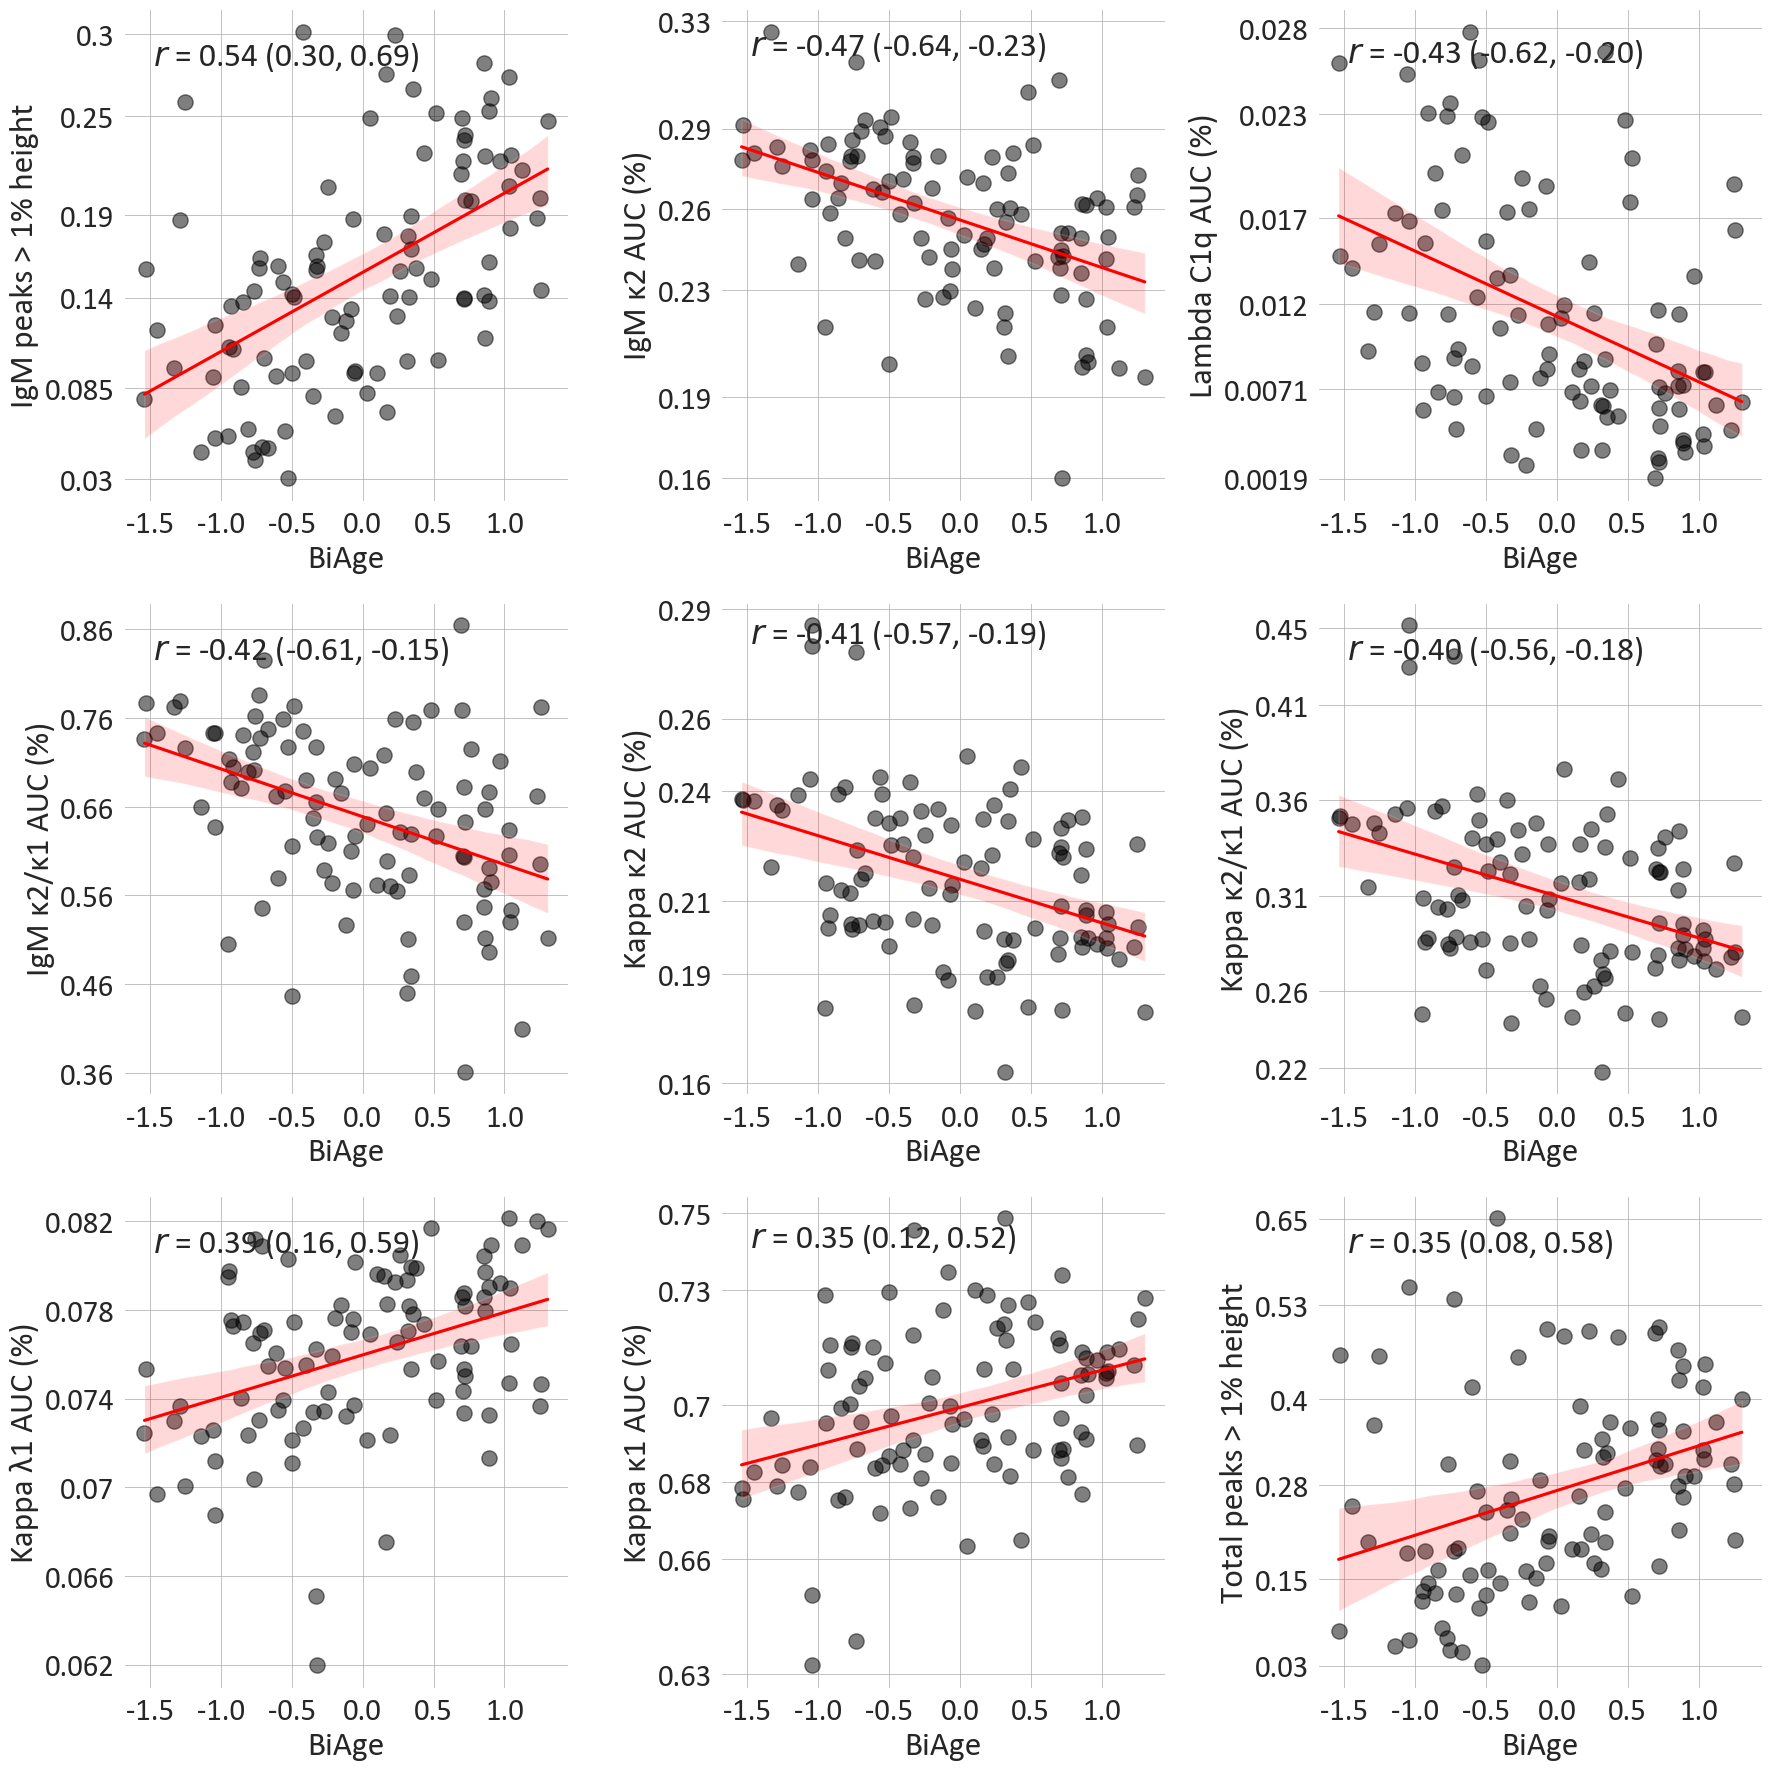

In [178]:
# FIGURE S6

order_by_r2_instead = True
if order_by_r2_instead:
    order = np.argsort(covariates_metric_list[cov_keep_filter])
    ranks = np.argsort(order)
    ranks = len(ranks) - ranks
    features_ranking_kept = ranks
else:
    features_ranking_kept = features_ranking

# np.array(covariates_r2_list)[features_ranking_kept-1]

# plot all covariates, ranked
n_col = 3
n_row = 3
max_n_features = n_col * n_row
plt.figure(figsize=(pp_size * n_col, pp_size * n_row))
for position, rank in enumerate(features_ranking_kept):
    if rank > max_n_features:
        continue
    col = features_kept_for_rfe[position]
    plt.subplot(n_row, n_col, rank)
    x = feature_exploration_df[target_score_colname]
    y = trace_features_analysis_df_enriched[col]
    r = scipy.stats.pearsonr(x, y).statistic
    xticks = [-2, -1, 0, 1, 2] if target_score_colname == "Age score" else [40, 50, 65,
                                                                            75] if target_score_colname == "Age" else None
    ymin, ymax = y.min(), y.max()
    yrange = ymax - ymin
    yticks = np.arange(ymin, ymax + (yrange / 5) / 2, yrange / 5)
    yticks = [float(f"{v:.2g}") for v in yticks]
    plot_lm(x=x, y=y, group_name="Negatives", xticks=xticks, yticks=yticks,
            text_show_sample_size=False,
            xlabel="BiAge" if target_score_colname == "BIAGE_STD" else "?",
            ylabel=col,
            confidence_level=.99)
    # plt.title(f"{position}/{rank}")
plt.tight_layout()
plt.show()

Finally, we can select and example of sample predicted with high BiAge or low BiAge and plot their spectra, overlayed with the gaussian distributions that were extracted (kappa 1, kappa 2, etc.)

First, we will need to design the function responsible of creating this plot for a sample:

In [135]:
def gaussians_pretty_plot(ms_digitized_data_buffer: list, optim_params_buffer: list, optim_params_colors: list,
                          n_isotypes: int, gaussian_names: list,
                          raw_lw: float = .5, reconstructed_lw: float = 1,
                          dalton_scale_in_k: bool = False,
                          plot_gaussians: bool = True,
                          plot_ipsa_residuals: bool = False,
                          trace_peaks_analysis: list = None,
                          show_legend: bool = True, highlight_residual_error: bool = True, show: bool = False):
    """
    Do a pretty plot of gaussian deconvolution results of an MS sample

    :param ms_digitized_data_buffer: output of previous functions used for deconvoluting gaussians
    :param optim_params_buffer: output of previous functions used for deconvoluting gaussians
    :param optim_params_colors: colors of the different gaussians
    :param n_isotypes: number of isotypes, usually 5
    :param gaussian_names: names of the gaussians
    :param raw_lw: width of the raw data line
    :param reconstructed_lw: width of the reconstructed (modelled) data line
    :param dalton_scale_in_k: boolean, whether the m/z scale should be in Dalton or kDa
    :param show_legend: bool, whether to show legend or not
    :param highlight_residual_error: bool, default False, whether to display the area of the reconstruction error
    :param plot_gaussians: bool, whether or not to plot gaussians
    :param plot_ipsa_residuals: whether or not to plot residuals after ipsa smoothing
    :param trace_peaks_analysis: automatically detected peaks data to show, default None
    :param show: bool, default to False; set to True to call plt.show() before returning, keep False so the figure can be saved after executing the routine
    :return:
    """

    LEGEND_RAW_TRACKSHOW = (0,)
    LEGEND_PEAKS_TRACKSHOW = (1,)
    LEGEND_ISO_GAUSSIANS_TRACKSHOW = [[], [], [], [1, 3], [0, 2, 4]]

    # from scipy.ndimage import gaussian_filter

    if highlight_residual_error:
        plt.figure(figsize=(pp_size * 1.6, pp_size * 2.4))
    else:
        plt.figure(figsize=(pp_size * 1.25, pp_size * 2.0))
    for isotype in range(n_isotypes):
        ms_digitized_data = ms_digitized_data_buffer[isotype]
        optim_params = optim_params_buffer[isotype]

        # create the subplot for this isotype (1 new row)
        ax = plt.subplot(5, 1, isotype + 1)

        # plot the raw trace (initially, so it appears first in the legend)
        sns.lineplot(x=ms_digitized_data.iloc[:, 0], y=ms_digitized_data.iloc[:, 1], color="#000000",
                     # label="Raw data" if ((isotype in LEGEND_RAW_TRACKSHOW) and show_legend) else None,
                     lw=raw_lw,
                     ax=ax)
        # FAKE DATA FOR THE LEGEND (so the line width will be a bit thickier)
        if (isotype in LEGEND_RAW_TRACKSHOW) and show_legend:
            sns.lineplot(x=[ms_digitized_data.iloc[0, 0]], y=[ms_digitized_data.iloc[0, 1]],
                         color="#000000", label="Raw data", ax=ax)

        if plot_gaussians:

            # plot the area under each gaussian
            for gaussian_j, param in enumerate(optim_params):
                gmx = model_trace_from_gaussians(ms_digitized_data.iloc[:, 0], [param])
                ax.fill_between(x=ms_digitized_data.iloc[:, 0], y1=gmx, color=optim_params_colors[isotype][gaussian_j], alpha=0.3)
                sns.lineplot(x=ms_digitized_data.iloc[:, 0], y=gmx, color=optim_params_colors[isotype][gaussian_j], ax=ax)
            # and the legend with it if we want it
            if show_legend:
                for gaussian_j in LEGEND_ISO_GAUSSIANS_TRACKSHOW[isotype]:
                    # FAKE INVISILBE DATA FOR LEGEND
                    sns.lineplot(x=[ms_digitized_data.iloc[0, 0]], y=[ms_digitized_data.iloc[0, 1]],
                                 color=optim_params_colors[isotype][gaussian_j], label=gaussian_names[isotype][gaussian_j] + " distribution", ax=ax)

            ggmx = model_trace_from_gaussians(ms_digitized_data.iloc[:, 0], optim_params)

            # plot the residual error
            if highlight_residual_error:
                ax.fill_between(x=ms_digitized_data.iloc[:, 0],
                                y1=np.minimum(ggmx.to_numpy(), ms_digitized_data.iloc[:, 1].to_numpy()),
                                y2=np.maximum(ggmx.to_numpy(), ms_digitized_data.iloc[:, 1].to_numpy()),
                                color="#ff0000", alpha=0.9)
                if show_legend:
                    # FAKE INVISIBLE FOR LEGEND
                    sns.lineplot(x=[ms_digitized_data.iloc[0, 0]], y=[ms_digitized_data.iloc[0, 1]],
                                 color="#ff0000", lw=3, label="Reconstruction error")

            # plot ipsa residual error
            if plot_ipsa_residuals:
                x_ipsa = ipsa_baseline(x_track=np.stack([ms_digitized_data.iloc[:, 0].values,
                                                         ms_digitized_data.iloc[:, 1].values], axis=0))

                residuals = ms_digitized_data.iloc[:, 1].values - x_ipsa[1, ...]
                residuals = np.abs(residuals)

                ircolor = "#ff0000"
                sns.lineplot(x=ms_digitized_data.iloc[:, 0], y=residuals, color=ircolor, ax=ax)
                if show_legend:
                    # FAKE INVISILBE DATA FOR LEGEND
                    sns.lineplot(x=[ms_digitized_data.iloc[0, 0]], y=[ms_digitized_data.iloc[0, 1]], color=ircolor, label="Residuals (IPSA)", ax=ax)

            # show automatically detected peaks
            if trace_peaks_analysis is not None:
                # trace_peaks_analysis["peaks_data"][isotype]
                # sns.lineplot(x=ms_digitized_data.iloc[:, 0],
                #              y=np.maximum(trace_peaks_analysis["residuals"][isotype], 0),
                #              color="#ff0000", ax=ax)
                for peak_center_pos in trace_peaks_analysis["peaks_data"][isotype][0]:
                    pos_start = peak_center_pos - 10
                    pos_end = peak_center_pos + 10
                    ax.fill_between(x=ms_digitized_data.iloc[pos_start:pos_end, 0],
                                    y1=trace_peaks_analysis["x_ipsa"][isotype][pos_start:pos_end],
                                    y2=ms_digitized_data.iloc[pos_start:pos_end, 1],
                                    color="#ff0000", alpha=0.3)
                if (isotype in LEGEND_PEAKS_TRACKSHOW) and show_legend:
                    # FAKE INVISILBE DATA FOR LEGEND
                    sns.lineplot(x=[ms_digitized_data.iloc[0, 0]], y=[ms_digitized_data.iloc[0, 1]], color="#ff0000", label="Low s/n peaks",
                                 lw=3, alpha=.3, ax=ax)

            # plot the GMM baseline
            sns.lineplot(x=ms_digitized_data.iloc[:, 0], y=ggmx, color="#aaaaaa", label="Modelled" if ((isotype in LEGEND_RAW_TRACKSHOW) and show_legend) else None, lw=reconstructed_lw, ax=ax)

            # plot the raw trace (again, so it appears OVER the other distributions)
            sns.lineplot(x=ms_digitized_data.iloc[:, 0], y=ms_digitized_data.iloc[:, 1], color="#000000", lw=raw_lw, ax=ax)

        if isotype == (n_isotypes - 1):  # last (bottom most) track: show x axis
            plt.xticks([10900, 11700, 12500])
            xticks = ax.get_xticks()
            if dalton_scale_in_k:
                xticks = [f"{v / 1000:.1f}k" for v in xticks]
            ax.set_xticklabels(xticks, fontdict=ticks_font_params)
            plt.xlabel("m/z", **labels_font_params)
        else:  # other tracks: do not show legend
            plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            ax.set(xlabel=None)

        plt.yticks([0, .5, 1.])
        yticks = ax.get_yticks()
        yticks = (yticks * 100).astype(int)
        ax.set_yticklabels(yticks, fontdict=ticks_font_params)
        if isotype < 3:
            iso_name = f"Ig{'GAM'[isotype]}"
        elif isotype == 3:
            iso_name = "κ"
        elif isotype == 4:
            iso_name = "λ"
        else:
            iso_name = None
        plt.ylabel(f"{iso_name} relative\nabundance (%)", **labels_font_params)

    plt.tight_layout()
    if show:
        plt.show()
        

def features_plot(match_id: str, figure_path: str):
    """
    plot an example of trace with features decomposed

    :param match_id:
    :param figure_path:
    :return:
    """
    ms_digitized_data_buffer, optim_params_buffer, rmse = deconvolute_gaussians_v2(dataset_path=ms_data_path,
                                                                                   match_id=match_id,
                                                                                   p_keys=P_KEYS,
                                                                                   gaussians=DEFAULT_GAUSSIANS,
                                                                                   n_isotypes=len(DEFAULT_ISOTYPES),
                                                                                   harcoded_params=DEFAULT_HARDCODED_PARAMS,
                                                                                   init_global_params=DEFAULT_INIT_GLOBAL_PARAMS,
                                                                                   global_params_bounds=DEFAULT_GLOBAL_PARAMS_BOUNDS,
                                                                                   return_rmse=True)

    trace_peaks_analysis = peak_detection_v3(dataset_path=ms_data_path, match_id=match_id,
                                             peak_height_threshold=.01)

    gaussians_pretty_plot(ms_digitized_data_buffer=ms_digitized_data_buffer,
                          optim_params_buffer=optim_params_buffer,
                          optim_params_colors=DEFAULT_PARAM_COLORS,
                          gaussian_names=DEFAULT_GAUSSIAN_NAMES,
                          highlight_residual_error=False,
                          plot_ipsa_residuals=False,
                          trace_peaks_analysis=trace_peaks_analysis,
                          n_isotypes=len(DEFAULT_ISOTYPES),
                          show=False)

    plt.show()

Then, we can loop through all samples which we used for feature exploration, and plot the spectra for the sample with highest BiAge and lowest BiAge

This is **Figure 1C**

Lowest BiAge first:

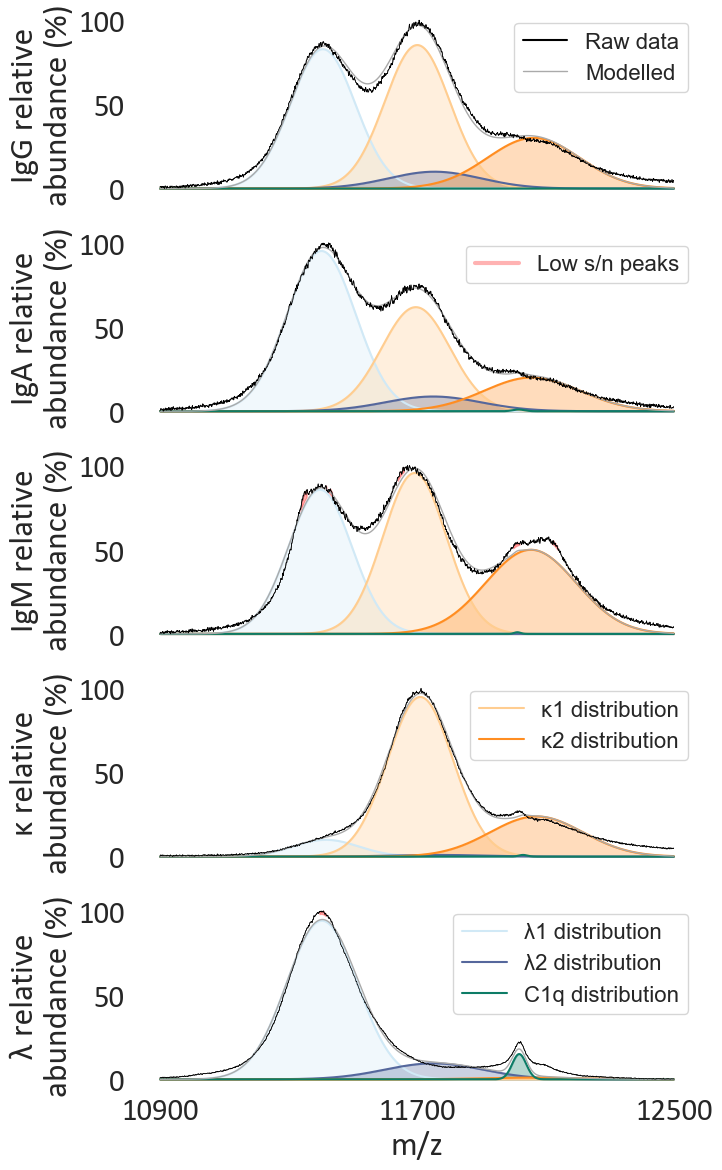

In [136]:
features_plot(match_id=feature_exploration_df.sort_values("BIAGE").iloc[0]["MS_ID"], figure_path=None)

Then highest BiAge:

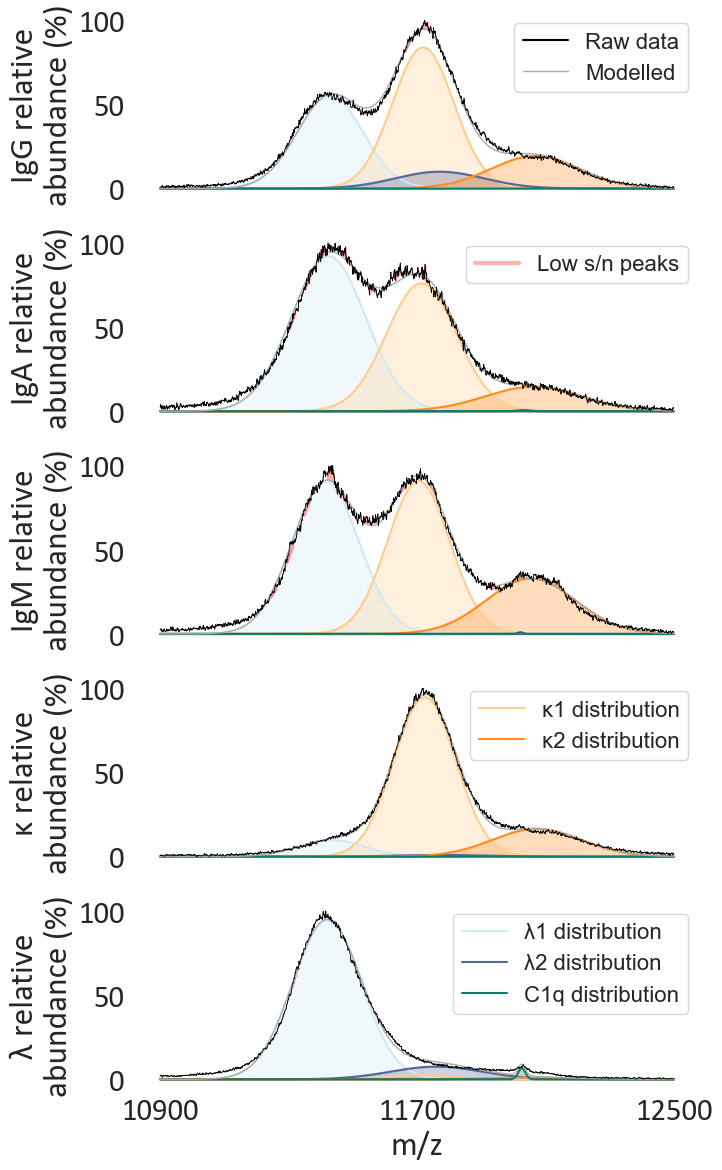

In [137]:
features_plot(match_id=feature_exploration_df.sort_values("BIAGE", ascending=False).iloc[0]["MS_ID"], figure_path=None)

# Chronological age prediction from extracted features

Now that we have extracted the best features to predict BiAge, we can use them to try to predict chronological age in negative samples, using a simpler model (e.g., linear regression) and compare the results to the deep learning model predicting BiAge.

In [ ]:
# decompose the raw ms data of each selected sample to extract gaussians, noise, etc.

all_tn_trace_features_analysis_results = []
for match_id in tqdm(dataset_test_negative.MS_ID):
    trace_features = decompose_trace_features(match_id=match_id, rmse_threshold=10.)
    all_tn_trace_features_analysis_results.append(trace_features)
all_tn_trace_features_analysis_results = pd.DataFrame(all_tn_trace_features_analysis_results)

all_tn_trace_features_analysis_results.index = dataset_test_negative.index

all_tn_trace_features_analysis_results_BACKUP = all_tn_trace_features_analysis_results.copy()

# we'll sum lambda1 + lambda2 and same for kappa, for all features
for iso in "GAM":
    for param in ["weight", "weight (%)", "AUC", "AUC (%)"]:
        all_tn_trace_features_analysis_results[f"Ig{iso} κ1+κ2 {param}"] = (all_tn_trace_features_analysis_results[f"Ig{iso} κ1 {param}"] +
                                                                all_tn_trace_features_analysis_results[f"Ig{iso} κ2 {param}"])
        all_tn_trace_features_analysis_results[f"Ig{iso} λ1+λ2 {param}"] = (all_tn_trace_features_analysis_results[f"Ig{iso} λ1 {param}"] +
                                                                all_tn_trace_features_analysis_results[f"Ig{iso} λ2 {param}"])

# also aggregate peaks
for h_thresh in (1, 3):
    for v_type in ("count", "height"):
        all_tn_trace_features_analysis_results[f"Total peaks > {h_thresh}% {v_type}"] = all_tn_trace_features_analysis_results[
            [f"Ig{iso} peaks > {h_thresh}% {v_type}" for iso in "GAM"]].sum(axis=1)

# we'll also sum total residuals
for res_method in ["IPSA", "GF"]:
    all_tn_trace_features_analysis_results[f"Total residuals ({res_method})"] = all_tn_trace_features_analysis_results[
        [f"{k} residuals ({res_method})" for k in ["IgG", "IgA", "IgM", "Kappa", "Lambda"]]].max(axis=1)
    all_tn_trace_features_analysis_results[f"Total max noise ({res_method})"] = all_tn_trace_features_analysis_results[
        [f"{k} max noise ({res_method})" for k in ["IgG", "IgA", "IgM", "Kappa", "Lambda"]]].max(axis=1)
    all_tn_trace_features_analysis_results[f"Total noise ({res_method})"] = all_tn_trace_features_analysis_results[
        [f"{k} noise ({res_method})" for k in ["IgG", "IgA", "IgM", "Kappa", "Lambda"]]].max(axis=1)

# we can also add data about ratios, if "enriched_features"
if add_ratio_features:
    for iso in "GAM":
        for param in ["weight", "weight (%)", "AUC", "AUC (%)"]:
            # kappa/lambda 2/1 ratio
            all_tn_trace_features_analysis_results[f"Ig{iso} κ2/κ1 {param}"] = (all_tn_trace_features_analysis_results[f"Ig{iso} κ2 {param}"] /
                                                                    all_tn_trace_features_analysis_results[f"Ig{iso} κ1 {param}"])
            all_tn_trace_features_analysis_results[f"Ig{iso} λ2/λ1 {param}"] = (all_tn_trace_features_analysis_results[f"Ig{iso} λ2 {param}"] /
                                                                    all_tn_trace_features_analysis_results[f"Ig{iso} λ1 {param}"])
            # total kappa/lambda ratio
            all_tn_trace_features_analysis_results[f"Ig{iso} κ/λ {param}"] = (all_tn_trace_features_analysis_results[f"Ig{iso} κ1+κ2 {param}"] /
                                                                  all_tn_trace_features_analysis_results[f"Ig{iso} λ1+λ2 {param}"])
            # all_tn_trace_features_analysis_results[f"Ig{iso} log(κ/λ) {param}"] = np.log10(all_tn_trace_features_analysis_results[f"Ig{iso} κ/λ {param}"])
    for param in ["weight", "weight (%)", "AUC", "AUC (%)"]:
        # kappa/lambda 2/1 ratio
        all_tn_trace_features_analysis_results[f"Kappa κ2/κ1 {param}"] = (all_tn_trace_features_analysis_results[f"Kappa κ2 {param}"] /
                                                              all_tn_trace_features_analysis_results[f"Kappa κ1 {param}"])
        all_tn_trace_features_analysis_results[f"Lambda λ2/λ1 {param}"] = (all_tn_trace_features_analysis_results[f"Lambda λ2 {param}"] /
                                                               all_tn_trace_features_analysis_results[f"Lambda λ1 {param}"])

# finally we'll also add some metadata, e.g. total IgG, A, kappa, etc. from Optilite, etc.
enrich_meta_columns = [*[f"TOTAL_IG{iso}" for iso in "GAMKL"],
                       "TOTAL_IGG_IGA_IGM", "FLCRATIO", "N_PEAKS_BELOW_LOD"]
all_tn_trace_features_analysis_results_enriched = all_tn_trace_features_analysis_results.merge(
    dataset_all[["MS_ID", *enrich_meta_columns]],
    on="MS_ID",
    how="left")
# also add involved/uninvolved flc ratio, relevant for MG
all_tn_trace_features_analysis_results_enriched["IUFLCRatio"] = np.maximum(all_tn_trace_features_analysis_results_enriched["FLCRATIO"], 1 / all_tn_trace_features_analysis_results_enriched["FLCRATIO"])

candidate_features = all_tn_trace_features_analysis_results_enriched.columns.tolist()[2:]  # we do not take the first: match id!

# before saving, check the order was preserved
assert (dataset_test_negative.MS_ID.values == all_tn_trace_features_analysis_results_enriched.MS_ID.values).all()

In [251]:
kept_features = [features_kept_for_rfe[pos] for pos, rank in enumerate(features_ranking_kept) if rank <= 7]

X = all_tn_trace_features_analysis_results_enriched.loc[:, kept_features].values
y = dataset_test_negative.AGE.values
y_biage = dataset_test_negative.BIAGE.values

In [255]:
import xgboost as xgb
from tqdm import trange

xgb_model = xgb.XGBRegressor(random_state=42)

r_test_biage_list = []
r_test_simpler_list = []
for bootstrap_iter in trange(1000):
    train_idx = np.random.RandomState(seed=bootstrap_iter).choice(len(X), size=len(X), replace=True)
    test_idx = np.setdiff1d(np.arange(len(X)), train_idx)
    # X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, random_state=bootstrap_iter)
    X_train, X_test, y_train, y_test, y_biage_train, y_biage_test = X[train_idx], X[test_idx], y[train_idx], y[test_idx], y_biage[train_idx], y_biage[test_idx]
    xgb_model.fit(X_train, y_train)
    # r_training = scipy.stats.pearsonr(xgb_model.predict(X_train), y_train).statistic
    # performance (r) of the correlation between BiAge and chronological age
    r_test_biage = scipy.stats.pearsonr(y_biage_test, y_test).statistic
    # performance (r) of the correlation between chronological age predicted by the simpler model and chronological age
    r_test_simpler = scipy.stats.pearsonr(xgb_model.predict(X_test), y_test).statistic
    r_test_biage_list.append(r_test_biage)
    r_test_simpler_list.append(r_test_simpler)
r_training_list = np.array(r_training_list)
r_test_list = np.array(r_test_list)

print("XGBoost model")
print("-------------")
print(f"BiAge model:   r={np.mean(r_test_biage_list):.3f} (95%CI: {np.quantile(r_test_biage_list, .025):.3f}-{np.quantile(r_test_biage_list, .975):.3f})")
print(f"Simpler model: r={np.mean(r_test_simpler_list):.3f} (95%CI: {np.quantile(r_test_simpler_list, .025):.3f}-{np.quantile(r_test_simpler_list, .975):.3f})")

100%|██████████| 1000/1000 [01:31<00:00, 10.98it/s]

XGBoost model
-------------
BiAge model:   r=0.546 (95%CI: 0.485-0.606)
Simpler model: r=0.183 (95%CI: 0.090-0.262)


In [253]:
from sklearn import linear_model
from tqdm import trange

lm_model = linear_model.Ridge(alpha=0.5)

r_test_biage_list = []
r_test_simpler_list = []
for bootstrap_iter in trange(1000):
    train_idx = np.random.RandomState(seed=bootstrap_iter).choice(len(X), size=len(X), replace=True)
    test_idx = np.setdiff1d(np.arange(len(X)), train_idx)
    # X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, random_state=bootstrap_iter)
    X_train, X_test, y_train, y_test, y_biage_train, y_biage_test = X[train_idx], X[test_idx], y[train_idx], y[test_idx], y_biage[train_idx], y_biage[test_idx]
    lm_model.fit(X_train, y_train)
    # r_training = scipy.stats.pearsonr(lm_model.predict(X_train), y_train).statistic
    # performance (r) of the correlation between BiAge and chronological age
    r_test_biage = scipy.stats.pearsonr(y_biage_test, y_test).statistic
    # performance (r) of the correlation between chronological age predicted by the simpler model and chronological age
    r_test_simpler = scipy.stats.pearsonr(lm_model.predict(X_test), y_test).statistic
    r_test_biage_list.append(r_test_biage)
    r_test_simpler_list.append(r_test_simpler)
r_training_list = np.array(r_training_list)
r_test_list = np.array(r_test_list)

print("LM model")
print("--------")
print(f"BiAge model:   r={np.mean(r_test_biage_list):.3f} (95%CI: {np.quantile(r_test_biage_list, .025):.3f}-{np.quantile(r_test_biage_list, .975):.3f})")
print(f"Simpler model: r={np.mean(r_test_simpler_list):.3f} (95%CI: {np.quantile(r_test_simpler_list, .025):.3f}-{np.quantile(r_test_simpler_list, .975):.3f})")

100%|██████████| 1000/1000 [00:01<00:00, 663.98it/s]

LM model
--------
BiAge model:   r=0.546 (95%CI: 0.485-0.606)
Simpler model: r=0.285 (95%CI: 0.200-0.366)
